In [1]:
#Here, we define 
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import *
import sympy
from sklearn.linear_model import LinearRegression
from sympy import re, im, I, E, symbols, exp
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import time

import tensorflow as tf

import glob
from tensorflow.keras.layers import Dense,Flatten,Cropping1D, Concatenate, MaxPooling1D, Dropout, Reshape, Conv1D, BatchNormalization, Activation, AveragePooling1D, GlobalAveragePooling1D, Lambda, Input, Concatenate, Add, UpSampling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras import losses
from tensorflow.keras.losses import Hinge
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard, ReduceLROnPlateau,LearningRateScheduler
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import Sequential
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import KFold, train_test_split

from scipy.special import legendre
from scipy.special import chebyt, chebyu



import numpy as np
from scipy.special import pro_ang1
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
# Definimos el valor de K

def Archit(K):

# We create an arrange with K values
    Array = np.arange(1, K[0] + 1)

# e create an arrange of the form (j, K * j)
    Lay_x_Neu = np.column_stack((Array, K[1] * Array))

    return Lay_x_Neu

In [3]:
#Number of samples and parameters

max_order_slep = 35 # increase to 20 or more eventually

Nsamples = [1000]
Ntest= 1000

#Para_slep = np.linspace(1, max_order_slep+1, 10).astype(int)
Para_slep= np.linspace(5, 25, 10).astype(int)
total_runs = 20

In [4]:
Nsamples

[1000]

In [5]:
# Define the samples 
def samps(t):
       
    Values = np.random.uniform(-1, 1, int(t[0]) if isinstance(t, (list, np.ndarray)) else int(t))

    
    #Ordenar os valores de mayor a menor
    #OValues = np.sort(Values)  # [::-1] invierte el orden
    
    return Values

In [6]:
#This is the function that we approximate
def funct(x):
    # t is the variable
    g = np.exp(-0.5*x**2)

    
    return g 

In [7]:
#WE DO IT FOR CHEBY

In [8]:
#Compute the cheby with j and c at the value x.

def Cheby(x, j):
    
    norm = np.sqrt(np.pi) if j == 0 else np.sqrt(np.pi / 2)
    return chebyt(j)(x) / norm



In [9]:
#We know create the matrix for the ls approximation

def Matrix(samp, ordens):

    A= np.zeros((len(samp), ordens))
    #We create the matrix for the least square
    for j in range(ordens):
        for k in range(len(samp)):
            A[k,j]= Cheby(samp[k], j)
    
    return A

Error: 0.0003195311574073016, Progress: 0.50%, approx. 1379.8 seconds remaining.
Error: 9.882735701011503e-06, Progress: 1.00%, approx. 686.5 seconds remaining.
Error: 2.516894649353323e-07, Progress: 1.50%, approx. 455.4 seconds remaining.
Error: 5.2618056177621075e-09, Progress: 2.00%, approx. 339.8 seconds remaining.
Error: 9.17942493184336e-11, Progress: 2.50%, approx. 270.5 seconds remaining.
Error: 1.4246030212799254e-12, Progress: 3.00%, approx. 224.2 seconds remaining.
Error: 2.0728535522986683e-14, Progress: 3.50%, approx. 191.2 seconds remaining.
Error: 1.2219566719467963e-15, Progress: 4.00%, approx. 166.5 seconds remaining.
Error: 1.6446147041085241e-15, Progress: 4.50%, approx. 147.2 seconds remaining.
Error: 1.3250408311013675e-15, Progress: 5.00%, approx. 131.8 seconds remaining.


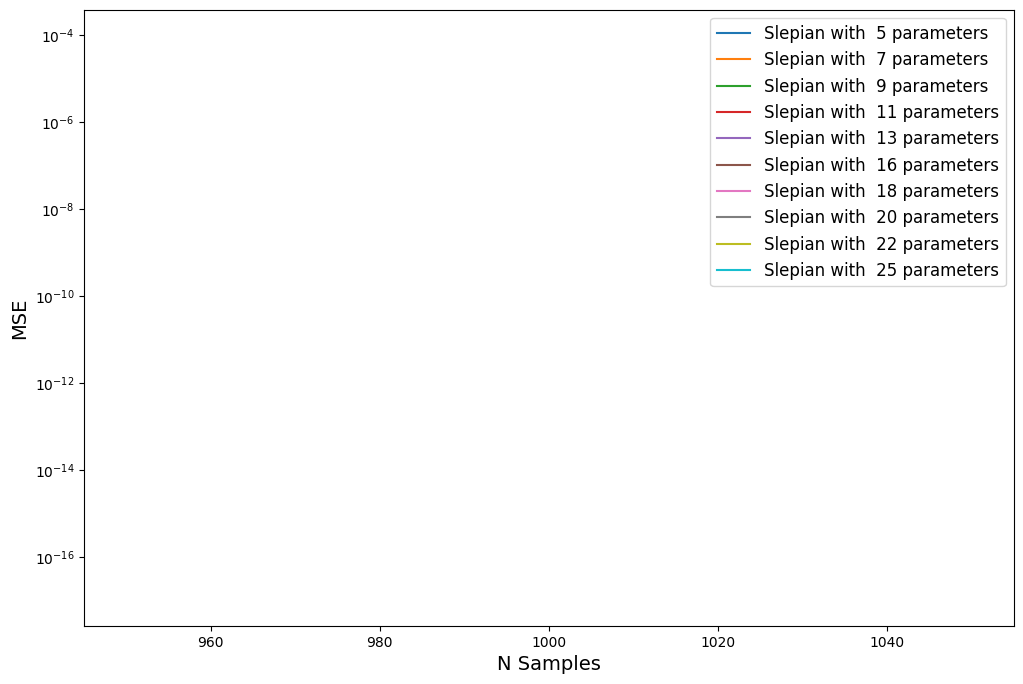

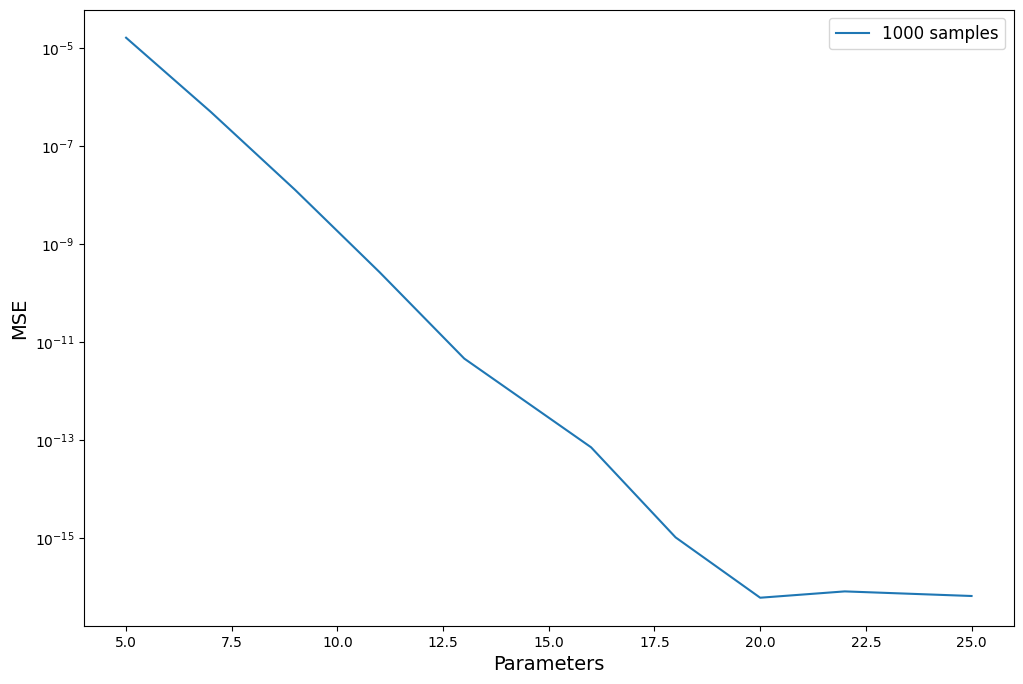

Error: 0.00031733705329056104, Progress: 5.50%, approx. 251.1 seconds remaining.
Error: 9.876765841022404e-06, Progress: 6.00%, approx. 228.9 seconds remaining.
Error: 2.5196231877533333e-07, Progress: 6.50%, approx. 210.2 seconds remaining.
Error: 5.2757347859993984e-09, Progress: 7.00%, approx. 194.2 seconds remaining.
Error: 9.352627918320386e-11, Progress: 7.50%, approx. 180.2 seconds remaining.
Error: 1.4413234082833694e-12, Progress: 8.00%, approx. 168.1 seconds remaining.
Error: 1.9906870962779995e-14, Progress: 8.50%, approx. 157.3 seconds remaining.
Error: 2.5350673162556785e-15, Progress: 9.00%, approx. 147.8 seconds remaining.
Error: 2.2207763160383733e-15, Progress: 9.50%, approx. 139.2 seconds remaining.
Error: 2.0146495022406618e-15, Progress: 10.00%, approx. 131.5 seconds remaining.


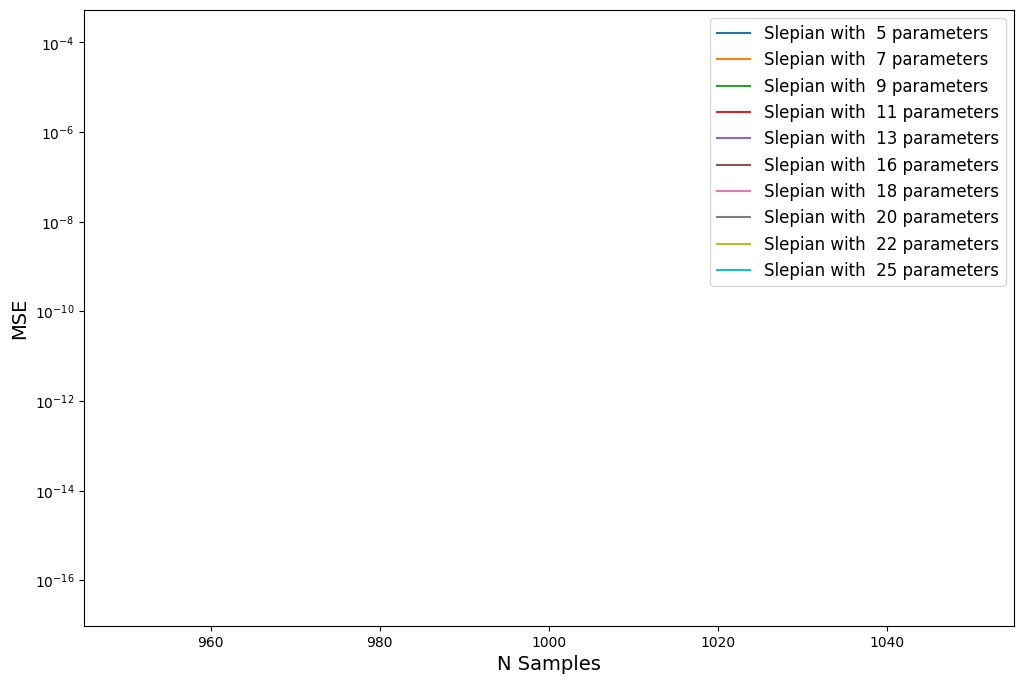

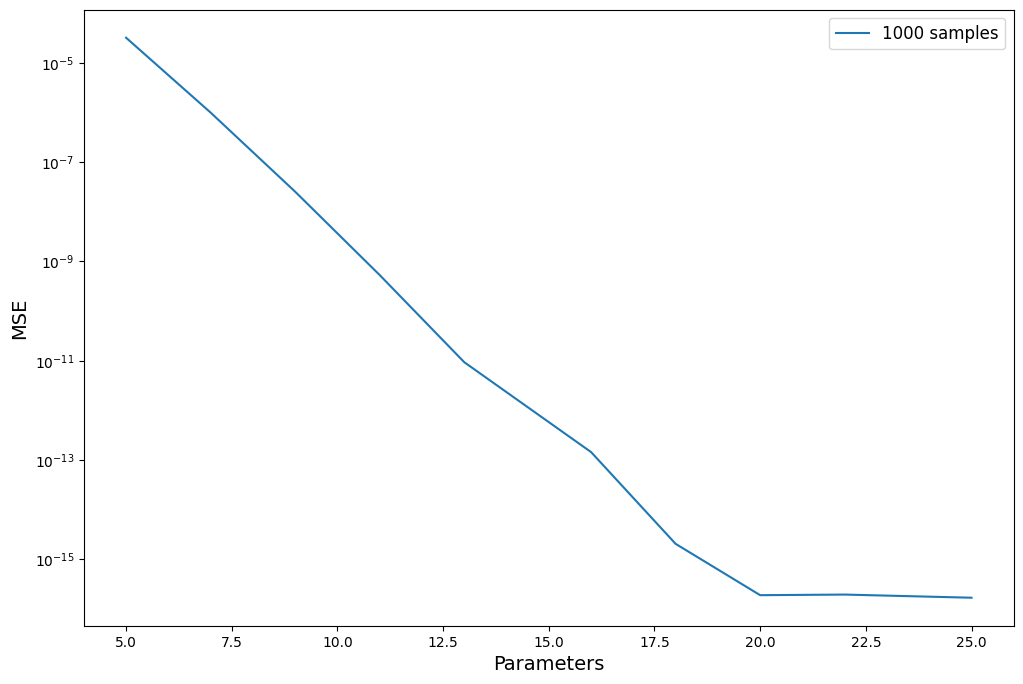

Error: 0.0003284077596097301, Progress: 10.50%, approx. 187.0 seconds remaining.
Error: 1.0396872664607455e-05, Progress: 11.00%, approx. 177.5 seconds remaining.
Error: 2.683271170700607e-07, Progress: 11.50%, approx. 168.9 seconds remaining.
Error: 5.615180081899671e-09, Progress: 12.00%, approx. 160.9 seconds remaining.
Error: 1.0077279707521194e-10, Progress: 12.50%, approx. 153.6 seconds remaining.
Error: 1.5304451328315799e-12, Progress: 13.00%, approx. 146.9 seconds remaining.
Error: 2.0781924029825122e-14, Progress: 13.50%, approx. 140.6 seconds remaining.
Error: 2.5425319268896725e-15, Progress: 14.00%, approx. 134.8 seconds remaining.
Error: 3.3672462182840417e-15, Progress: 14.50%, approx. 129.4 seconds remaining.
Error: 2.9417034590522272e-15, Progress: 15.00%, approx. 124.4 seconds remaining.


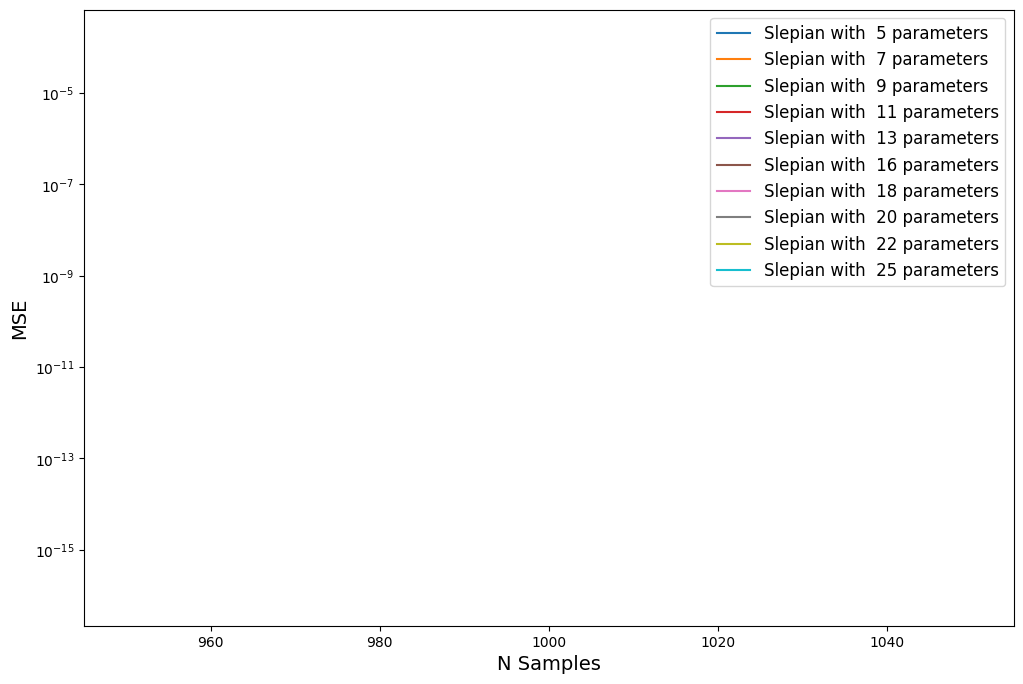

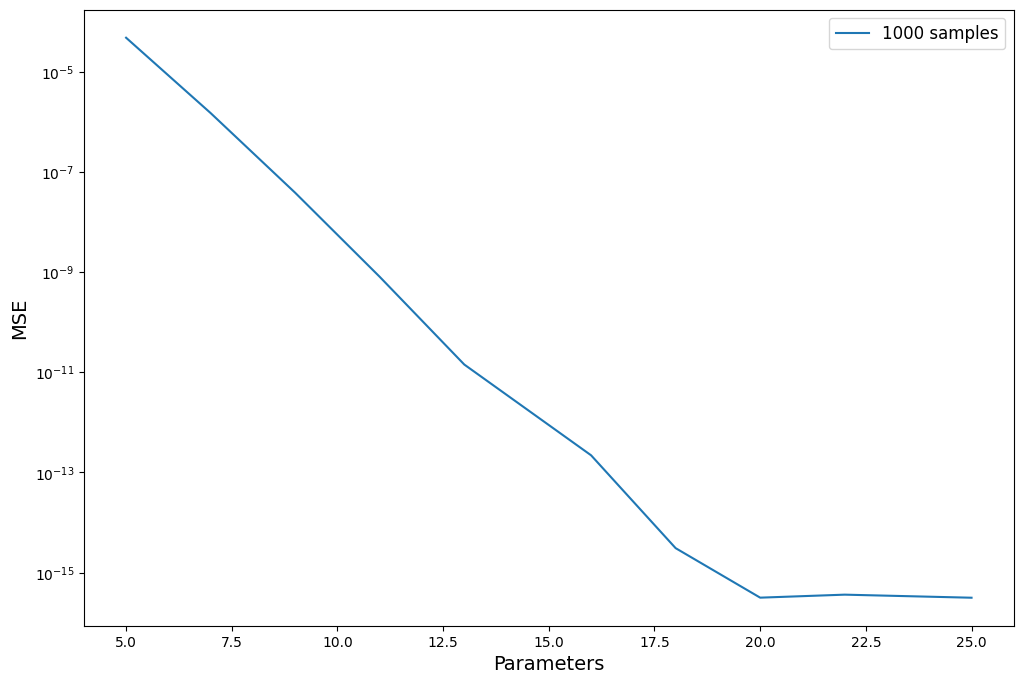

Error: 0.00032391260055858093, Progress: 15.50%, approx. 159.3 seconds remaining.
Error: 1.0141555231359762e-05, Progress: 16.00%, approx. 153.4 seconds remaining.
Error: 2.508838800841227e-07, Progress: 16.50%, approx. 147.9 seconds remaining.
Error: 5.26112100611521e-09, Progress: 17.00%, approx. 142.7 seconds remaining.
Error: 9.483342488491882e-11, Progress: 17.50%, approx. 137.7 seconds remaining.
Error: 1.4654151912219917e-12, Progress: 18.00%, approx. 133.1 seconds remaining.
Error: 2.0148584266334538e-14, Progress: 18.50%, approx. 128.7 seconds remaining.
Error: 1.4818420831657154e-15, Progress: 19.00%, approx. 124.6 seconds remaining.
Error: 2.7181334351297775e-15, Progress: 19.50%, approx. 120.6 seconds remaining.
Error: 1.775201137614149e-15, Progress: 20.00%, approx. 116.9 seconds remaining.


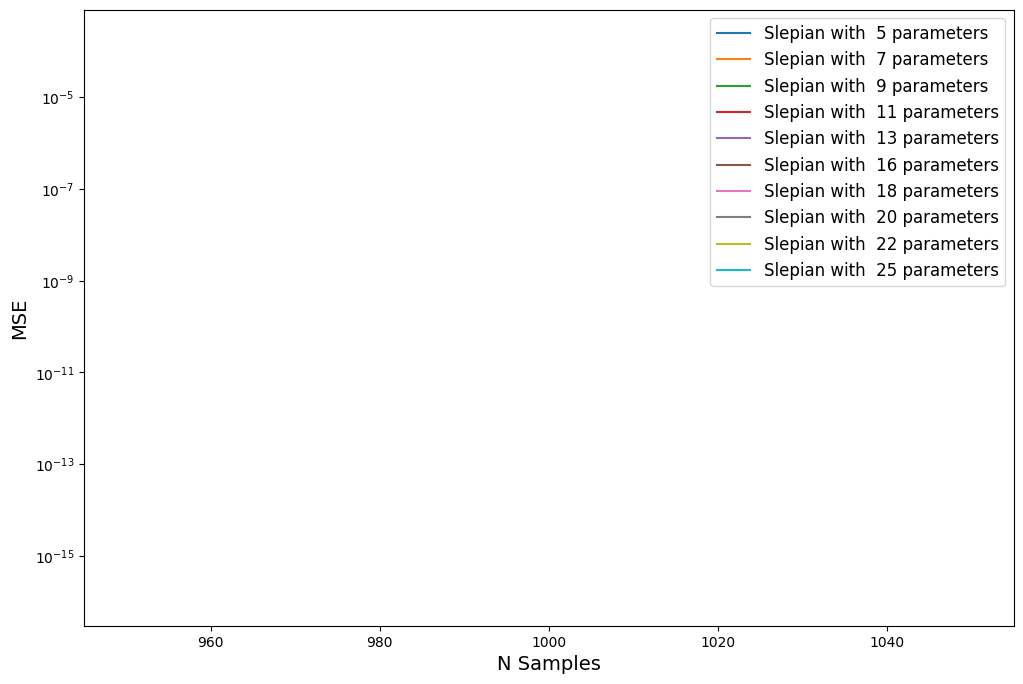

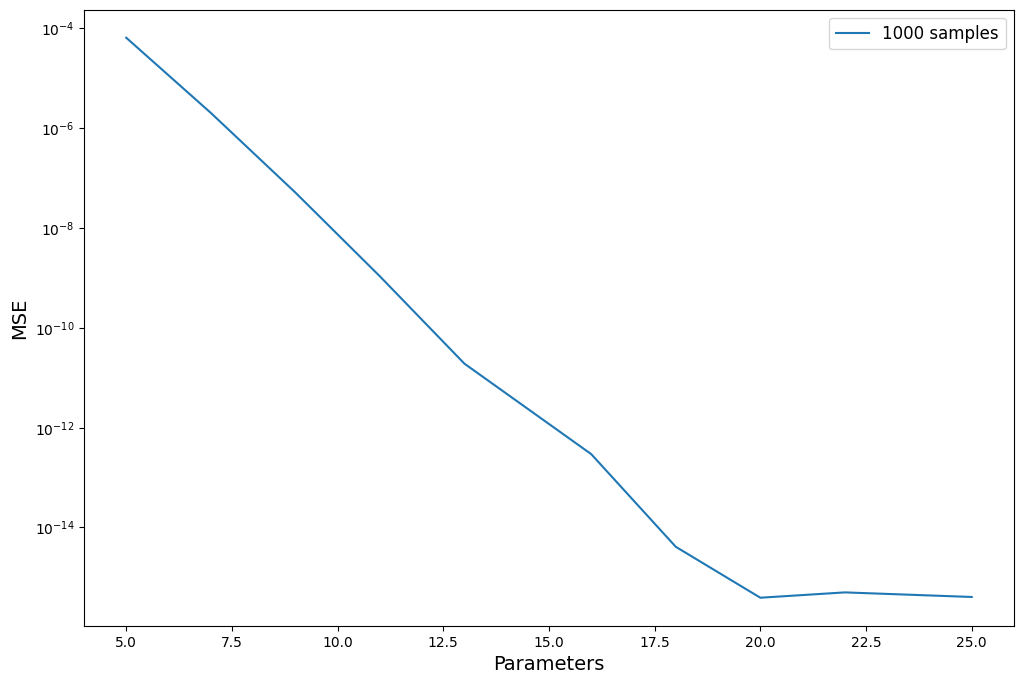

Error: 0.0003159049028987533, Progress: 20.50%, approx. 141.2 seconds remaining.
Error: 1.0192666984405301e-05, Progress: 21.00%, approx. 137.0 seconds remaining.
Error: 2.564167375309463e-07, Progress: 21.50%, approx. 133.0 seconds remaining.
Error: 5.487086603097883e-09, Progress: 22.00%, approx. 129.1 seconds remaining.
Error: 9.864071582158742e-11, Progress: 22.50%, approx. 125.5 seconds remaining.
Error: 1.6639106899700854e-12, Progress: 23.00%, approx. 121.9 seconds remaining.
Error: 2.6136188891382074e-14, Progress: 23.50%, approx. 118.6 seconds remaining.
Error: 1.370349857874014e-15, Progress: 24.00%, approx. 115.3 seconds remaining.
Error: 3.0654341374574345e-15, Progress: 24.50%, approx. 112.2 seconds remaining.
Error: 4.2923209345014905e-15, Progress: 25.00%, approx. 109.3 seconds remaining.


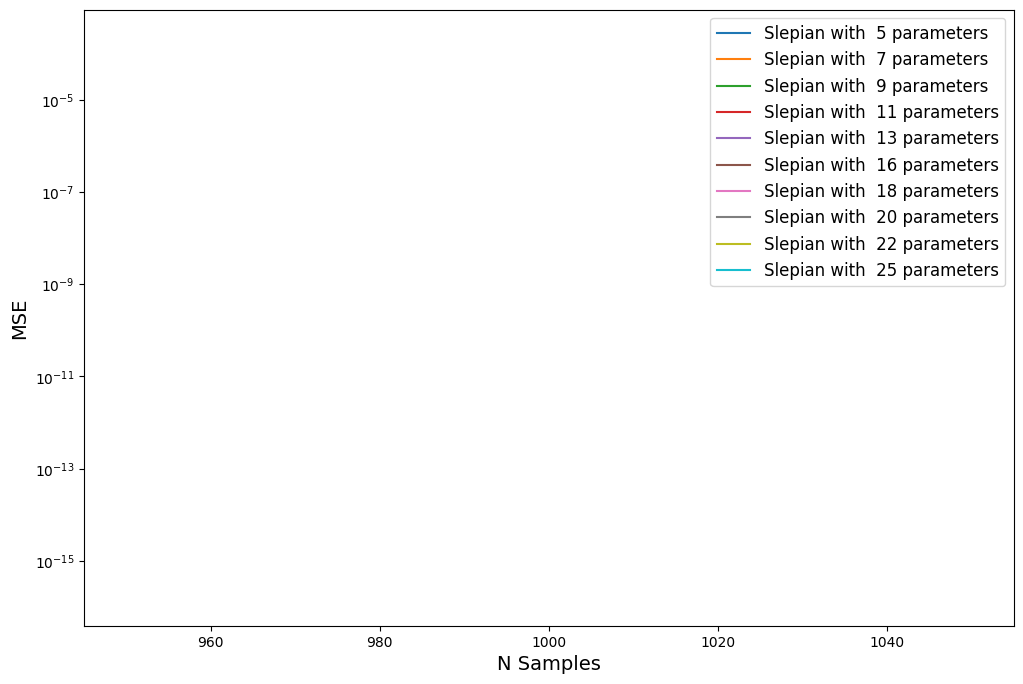

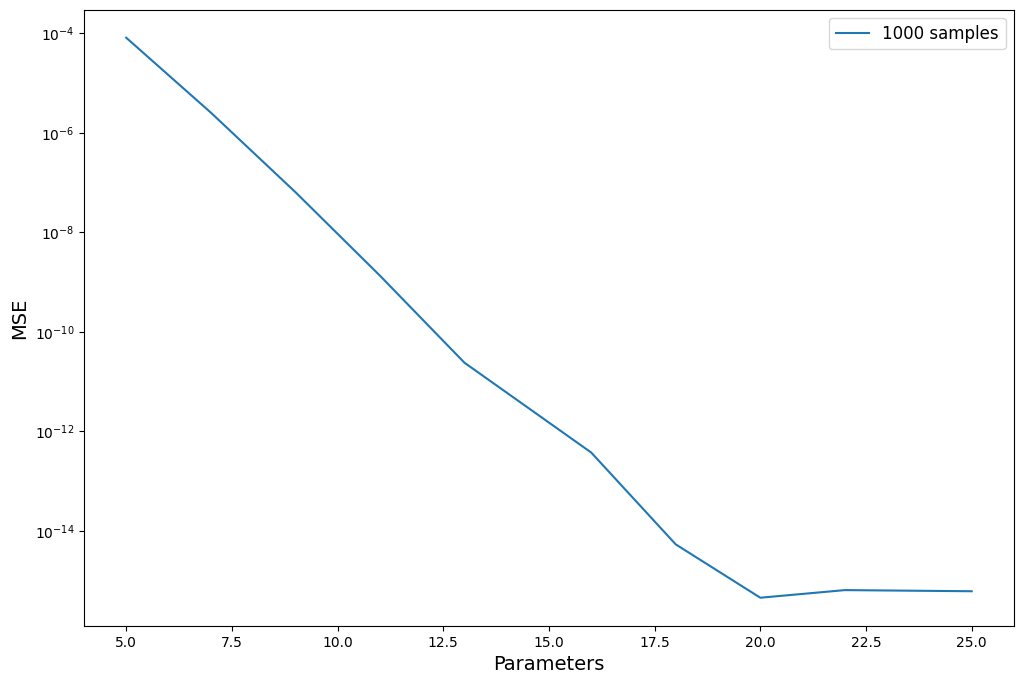

Error: 0.0003262355511072541, Progress: 25.50%, approx. 127.3 seconds remaining.
Error: 1.0175785038295438e-05, Progress: 26.00%, approx. 124.0 seconds remaining.
Error: 2.505634078397855e-07, Progress: 26.50%, approx. 120.9 seconds remaining.
Error: 5.2785220826758985e-09, Progress: 27.00%, approx. 117.8 seconds remaining.
Error: 9.509114737189296e-11, Progress: 27.50%, approx. 114.9 seconds remaining.
Error: 1.4761150739485742e-12, Progress: 28.00%, approx. 112.1 seconds remaining.
Error: 2.0393445551948905e-14, Progress: 28.50%, approx. 109.3 seconds remaining.
Error: 1.2884854492358661e-15, Progress: 29.00%, approx. 106.7 seconds remaining.
Error: 1.474508260573325e-15, Progress: 29.50%, approx. 104.1 seconds remaining.
Error: 1.828241035853765e-15, Progress: 30.00%, approx. 101.7 seconds remaining.


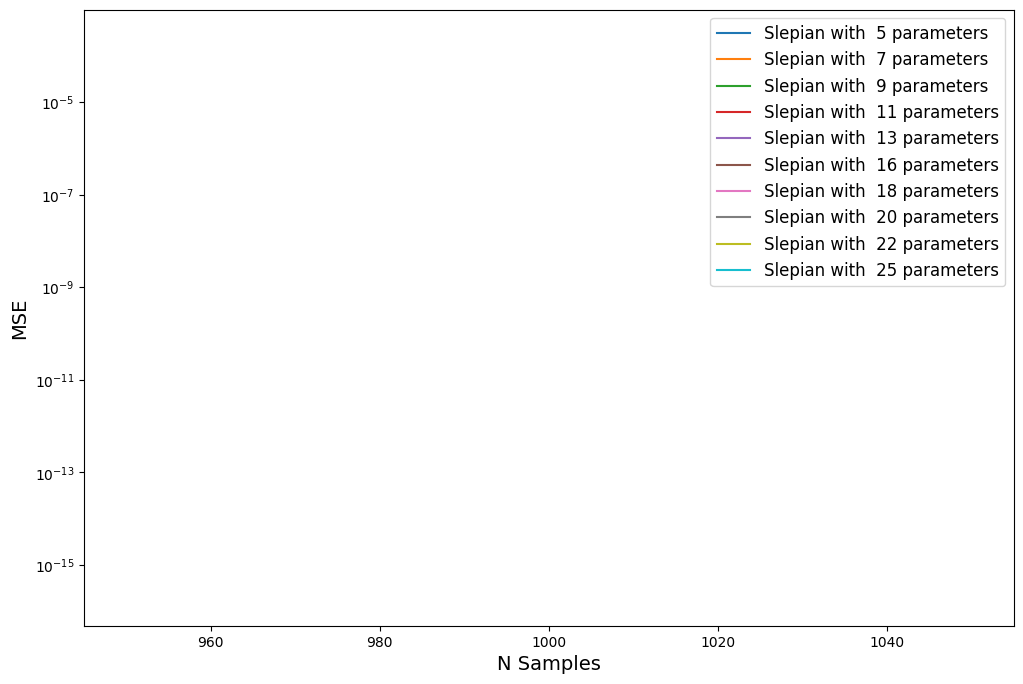

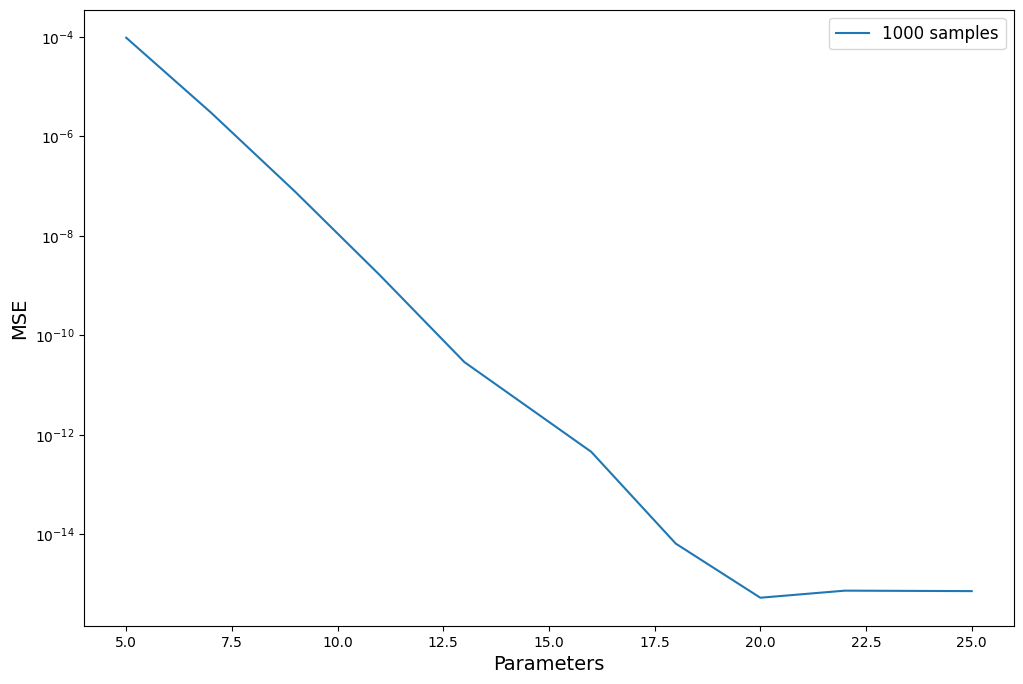

Error: 0.0003213593170813731, Progress: 30.50%, approx. 114.8 seconds remaining.
Error: 9.751051042938028e-06, Progress: 31.00%, approx. 112.1 seconds remaining.
Error: 2.5263982502543854e-07, Progress: 31.50%, approx. 109.5 seconds remaining.
Error: 5.169060512074582e-09, Progress: 32.00%, approx. 107.0 seconds remaining.
Error: 9.385825849512713e-11, Progress: 32.50%, approx. 104.6 seconds remaining.
Error: 1.4232144135883523e-12, Progress: 33.00%, approx. 102.3 seconds remaining.
Error: 2.0101064475373367e-14, Progress: 33.50%, approx. 100.0 seconds remaining.
Error: 1.5506759656786368e-15, Progress: 34.00%, approx. 97.8 seconds remaining.
Error: 1.7865727402177083e-15, Progress: 34.50%, approx. 95.6 seconds remaining.
Error: 2.022724588019124e-15, Progress: 35.00%, approx. 93.5 seconds remaining.


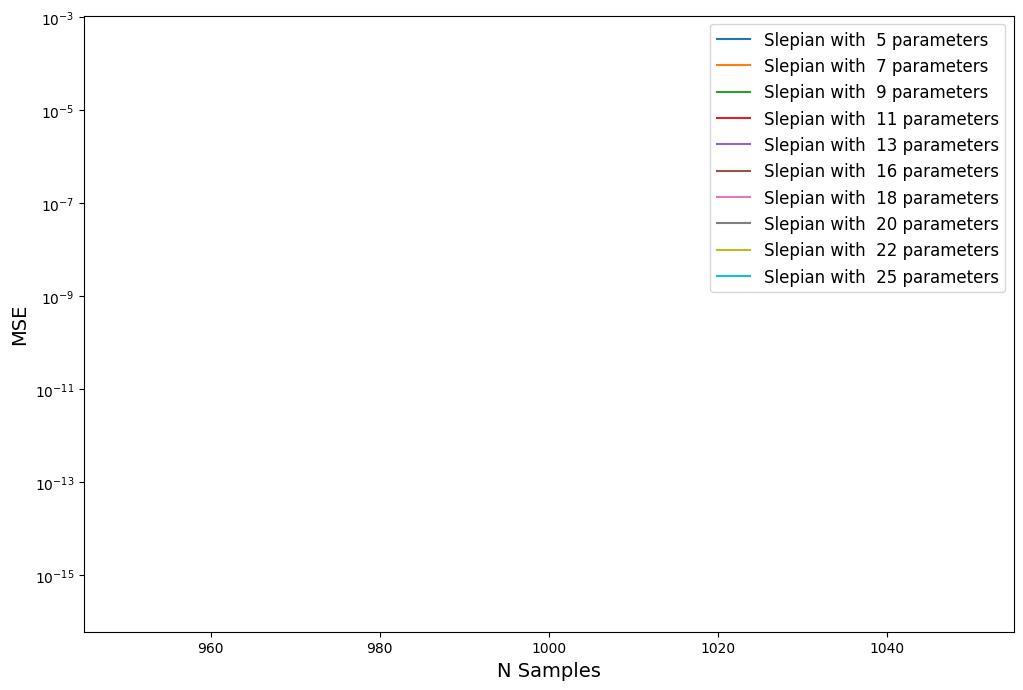

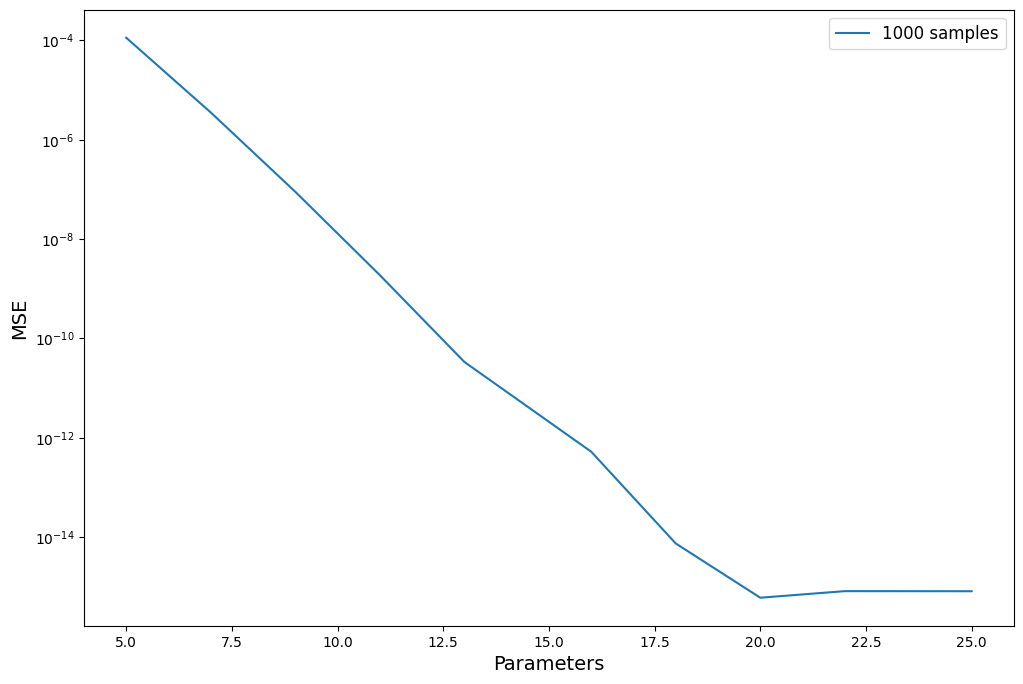

Error: 0.0003265120999834626, Progress: 35.50%, approx. 104.9 seconds remaining.
Error: 1.0249045303123498e-05, Progress: 36.00%, approx. 102.6 seconds remaining.
Error: 2.555636487820002e-07, Progress: 36.50%, approx. 100.4 seconds remaining.
Error: 5.2935526286486906e-09, Progress: 37.00%, approx. 98.3 seconds remaining.
Error: 9.266993163238832e-11, Progress: 37.50%, approx. 96.2 seconds remaining.
Error: 1.4513888990267936e-12, Progress: 38.00%, approx. 94.2 seconds remaining.
Error: 2.0503664525503703e-14, Progress: 38.50%, approx. 92.2 seconds remaining.
Error: 1.351675444918325e-15, Progress: 39.00%, approx. 90.3 seconds remaining.
Error: 1.2007461079308683e-15, Progress: 39.50%, approx. 88.4 seconds remaining.
Error: 1.6900934985966628e-15, Progress: 40.00%, approx. 86.6 seconds remaining.


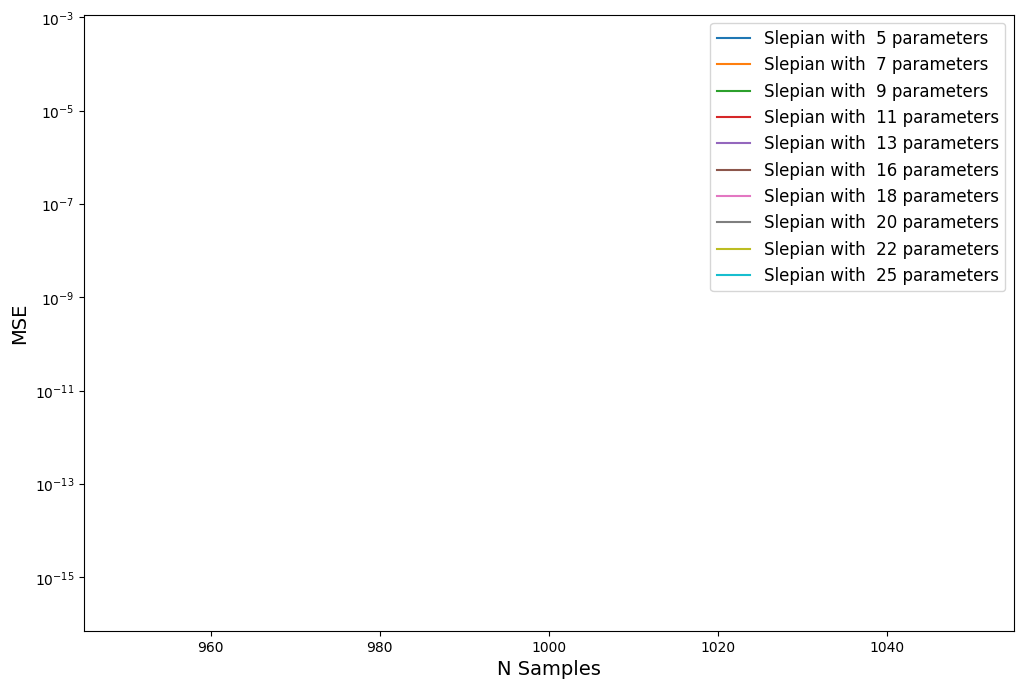

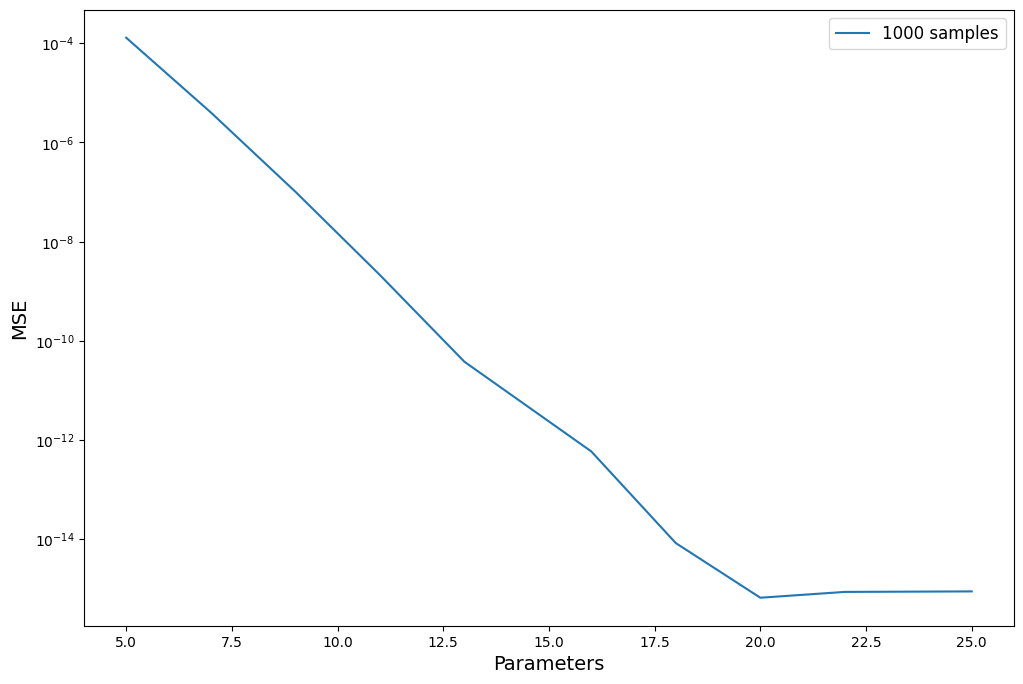

Error: 0.00031724990187207493, Progress: 40.50%, approx. 95.3 seconds remaining.
Error: 9.986748137765669e-06, Progress: 41.00%, approx. 93.3 seconds remaining.
Error: 2.5076349166907796e-07, Progress: 41.50%, approx. 91.4 seconds remaining.
Error: 5.175788451701519e-09, Progress: 42.00%, approx. 89.5 seconds remaining.
Error: 9.202925826789812e-11, Progress: 42.50%, approx. 87.7 seconds remaining.
Error: 1.4694004960593668e-12, Progress: 43.00%, approx. 86.0 seconds remaining.
Error: 2.050749685319524e-14, Progress: 43.50%, approx. 84.2 seconds remaining.
Error: 1.6668326641668237e-15, Progress: 44.00%, approx. 82.5 seconds remaining.
Error: 1.641895614839144e-15, Progress: 44.50%, approx. 80.9 seconds remaining.
Error: 2.406665459357046e-15, Progress: 45.00%, approx. 79.3 seconds remaining.


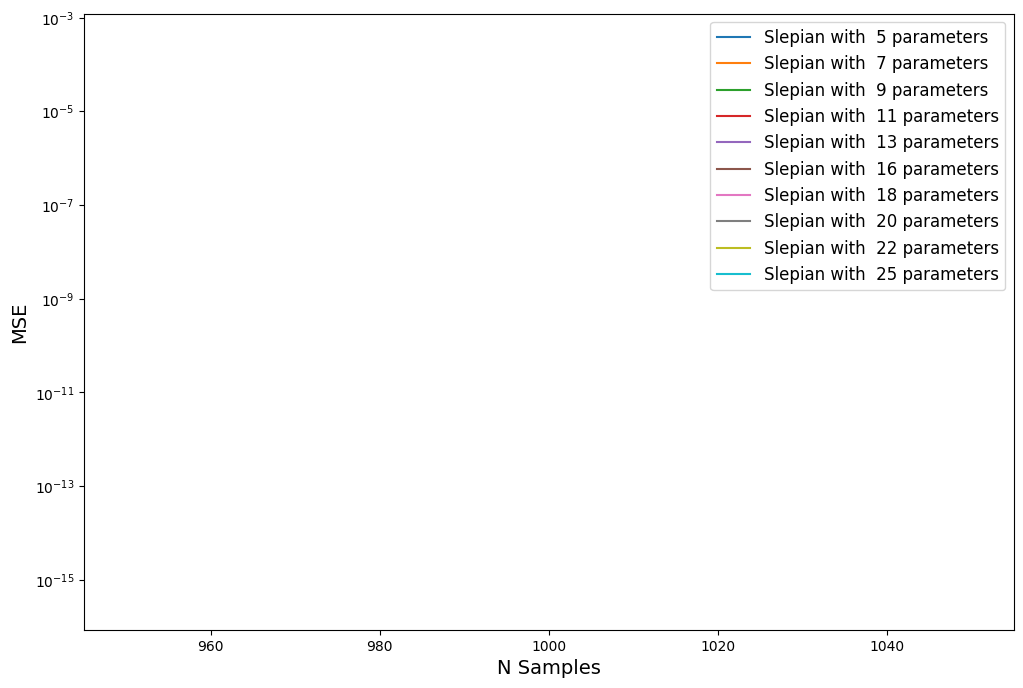

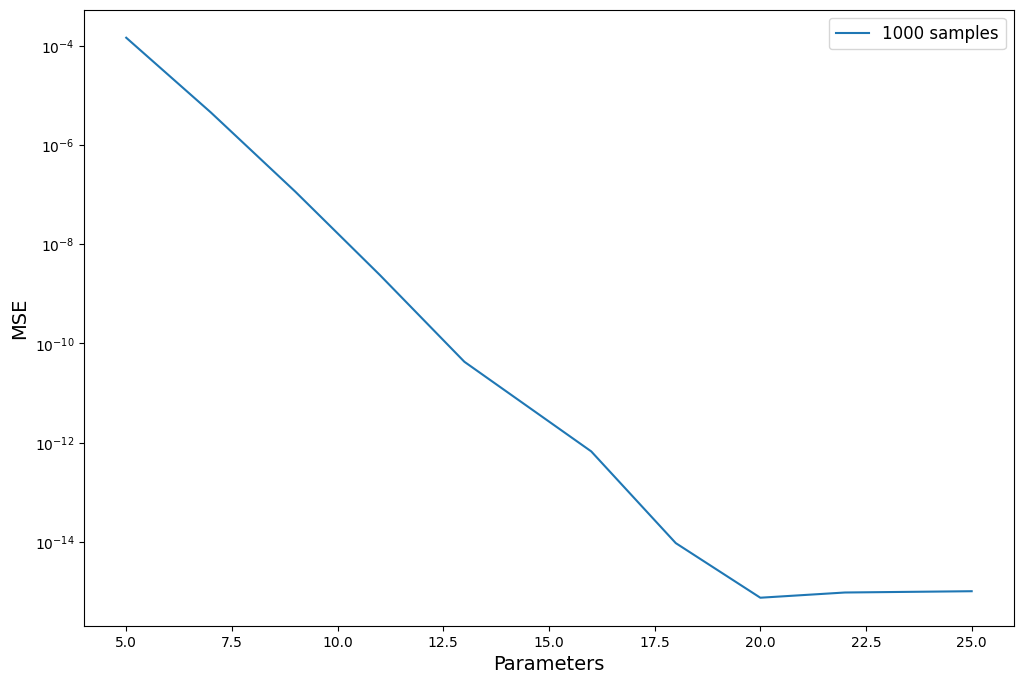

Error: 0.0003270579695119813, Progress: 45.50%, approx. 85.9 seconds remaining.
Error: 1.0256104636036155e-05, Progress: 46.00%, approx. 84.1 seconds remaining.
Error: 2.4819643189532667e-07, Progress: 46.50%, approx. 82.5 seconds remaining.
Error: 5.319519042848111e-09, Progress: 47.00%, approx. 80.8 seconds remaining.
Error: 9.22997527773156e-11, Progress: 47.50%, approx. 79.2 seconds remaining.
Error: 1.4651911735897518e-12, Progress: 48.00%, approx. 77.7 seconds remaining.
Error: 2.0678992717677087e-14, Progress: 48.50%, approx. 76.1 seconds remaining.
Error: 1.6800979757607713e-15, Progress: 49.00%, approx. 74.6 seconds remaining.
Error: 1.9427031321980158e-15, Progress: 49.50%, approx. 73.1 seconds remaining.
Error: 2.1803547843867036e-15, Progress: 50.00%, approx. 71.7 seconds remaining.


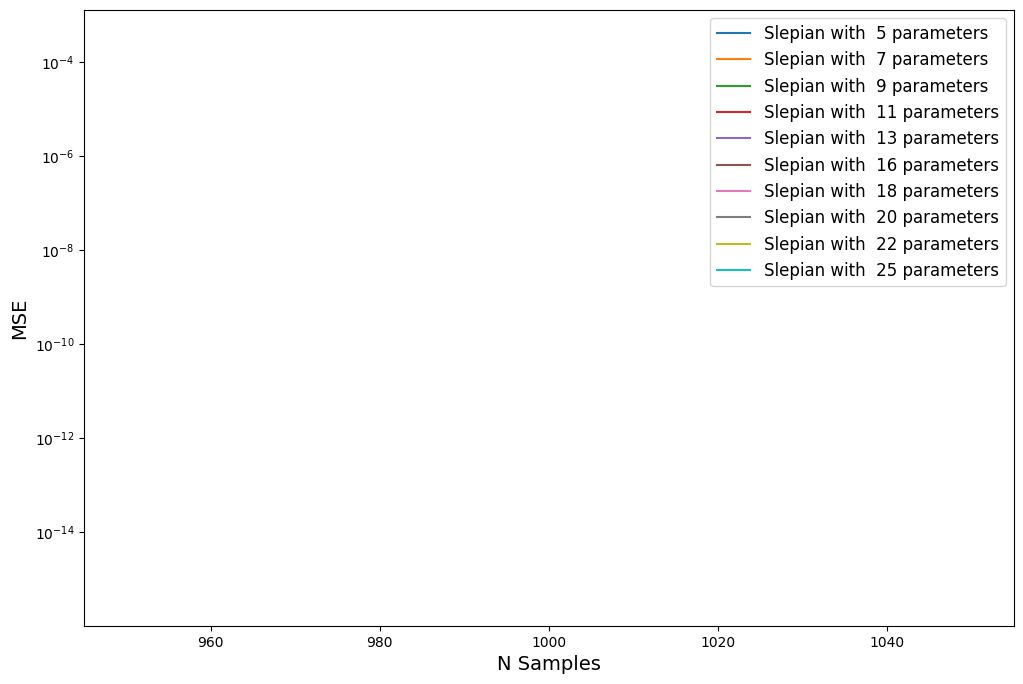

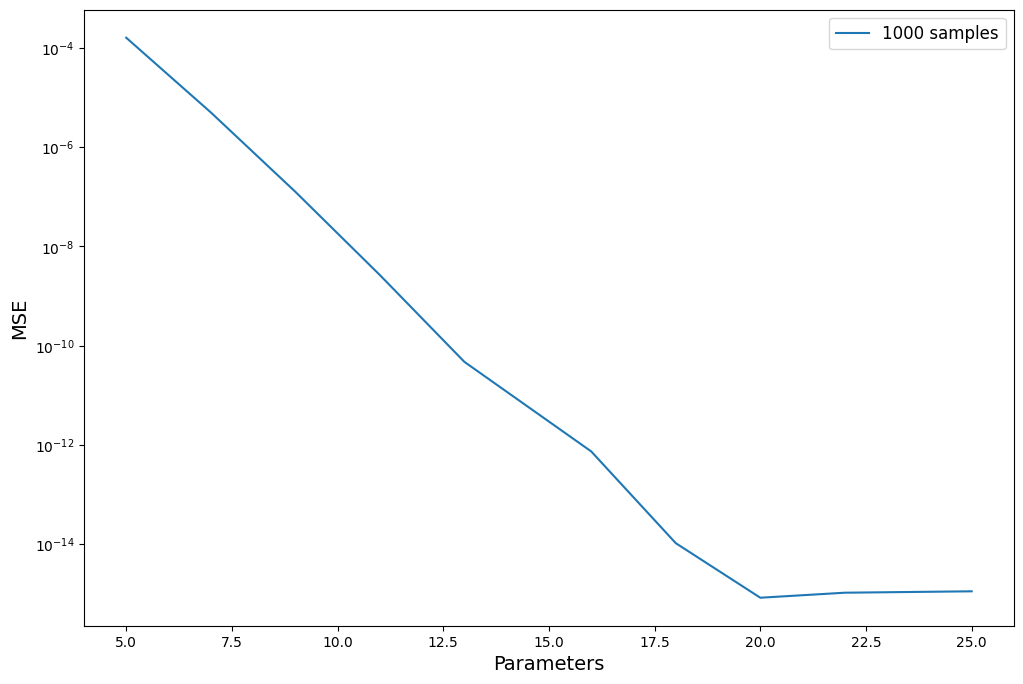

Error: 0.00031422704602622356, Progress: 50.50%, approx. 77.0 seconds remaining.
Error: 9.910542646497796e-06, Progress: 51.00%, approx. 75.5 seconds remaining.
Error: 2.5157408033132017e-07, Progress: 51.50%, approx. 74.0 seconds remaining.
Error: 5.206661724177043e-09, Progress: 52.00%, approx. 72.6 seconds remaining.
Error: 9.041047519500368e-11, Progress: 52.50%, approx. 71.1 seconds remaining.
Error: 1.4336882559280496e-12, Progress: 53.00%, approx. 69.7 seconds remaining.
Error: 2.019187066259828e-14, Progress: 53.50%, approx. 68.3 seconds remaining.
Error: 1.009460783943211e-15, Progress: 54.00%, approx. 67.0 seconds remaining.
Error: 1.270848975280673e-15, Progress: 54.50%, approx. 65.6 seconds remaining.
Error: 1.589139900934481e-15, Progress: 55.00%, approx. 64.3 seconds remaining.


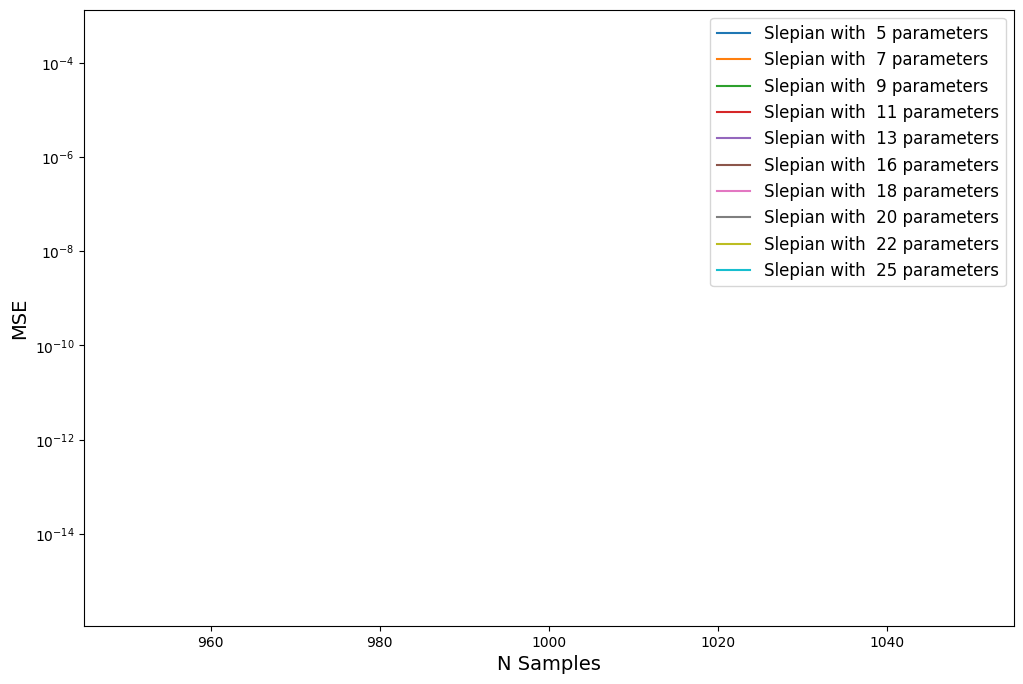

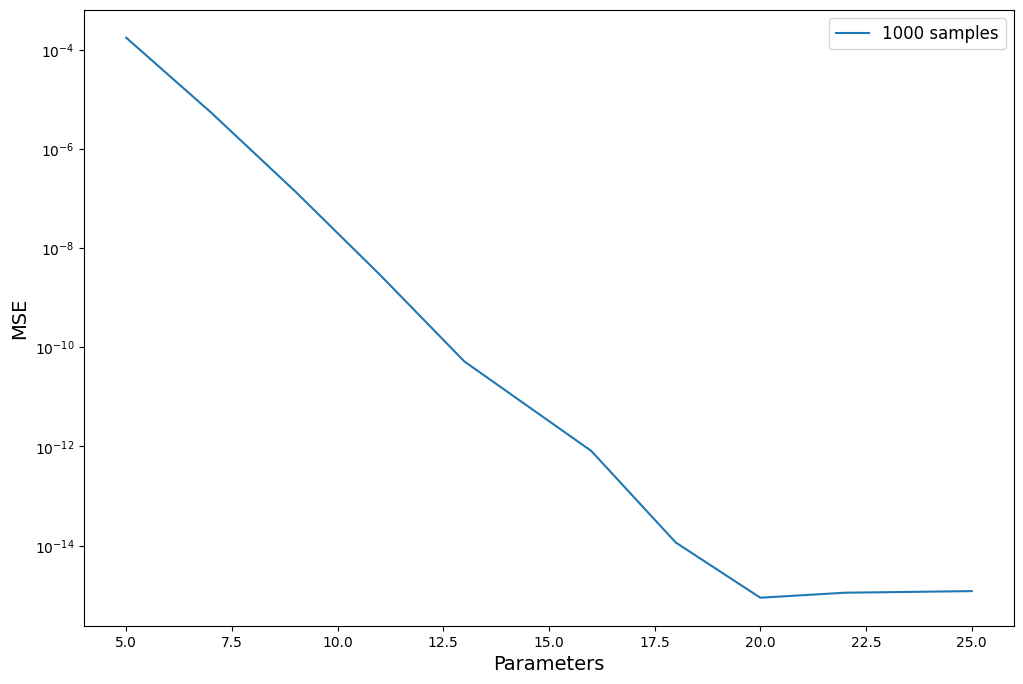

Error: 0.00030657227540502855, Progress: 55.50%, approx. 69.1 seconds remaining.
Error: 9.573512391740678e-06, Progress: 56.00%, approx. 67.7 seconds remaining.
Error: 2.4306563905775174e-07, Progress: 56.50%, approx. 66.3 seconds remaining.
Error: 5.133864683963644e-09, Progress: 57.00%, approx. 65.0 seconds remaining.
Error: 9.186173995758324e-11, Progress: 57.50%, approx. 63.7 seconds remaining.
Error: 1.4308651608738895e-12, Progress: 58.00%, approx. 62.4 seconds remaining.
Error: 2.0070155105985088e-14, Progress: 58.50%, approx. 61.1 seconds remaining.
Error: 1.2717021999907427e-15, Progress: 59.00%, approx. 59.9 seconds remaining.
Error: 1.8266964715919995e-15, Progress: 59.50%, approx. 58.7 seconds remaining.
Error: 2.210275317335054e-15, Progress: 60.00%, approx. 57.4 seconds remaining.


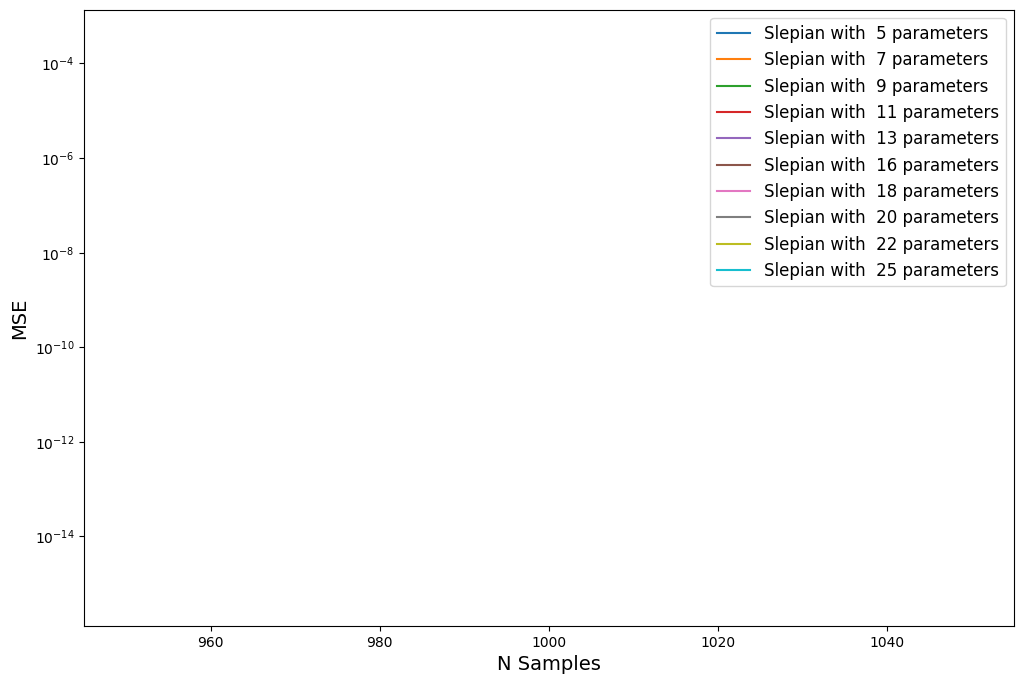

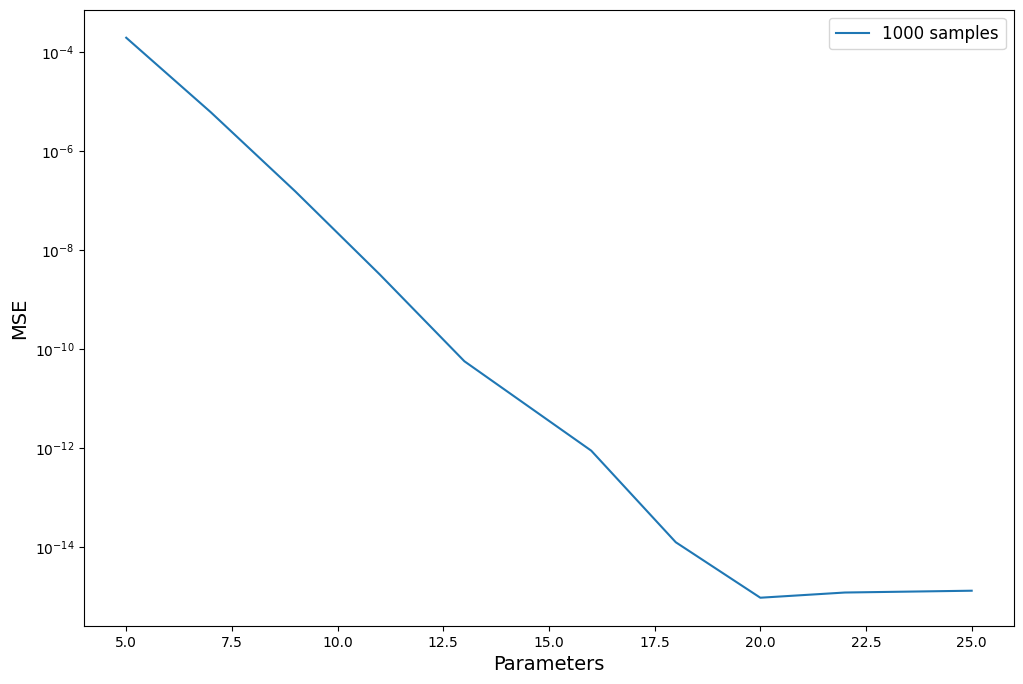

Error: 0.00032133965362702134, Progress: 60.50%, approx. 61.1 seconds remaining.
Error: 1.0074680560058609e-05, Progress: 61.00%, approx. 59.8 seconds remaining.
Error: 2.5100944564397037e-07, Progress: 61.50%, approx. 58.6 seconds remaining.
Error: 5.245957757659629e-09, Progress: 62.00%, approx. 57.4 seconds remaining.
Error: 9.505329090861893e-11, Progress: 62.50%, approx. 56.2 seconds remaining.
Error: 1.4517831181438932e-12, Progress: 63.00%, approx. 55.0 seconds remaining.
Error: 2.0418222692028842e-14, Progress: 63.50%, approx. 53.8 seconds remaining.
Error: 9.09766633235257e-16, Progress: 64.00%, approx. 52.7 seconds remaining.
Error: 1.7209531257530335e-15, Progress: 64.50%, approx. 51.5 seconds remaining.
Error: 1.6699208442042758e-15, Progress: 65.00%, approx. 50.4 seconds remaining.


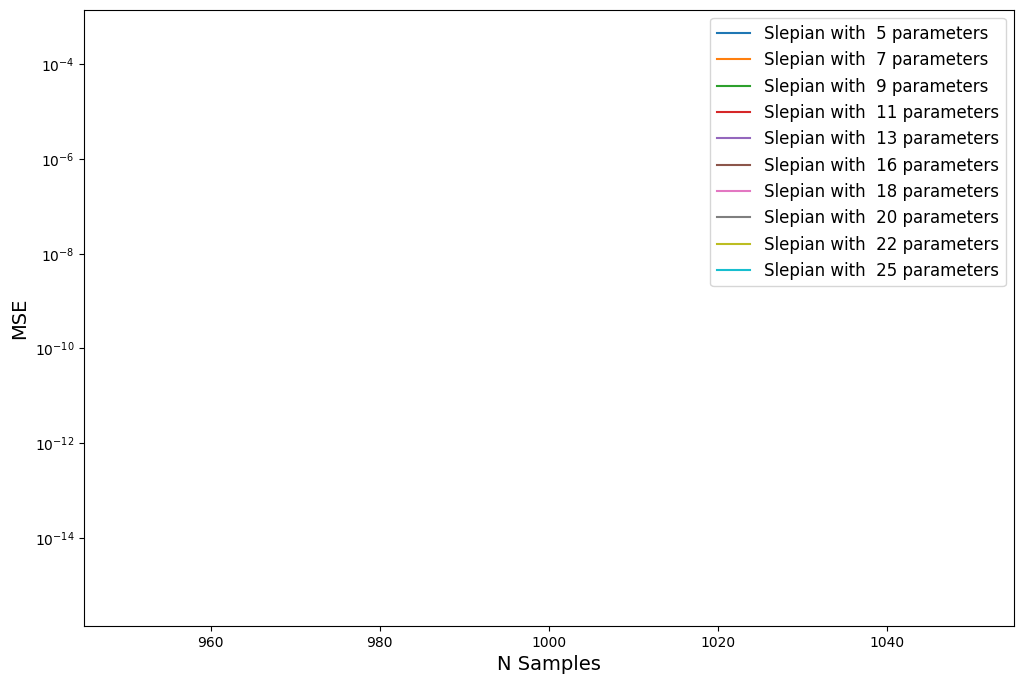

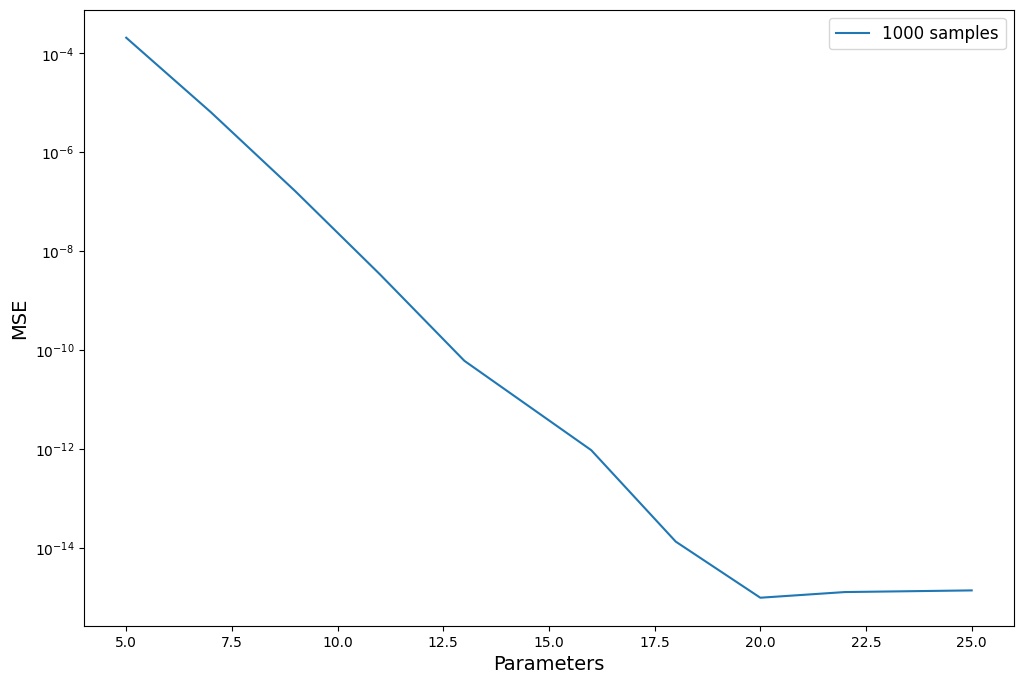

Error: 0.00032462783063146245, Progress: 65.50%, approx. 52.9 seconds remaining.
Error: 1.0093639138943201e-05, Progress: 66.00%, approx. 51.7 seconds remaining.
Error: 2.541812327756043e-07, Progress: 66.50%, approx. 50.6 seconds remaining.
Error: 5.391172820799587e-09, Progress: 67.00%, approx. 49.5 seconds remaining.
Error: 9.806660577508747e-11, Progress: 67.50%, approx. 48.4 seconds remaining.
Error: 1.5913783213378883e-12, Progress: 68.00%, approx. 47.3 seconds remaining.
Error: 2.3039810331650597e-14, Progress: 68.50%, approx. 46.2 seconds remaining.
Error: 8.541072076168956e-16, Progress: 69.00%, approx. 45.1 seconds remaining.
Error: 1.8032872451976095e-15, Progress: 69.50%, approx. 44.1 seconds remaining.
Error: 2.159134039624469e-15, Progress: 70.00%, approx. 43.1 seconds remaining.


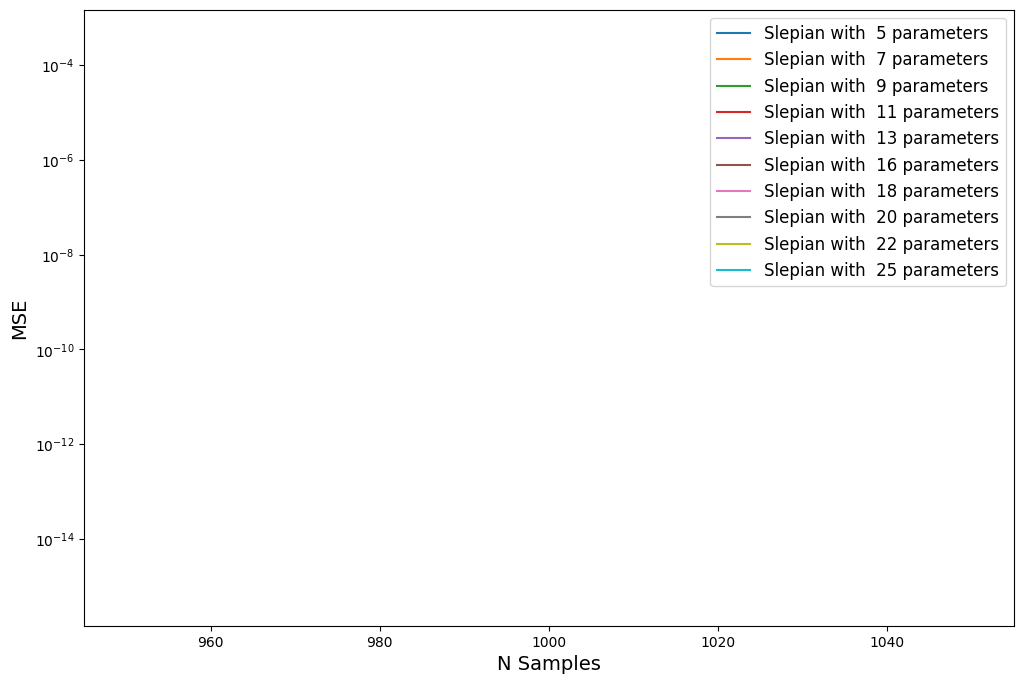

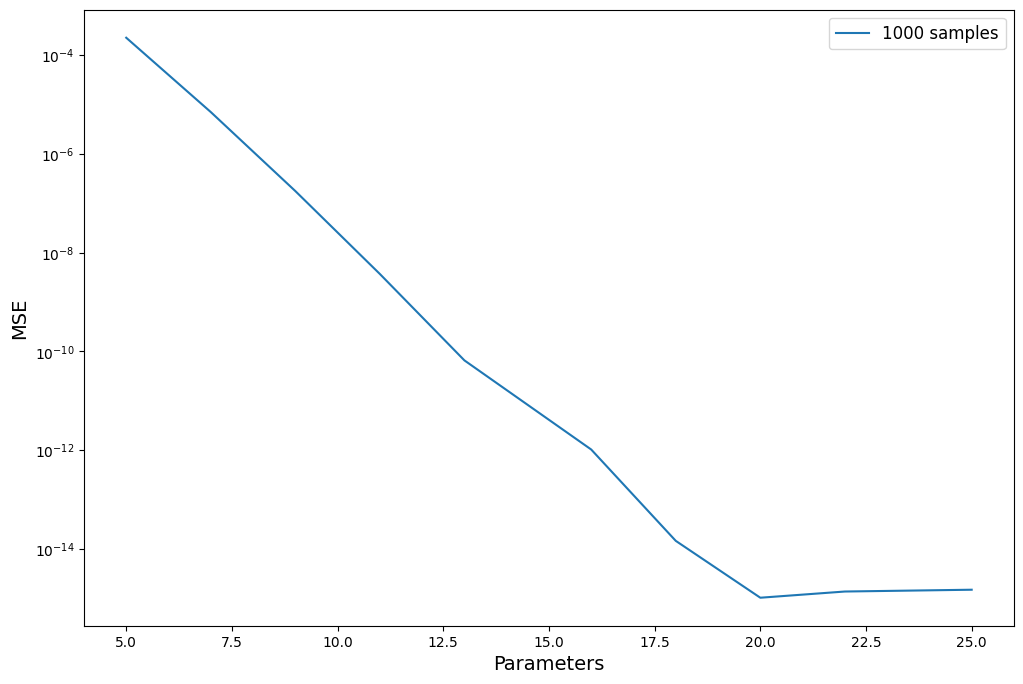

Error: 0.0003109734836876194, Progress: 70.50%, approx. 44.9 seconds remaining.
Error: 9.957468154621116e-06, Progress: 71.00%, approx. 43.8 seconds remaining.
Error: 2.4650277636649205e-07, Progress: 71.50%, approx. 42.7 seconds remaining.
Error: 5.0385391235981e-09, Progress: 72.00%, approx. 41.7 seconds remaining.
Error: 8.812632726868388e-11, Progress: 72.50%, approx. 40.7 seconds remaining.
Error: 1.4140395055413708e-12, Progress: 73.00%, approx. 39.6 seconds remaining.
Error: 2.0235891045500622e-14, Progress: 73.50%, approx. 38.6 seconds remaining.
Error: 8.258895277699103e-16, Progress: 74.00%, approx. 37.7 seconds remaining.
Error: 1.2034172329319923e-15, Progress: 74.50%, approx. 36.7 seconds remaining.
Error: 1.1614970544277636e-15, Progress: 75.00%, approx. 35.7 seconds remaining.


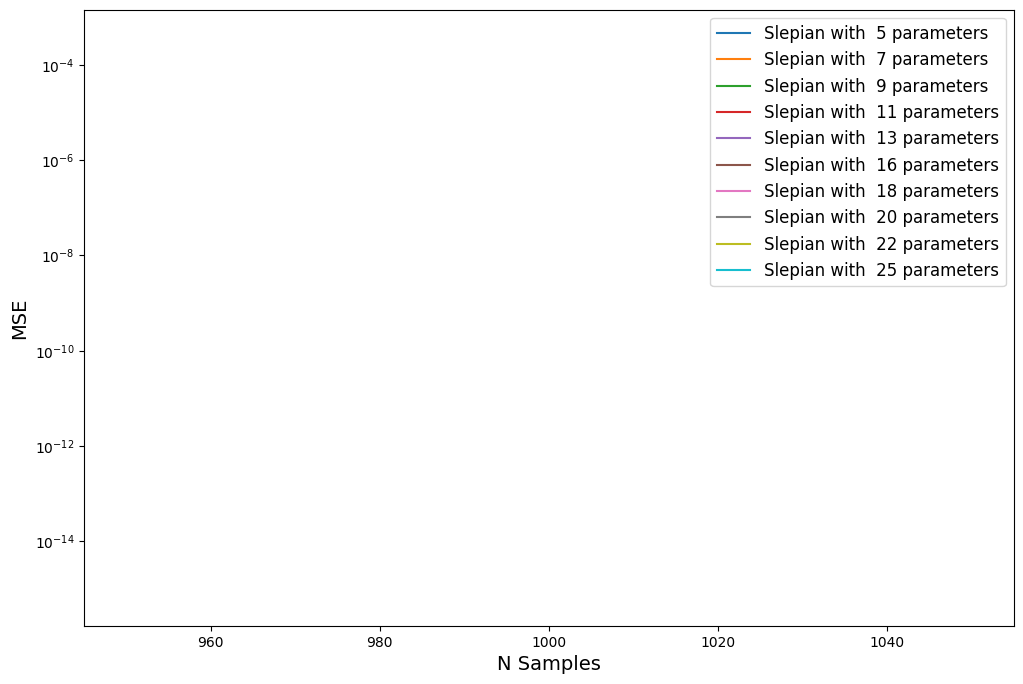

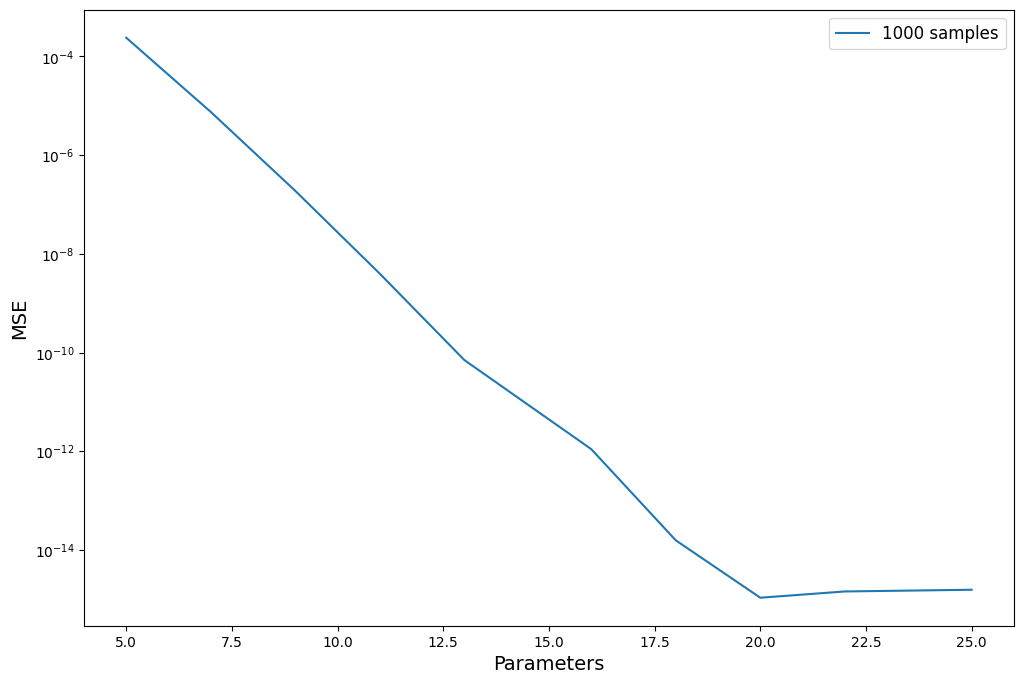

Error: 0.0003161934033140525, Progress: 75.50%, approx. 36.9 seconds remaining.
Error: 9.894289971318606e-06, Progress: 76.00%, approx. 35.9 seconds remaining.
Error: 2.446285711204778e-07, Progress: 76.50%, approx. 34.9 seconds remaining.
Error: 5.166398427773591e-09, Progress: 77.00%, approx. 34.0 seconds remaining.
Error: 9.17001513261444e-11, Progress: 77.50%, approx. 33.0 seconds remaining.
Error: 1.4615446372840708e-12, Progress: 78.00%, approx. 32.1 seconds remaining.
Error: 1.9839290934869598e-14, Progress: 78.50%, approx. 31.2 seconds remaining.
Error: 2.0983097681168612e-15, Progress: 79.00%, approx. 30.2 seconds remaining.
Error: 1.5091970137971712e-15, Progress: 79.50%, approx. 29.3 seconds remaining.
Error: 4.151163826029466e-15, Progress: 80.00%, approx. 28.4 seconds remaining.


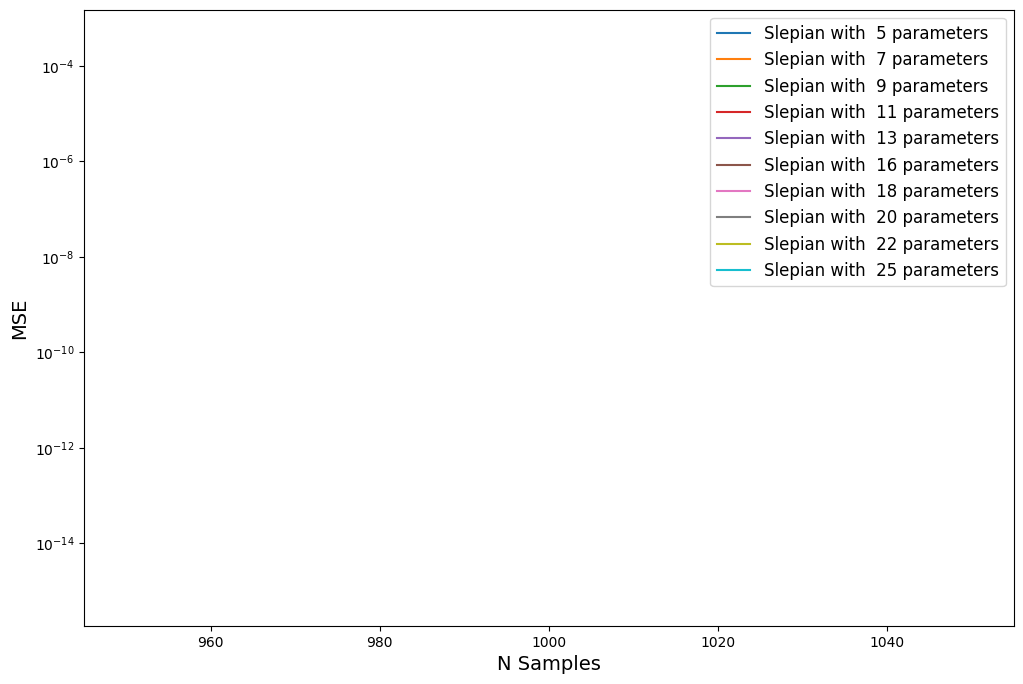

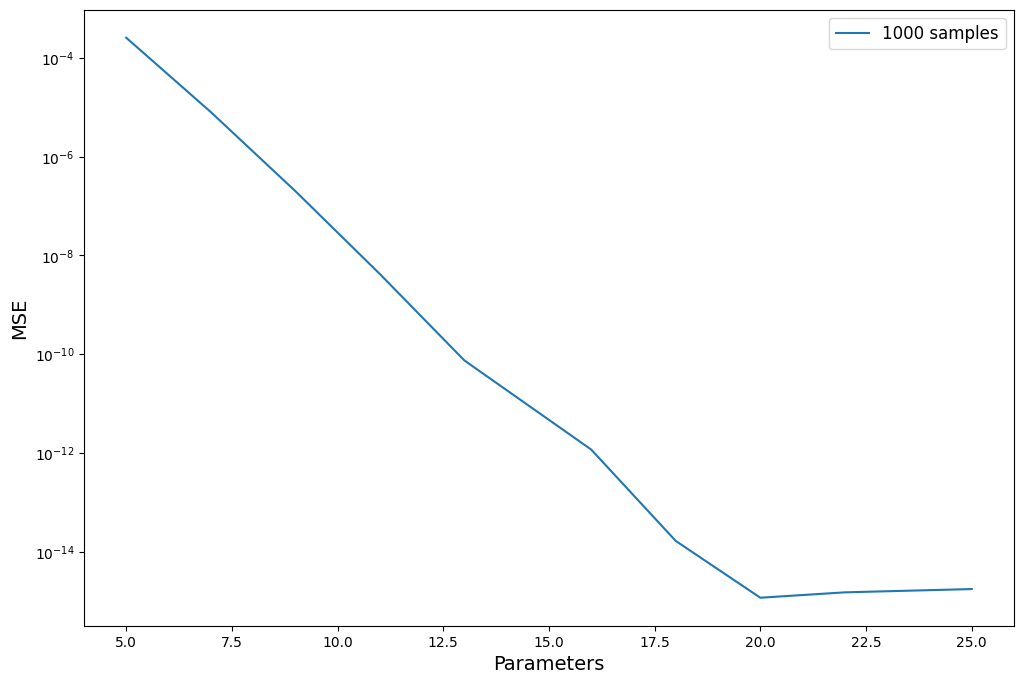

Error: 0.00032942108742648585, Progress: 80.50%, approx. 29.2 seconds remaining.
Error: 1.0103275642828767e-05, Progress: 81.00%, approx. 28.3 seconds remaining.
Error: 2.5070840901997187e-07, Progress: 81.50%, approx. 27.3 seconds remaining.
Error: 5.151044226717059e-09, Progress: 82.00%, approx. 26.4 seconds remaining.
Error: 9.480997512941984e-11, Progress: 82.50%, approx. 25.6 seconds remaining.
Error: 1.4557971247946064e-12, Progress: 83.00%, approx. 24.7 seconds remaining.
Error: 2.016390926779667e-14, Progress: 83.50%, approx. 23.8 seconds remaining.
Error: 3.252479783029215e-15, Progress: 84.00%, approx. 22.9 seconds remaining.
Error: 1.0702457822299088e-15, Progress: 84.50%, approx. 22.1 seconds remaining.
Error: 1.7237834808320916e-15, Progress: 85.00%, approx. 21.3 seconds remaining.


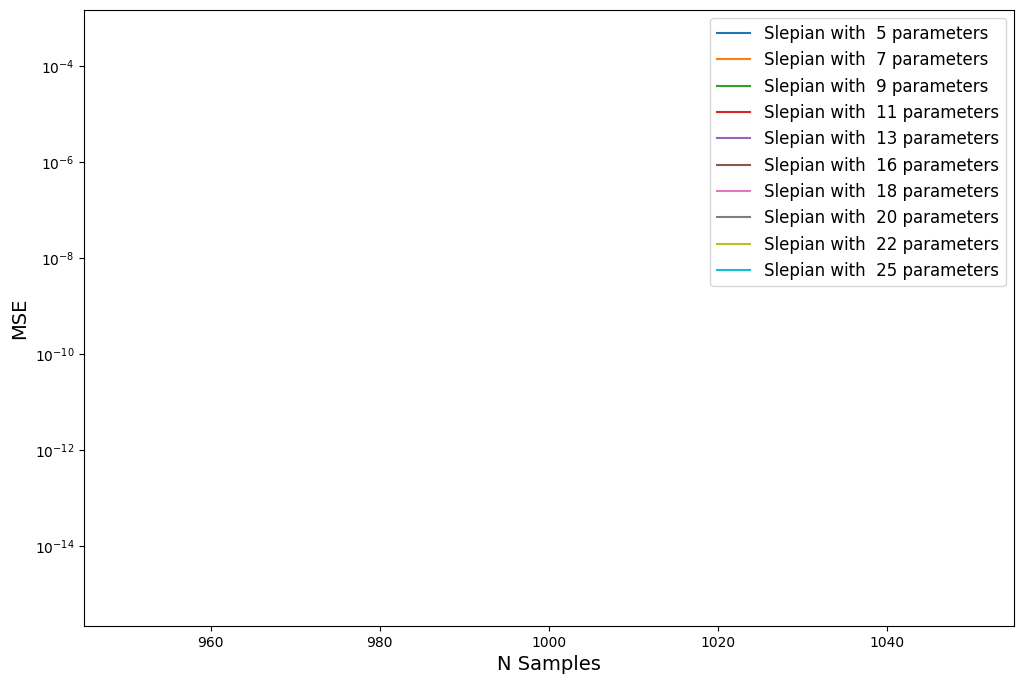

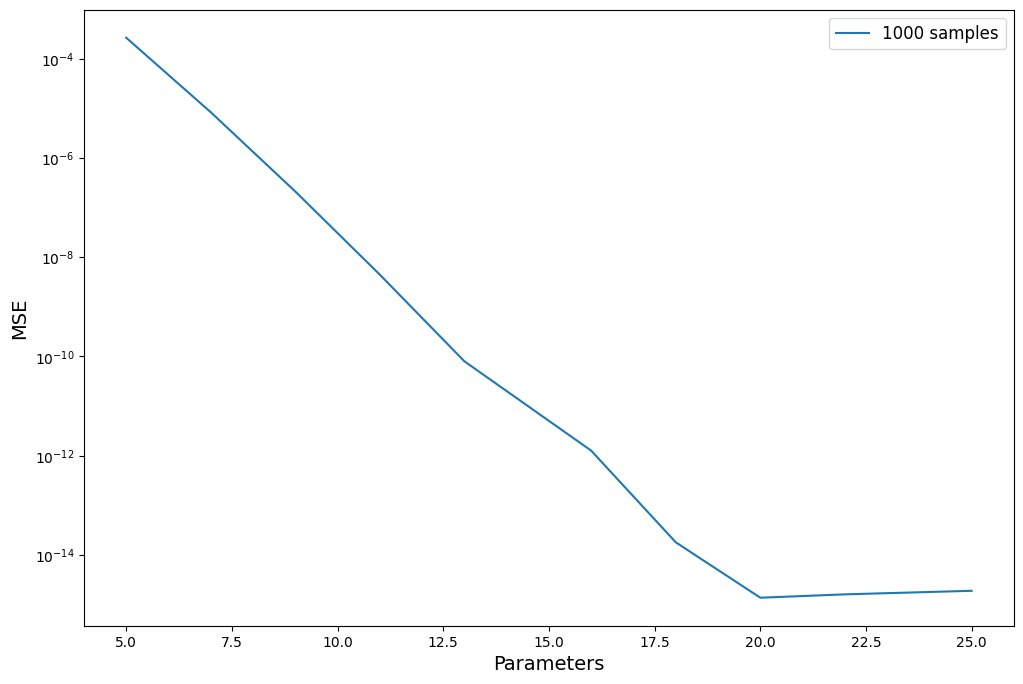

Error: 0.0003149141467086215, Progress: 85.50%, approx. 21.5 seconds remaining.
Error: 9.898334176528084e-06, Progress: 86.00%, approx. 20.7 seconds remaining.
Error: 2.5197897484163575e-07, Progress: 86.50%, approx. 19.8 seconds remaining.
Error: 5.238327224555698e-09, Progress: 87.00%, approx. 19.0 seconds remaining.
Error: 9.309812619990307e-11, Progress: 87.50%, approx. 18.1 seconds remaining.
Error: 1.4610973017773247e-12, Progress: 88.00%, approx. 17.3 seconds remaining.
Error: 2.075845746123009e-14, Progress: 88.50%, approx. 16.5 seconds remaining.
Error: 1.0350530126753675e-15, Progress: 89.00%, approx. 15.7 seconds remaining.
Error: 9.168318266288339e-16, Progress: 89.50%, approx. 14.9 seconds remaining.
Error: 1.3632254873562505e-15, Progress: 90.00%, approx. 14.1 seconds remaining.


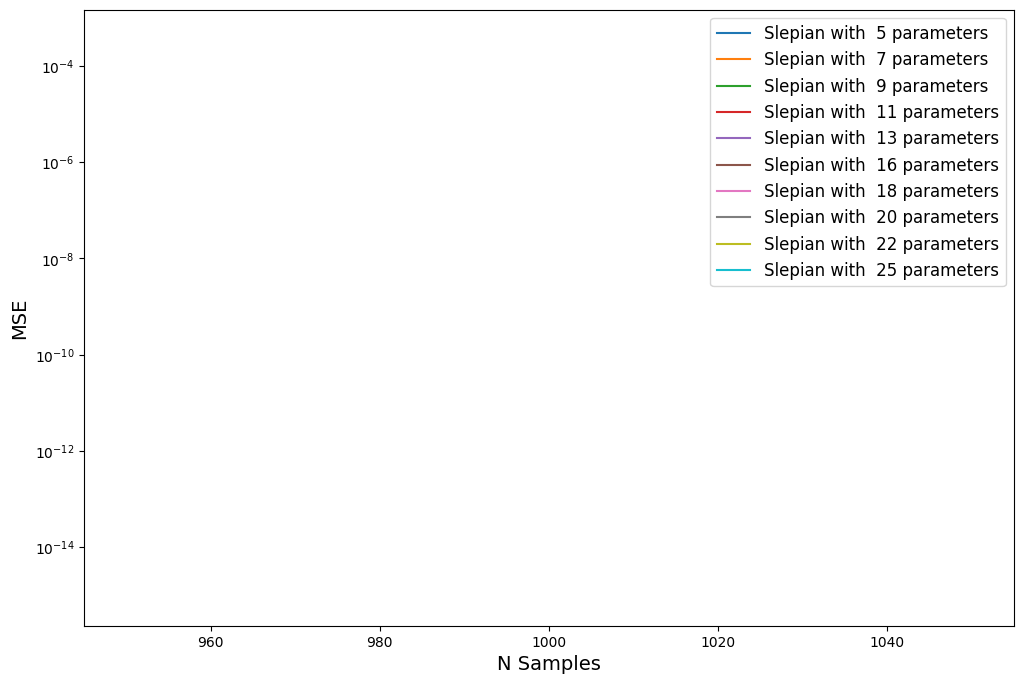

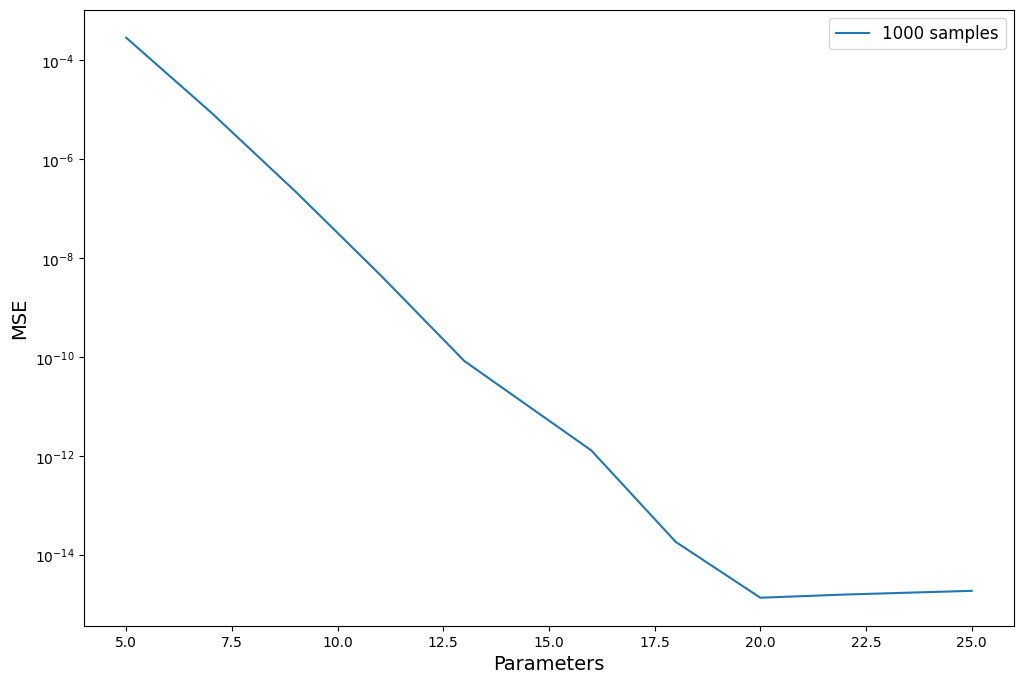

Error: 0.00032410543178103247, Progress: 90.50%, approx. 14.1 seconds remaining.
Error: 9.987531054687568e-06, Progress: 91.00%, approx. 13.3 seconds remaining.
Error: 2.504508049729292e-07, Progress: 91.50%, approx. 12.5 seconds remaining.
Error: 5.2682589395942245e-09, Progress: 92.00%, approx. 11.7 seconds remaining.
Error: 9.60287306950729e-11, Progress: 92.50%, approx. 10.9 seconds remaining.
Error: 1.4798587363560496e-12, Progress: 93.00%, approx. 10.1 seconds remaining.
Error: 2.0582545592563006e-14, Progress: 93.50%, approx. 9.3 seconds remaining.
Error: 1.141415102789423e-15, Progress: 94.00%, approx. 8.6 seconds remaining.
Error: 1.4338047882850877e-15, Progress: 94.50%, approx. 7.8 seconds remaining.
Error: 1.4411105413918652e-15, Progress: 95.00%, approx. 7.1 seconds remaining.


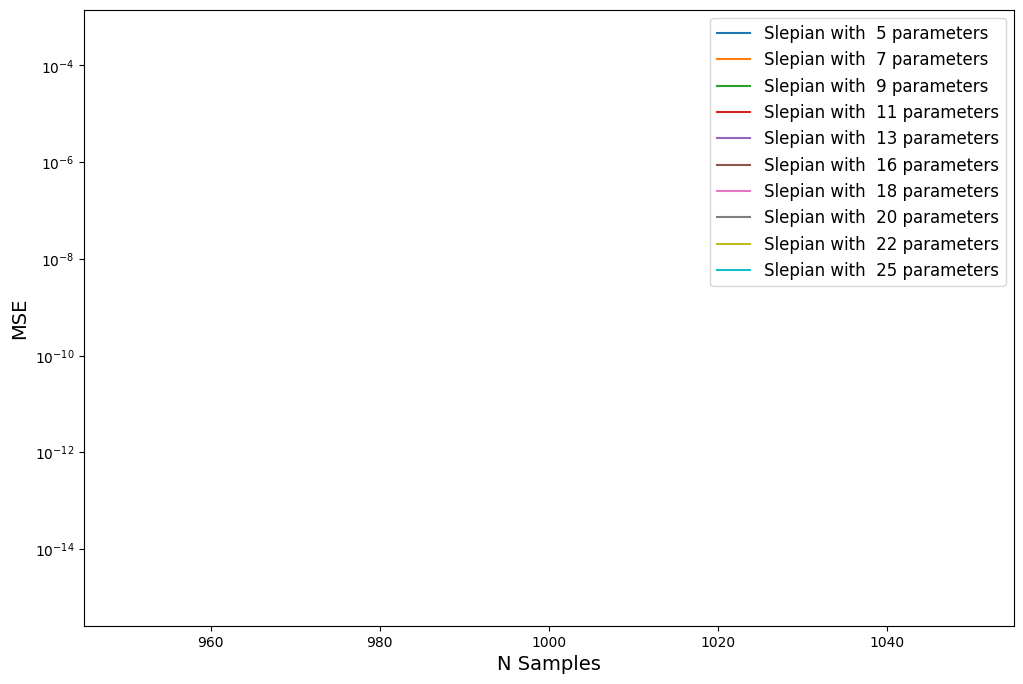

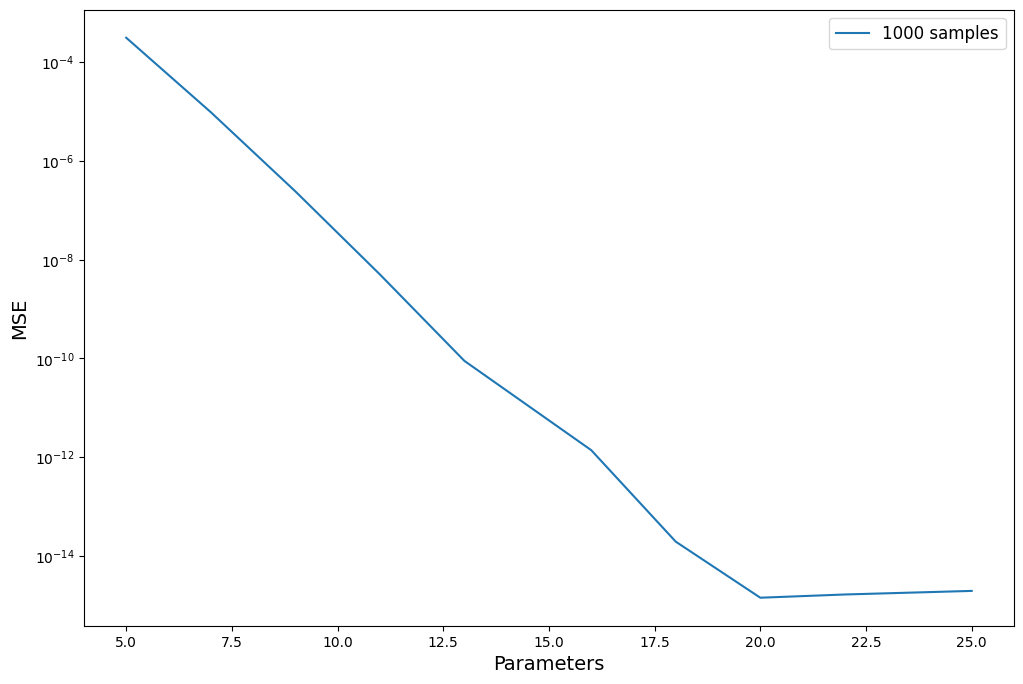

Error: 0.0003245606076685058, Progress: 95.50%, approx. 6.7 seconds remaining.
Error: 1.0193895196210402e-05, Progress: 96.00%, approx. 5.9 seconds remaining.
Error: 2.5098015325271415e-07, Progress: 96.50%, approx. 5.1 seconds remaining.
Error: 5.284168087532747e-09, Progress: 97.00%, approx. 4.4 seconds remaining.
Error: 9.424931049229907e-11, Progress: 97.50%, approx. 3.6 seconds remaining.
Error: 1.456718093082523e-12, Progress: 98.00%, approx. 2.9 seconds remaining.
Error: 2.0369558372195442e-14, Progress: 98.50%, approx. 2.2 seconds remaining.
Error: 1.2131187066996907e-15, Progress: 99.00%, approx. 1.4 seconds remaining.
Error: 1.6347859680767703e-15, Progress: 99.50%, approx. 0.7 seconds remaining.
Error: 1.9077624846025427e-15, Progress: 100.00%, approx. 0.0 seconds remaining.


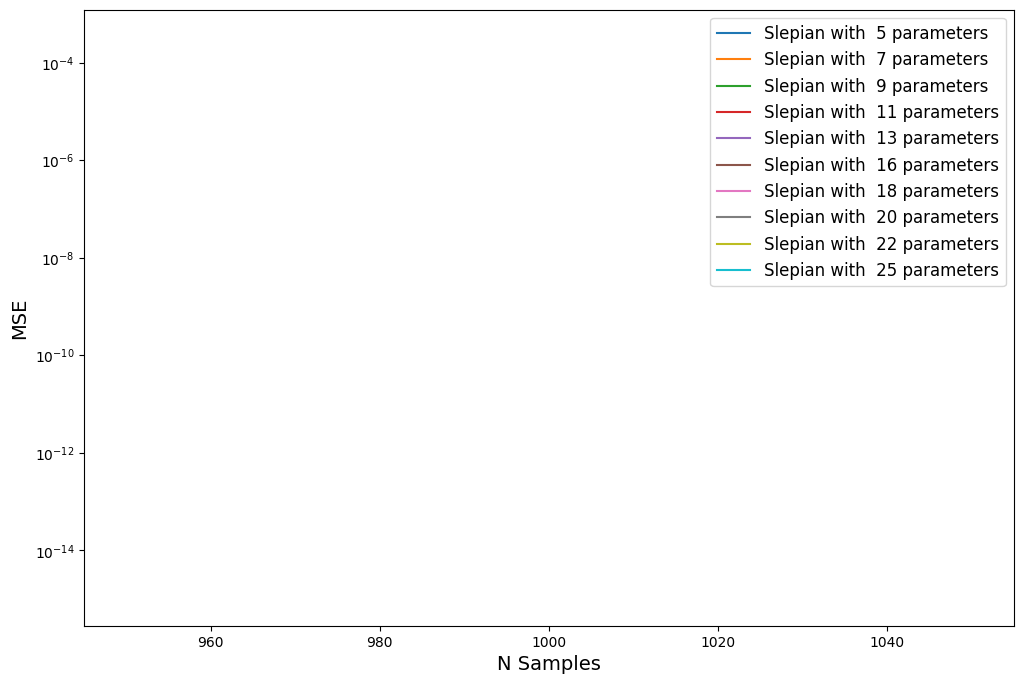

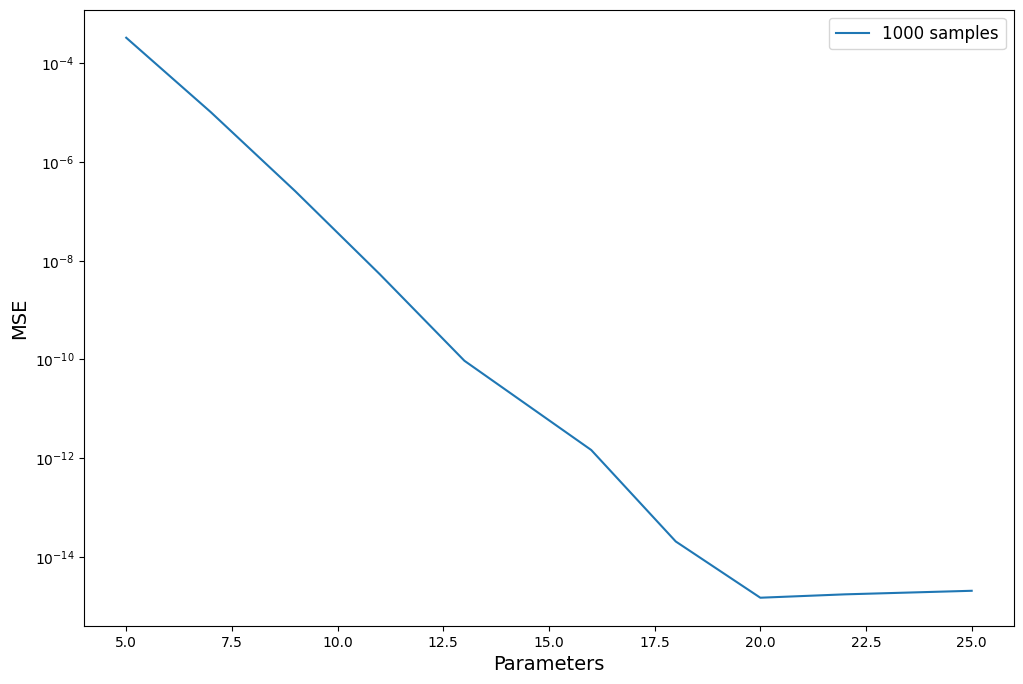

In [10]:
import numpy as np

# Initialize the error vector
MSEcheby = np.zeros([len(Para_slep), len(Nsamples), total_runs])

start_time = time.time()
total_iterations = total_runs * len(Para_slep) * len(Nsamples)
counter = 0

# test set can be the same always

for run in range(total_runs):
    # produce the matrix first, then take rectangles. It takes too long to recreate it every time.
    SamSet_ = samps(Nsamples[-1])
    y_ = funct(SamSet_)
    A_ = Matrix(SamSet_, Para_slep[-1])
    TestSet = samps(Ntest)
    Values_test = funct(TestSet)
    test_PSWF_matrix_ = np.array([[Cheby(t, i) for i in range(Para_slep[-1])] for t in TestSet])    


    for orde in range(len(Para_slep)):
        
        for k in range(len(Nsamples)):
            # Generate sample and test sets
            A = A_[:Nsamples[k], :Para_slep[orde]]
            SamSet = SamSet_[:Nsamples[k]]
            y = y_[:Nsamples[k]]
            
            test_PSWF_matrix = test_PSWF_matrix_[:, :Para_slep[orde]]
            
            #Values_test = funct(TestSet)

            # Solve the linear regression problem using lstsq (least squares)
            x, _, _, _ = np.linalg.lstsq(A.T@A, A.T@y, rcond=None)

            # Calculate the linear combination on the test set in a vectorized manner
            linear_combination_t = test_PSWF_matrix@x
            
            # Calculate the error
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest)
            
            MSEcheby[orde, k, run] = Err
            
            counter += 1
            now_time = time.time()
            print('Error: ' + str(Err) +  ', Progress: ' + format(100*counter / total_iterations, '.2f') + '%' + ', approx. ' + format((total_iterations-counter)*(now_time -  start_time)/counter, '.1f') + ' seconds remaining.')
    
    
    #Plot Error over training set sizes
    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSEcheby, axis = 2)
    results_lower = np.std(MSEcheby, axis = 2)/results_mean # 90% confidence intervals


    for i in range(len(Para_slep)):
        plt.semilogy(Nsamples, results_mean[i,:], label=f'Slepian with  {Para_slep[i]} parameters')
        plt.fill_between(Nsamples, results_mean[i,:]/(1+results_lower[i,:]), results_mean[i,:]*(1+results_lower[i,:]),  alpha=0.2)

    plt.xlabel('N Samples', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)

    plt.show()

    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSEcheby, axis = 2)
    results_lower = np.sort(MSEcheby, axis = 2)[:,:,1] # 90% confidence intervals
    results_upper = np.sort(MSEcheby, axis = 2)[:,:,-2] # 90% confidence intervals

    for i in range(len(Nsamples)):
        plt.semilogy(Para_slep, results_mean[:,i], label=f'{Nsamples[i]} samples')
        plt.fill_between(Para_slep, results_mean[:,i]/(1+results_lower[:,i]),results_mean[:,i]*(1+results_lower[:,i]),  alpha=0.2)

    plt.xlabel('Parameters', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)
    plt.savefig("errorvsparams.pdf")
    plt.show()

In [11]:
#Compute the PSWF with j and c at the value x.

def Legend(x, j):
    
    leg=legendre(j)(x)
    
    l2_norm = np.sqrt(2 / (2 * j + 1))
    
    return leg/l2_norm 


In [12]:
#We know create the matrix for the ls approximation

def Matrix(samp, ordens):

    A= np.zeros((len(samp), ordens))
    #We create the matrix for the least square
    for j in range(ordens):
        for k in range(len(samp)):
            A[k,j]= Legend(samp[k], j)
    
    return A

Error: 0.0003217679052955559, Progress: 0.50%, approx. 2117.2 seconds remaining.
Error: 1.0118999574284821e-05, Progress: 1.00%, approx. 1053.3 seconds remaining.
Error: 2.546719139847231e-07, Progress: 1.50%, approx. 698.7 seconds remaining.
Error: 5.402384283998717e-09, Progress: 2.00%, approx. 521.4 seconds remaining.
Error: 9.317089729903743e-11, Progress: 2.50%, approx. 415.0 seconds remaining.
Error: 1.4597425702287143e-12, Progress: 3.00%, approx. 344.0 seconds remaining.
Error: 2.078776533513911e-14, Progress: 3.50%, approx. 293.4 seconds remaining.
Error: 1.3657412948444658e-15, Progress: 4.00%, approx. 255.4 seconds remaining.
Error: 2.084270387771761e-15, Progress: 4.50%, approx. 225.8 seconds remaining.
Error: 1.3277636129030019e-15, Progress: 5.00%, approx. 202.2 seconds remaining.


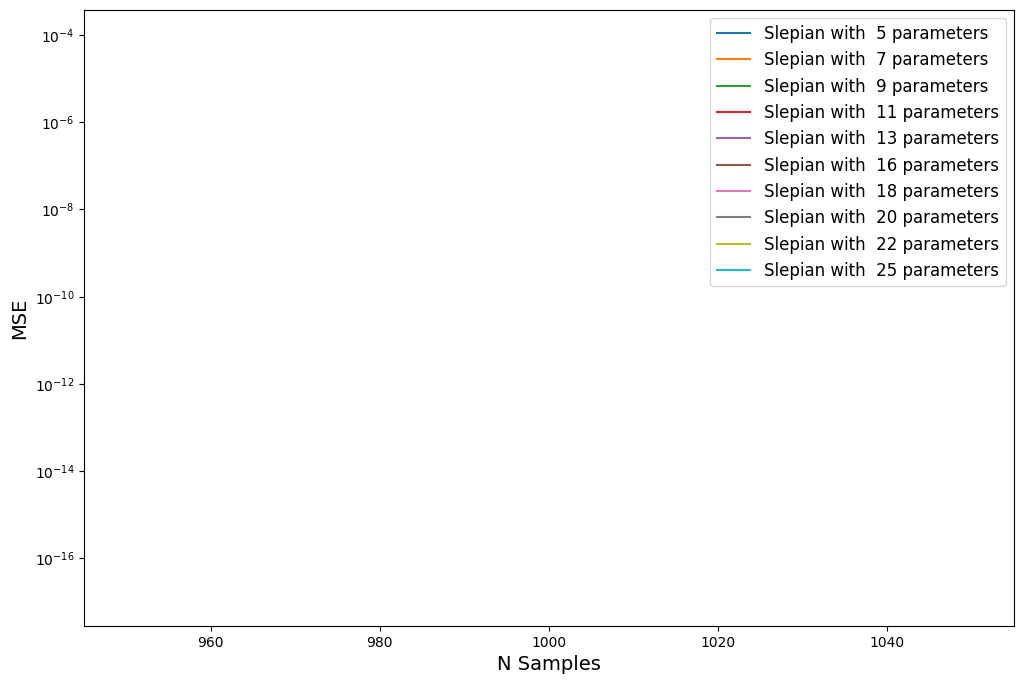

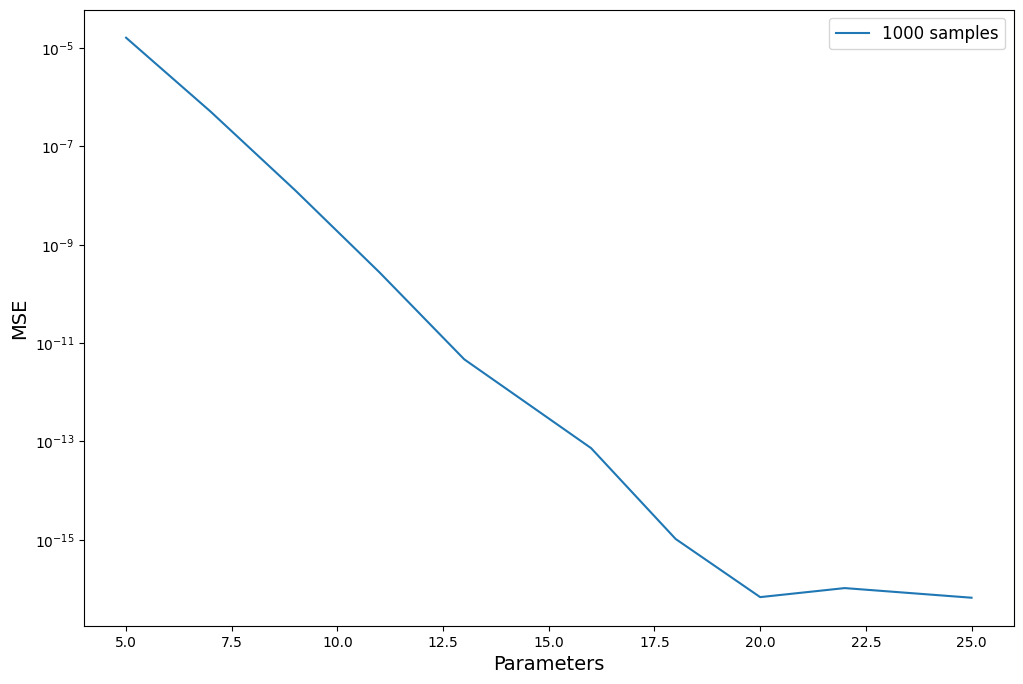

Error: 0.0003166303093949926, Progress: 5.50%, approx. 376.7 seconds remaining.
Error: 9.821712760831059e-06, Progress: 6.00%, approx. 343.5 seconds remaining.
Error: 2.5432446735668935e-07, Progress: 6.50%, approx. 315.4 seconds remaining.
Error: 5.153105566113984e-09, Progress: 7.00%, approx. 291.3 seconds remaining.
Error: 9.266312714642112e-11, Progress: 7.50%, approx. 270.4 seconds remaining.
Error: 1.4396933929228576e-12, Progress: 8.00%, approx. 252.1 seconds remaining.
Error: 2.0732793577642135e-14, Progress: 8.50%, approx. 236.0 seconds remaining.
Error: 2.235590580335016e-15, Progress: 9.00%, approx. 221.7 seconds remaining.
Error: 1.454031930787812e-15, Progress: 9.50%, approx. 208.9 seconds remaining.
Error: 1.963180725269685e-15, Progress: 10.00%, approx. 197.3 seconds remaining.


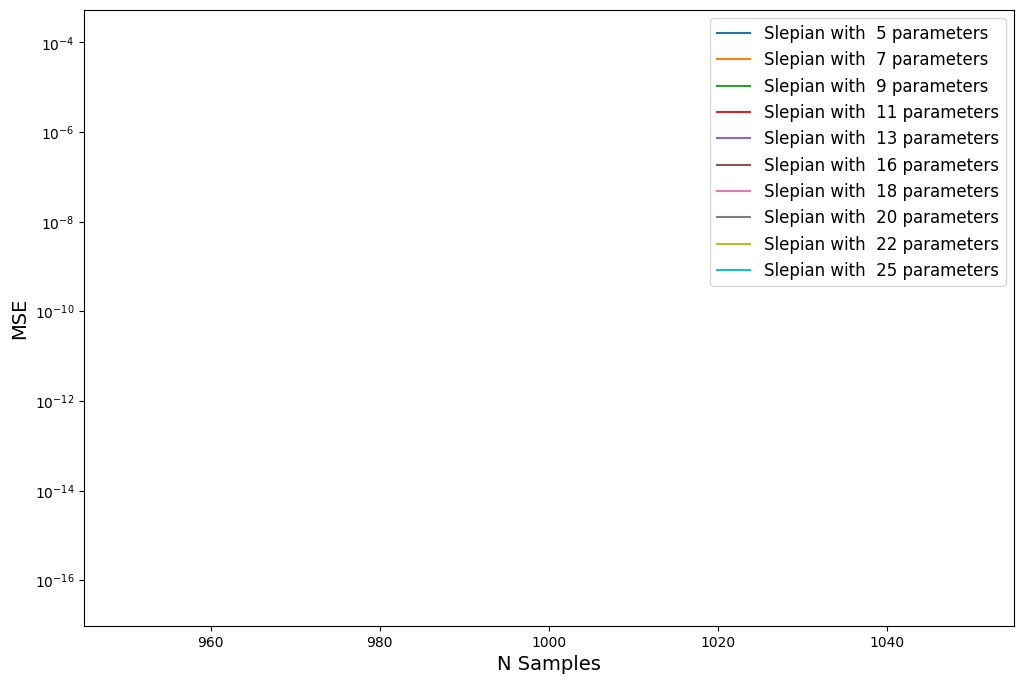

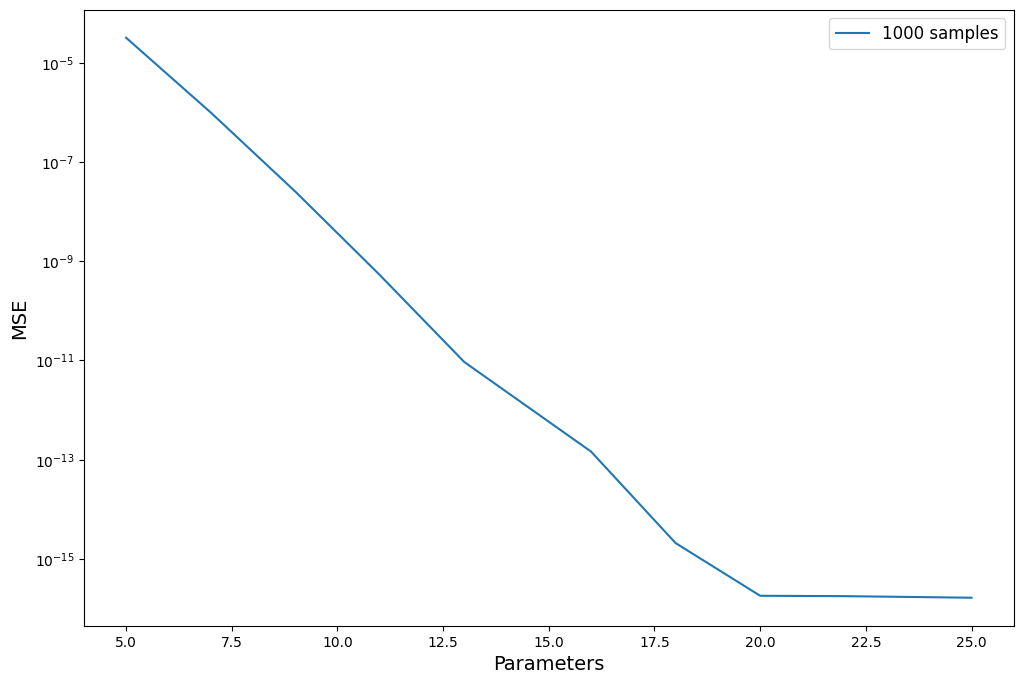

Error: 0.00031882927586763, Progress: 40.50%, approx. 148.1 seconds remaining.
Error: 1.0087471891646935e-05, Progress: 41.00%, approx. 145.0 seconds remaining.
Error: 2.480744259092412e-07, Progress: 41.50%, approx. 142.1 seconds remaining.
Error: 5.222555227169654e-09, Progress: 42.00%, approx. 139.2 seconds remaining.
Error: 9.50170055488514e-11, Progress: 42.50%, approx. 136.4 seconds remaining.
Error: 1.43902724025577e-12, Progress: 43.00%, approx. 133.6 seconds remaining.
Error: 2.021216008364869e-14, Progress: 43.50%, approx. 130.9 seconds remaining.
Error: 9.003148927271134e-16, Progress: 44.00%, approx. 128.3 seconds remaining.
Error: 1.61569303857285e-15, Progress: 44.50%, approx. 125.7 seconds remaining.
Error: 9.944462913380727e-16, Progress: 45.00%, approx. 123.2 seconds remaining.


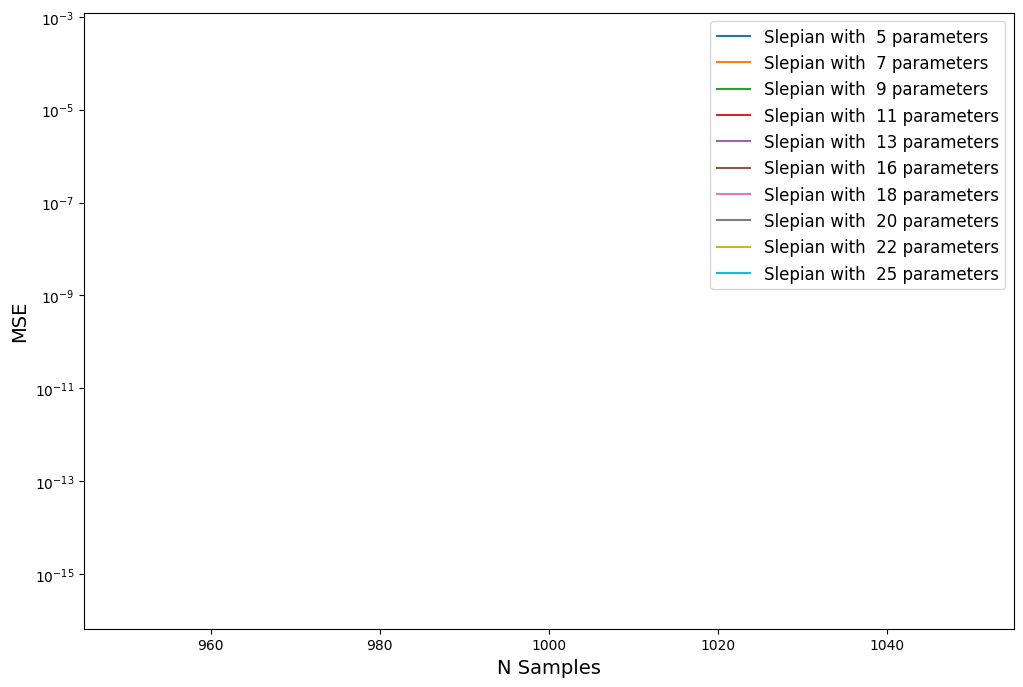

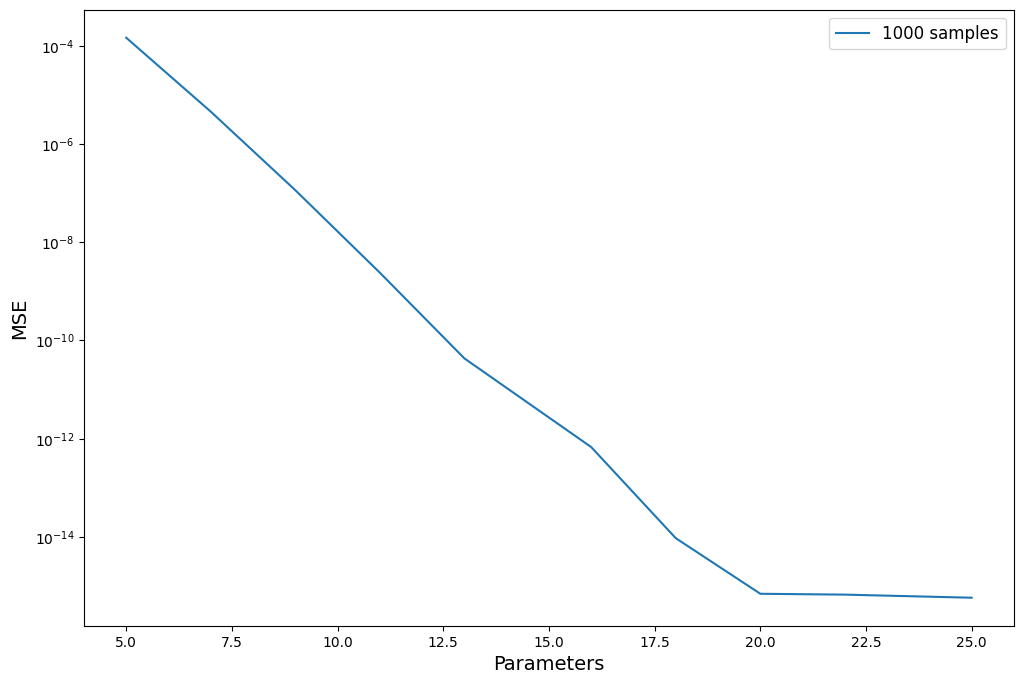

Error: 0.0003216530288674164, Progress: 45.50%, approx. 133.9 seconds remaining.
Error: 1.0226283146000458e-05, Progress: 46.00%, approx. 131.2 seconds remaining.
Error: 2.50216068677571e-07, Progress: 46.50%, approx. 128.6 seconds remaining.
Error: 5.146877712334941e-09, Progress: 47.00%, approx. 126.1 seconds remaining.
Error: 9.304426241693527e-11, Progress: 47.50%, approx. 123.6 seconds remaining.
Error: 1.4780961950782125e-12, Progress: 48.00%, approx. 121.1 seconds remaining.
Error: 2.061437375910023e-14, Progress: 48.50%, approx. 118.7 seconds remaining.
Error: 2.471948401118762e-15, Progress: 49.00%, approx. 116.4 seconds remaining.
Error: 2.350358138259954e-15, Progress: 49.50%, approx. 114.1 seconds remaining.
Error: 1.4942133639483248e-15, Progress: 50.00%, approx. 111.8 seconds remaining.


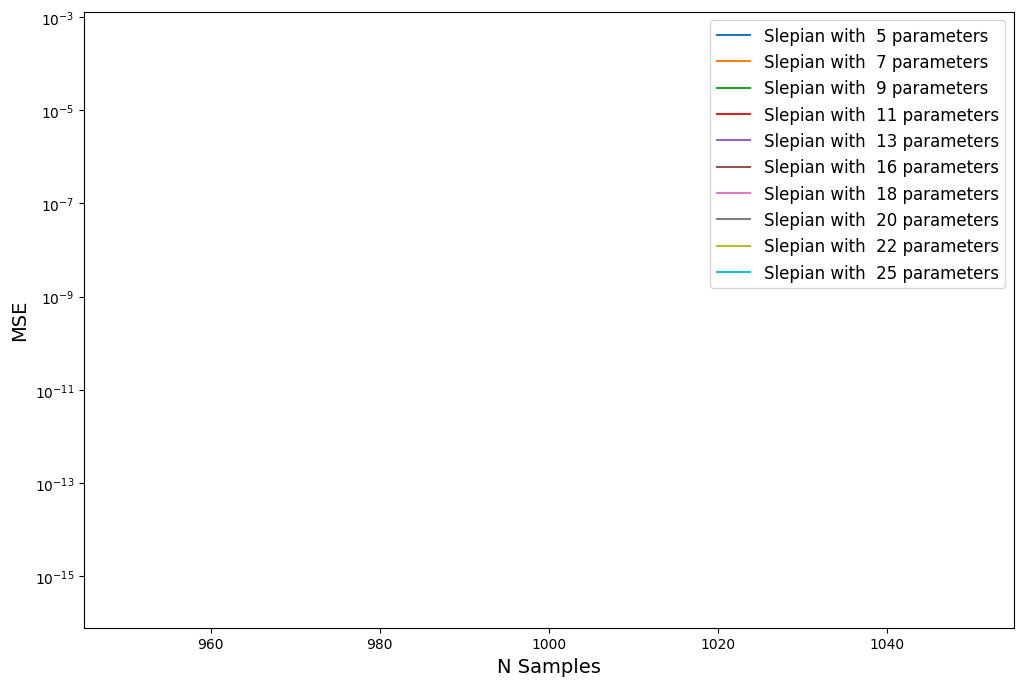

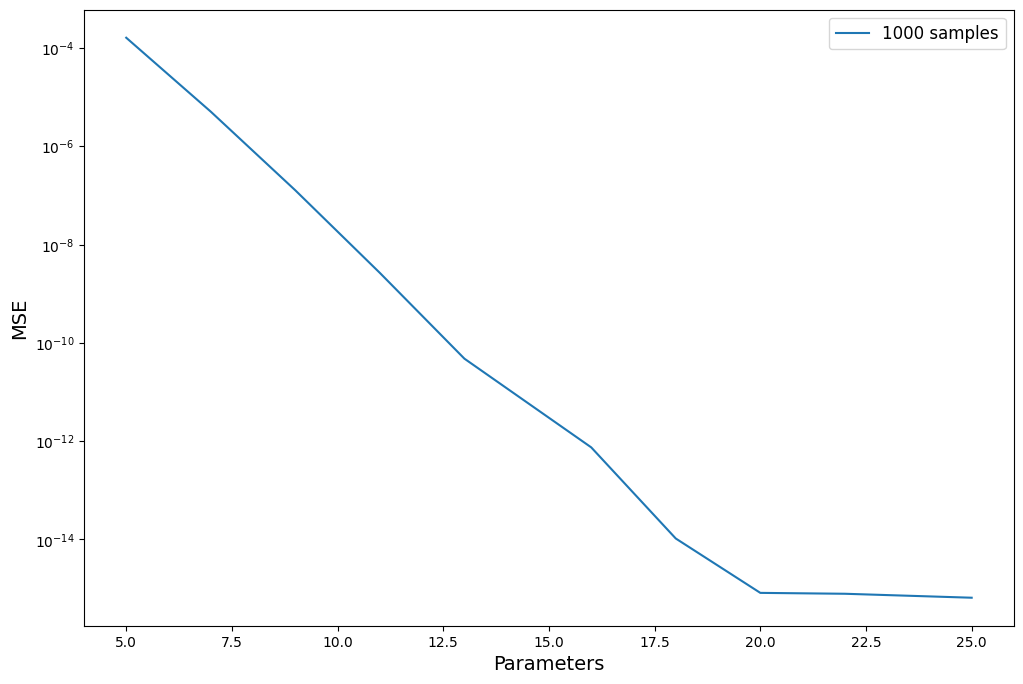

Error: 0.0003116546410273404, Progress: 50.50%, approx. 121.2 seconds remaining.
Error: 9.828197500144893e-06, Progress: 51.00%, approx. 118.8 seconds remaining.
Error: 2.4898614105643763e-07, Progress: 51.50%, approx. 116.4 seconds remaining.
Error: 5.203052897777573e-09, Progress: 52.00%, approx. 114.1 seconds remaining.
Error: 9.449948579472979e-11, Progress: 52.50%, approx. 111.9 seconds remaining.
Error: 1.4594184353242056e-12, Progress: 53.00%, approx. 109.6 seconds remaining.
Error: 1.974015876002663e-14, Progress: 53.50%, approx. 107.5 seconds remaining.
Error: 1.081228414204236e-15, Progress: 54.00%, approx. 105.3 seconds remaining.
Error: 1.5580309980334595e-15, Progress: 54.50%, approx. 103.2 seconds remaining.
Error: 3.358078719211999e-15, Progress: 55.00%, approx. 101.2 seconds remaining.


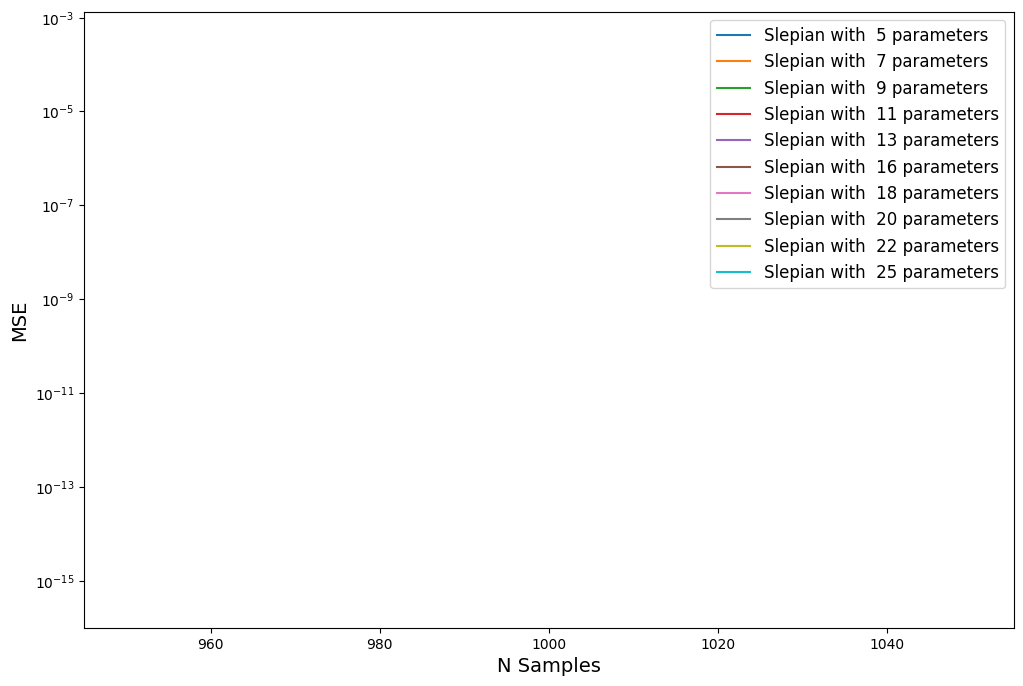

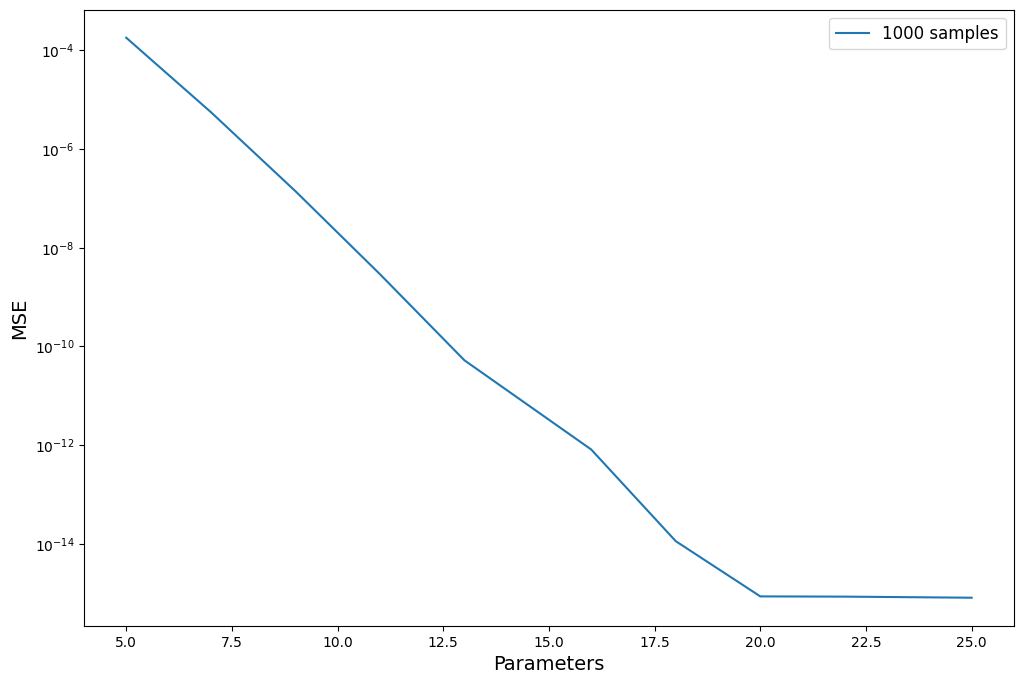

Error: 0.0003165177431173828, Progress: 55.50%, approx. 111.0 seconds remaining.
Error: 9.79836703653588e-06, Progress: 56.00%, approx. 108.8 seconds remaining.
Error: 2.47650444551531e-07, Progress: 56.50%, approx. 106.6 seconds remaining.
Error: 5.151515324544399e-09, Progress: 57.00%, approx. 104.4 seconds remaining.
Error: 9.283534248067657e-11, Progress: 57.50%, approx. 102.3 seconds remaining.
Error: 1.4832040710076153e-12, Progress: 58.00%, approx. 100.2 seconds remaining.
Error: 2.0376263772399986e-14, Progress: 58.50%, approx. 98.2 seconds remaining.
Error: 1.4252902919799145e-15, Progress: 59.00%, approx. 96.2 seconds remaining.
Error: 1.3425530011202014e-15, Progress: 59.50%, approx. 94.2 seconds remaining.
Error: 1.71697704721579e-15, Progress: 60.00%, approx. 92.3 seconds remaining.


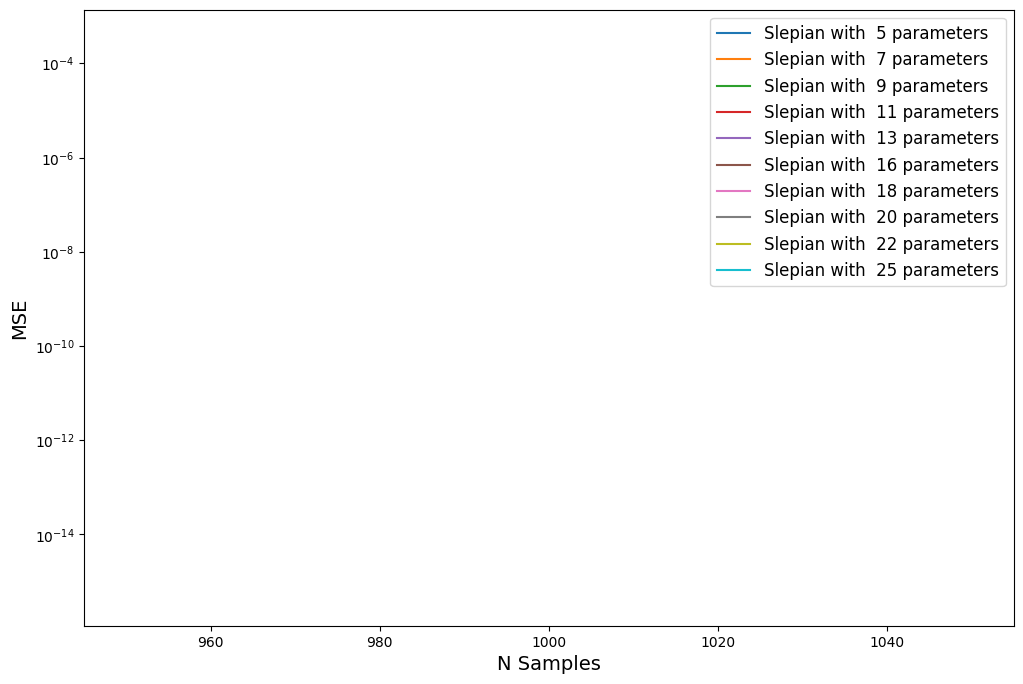

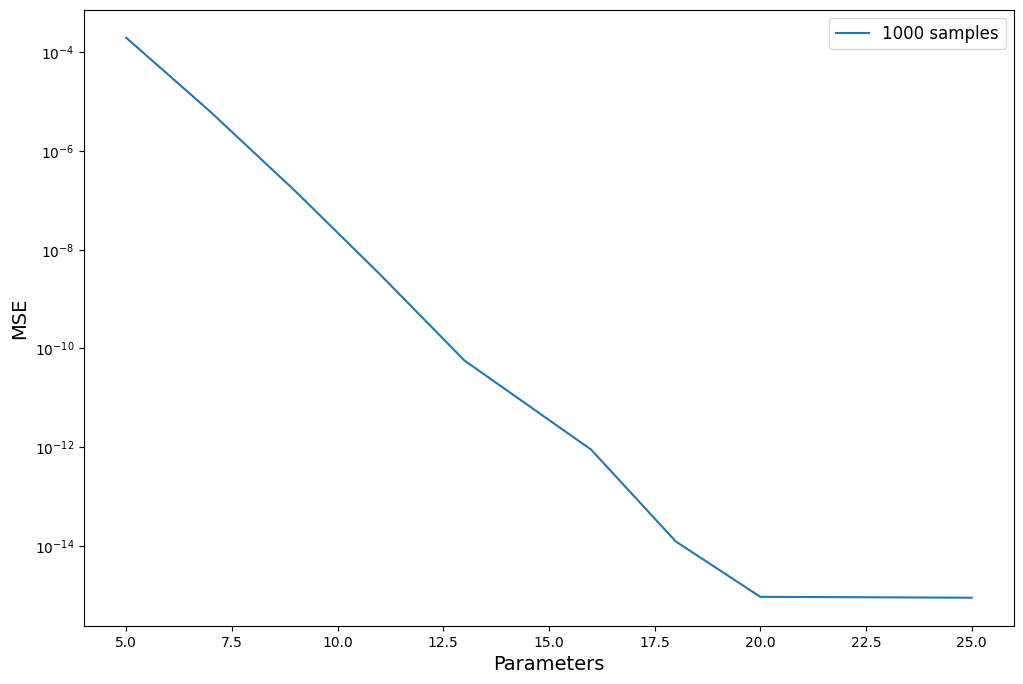

Error: 0.0003062880835223295, Progress: 60.50%, approx. 99.5 seconds remaining.
Error: 9.744637118213674e-06, Progress: 61.00%, approx. 97.5 seconds remaining.
Error: 2.486682847860995e-07, Progress: 61.50%, approx. 95.4 seconds remaining.
Error: 5.014033511706727e-09, Progress: 62.00%, approx. 93.4 seconds remaining.
Error: 9.263828616368531e-11, Progress: 62.50%, approx. 91.5 seconds remaining.
Error: 1.4293988287832681e-12, Progress: 63.00%, approx. 89.5 seconds remaining.
Error: 2.020494391428096e-14, Progress: 63.50%, approx. 87.6 seconds remaining.
Error: 2.5183127955249317e-15, Progress: 64.00%, approx. 85.7 seconds remaining.
Error: 1.911744732433088e-15, Progress: 64.50%, approx. 83.9 seconds remaining.
Error: 2.1315067731780674e-15, Progress: 65.00%, approx. 82.1 seconds remaining.


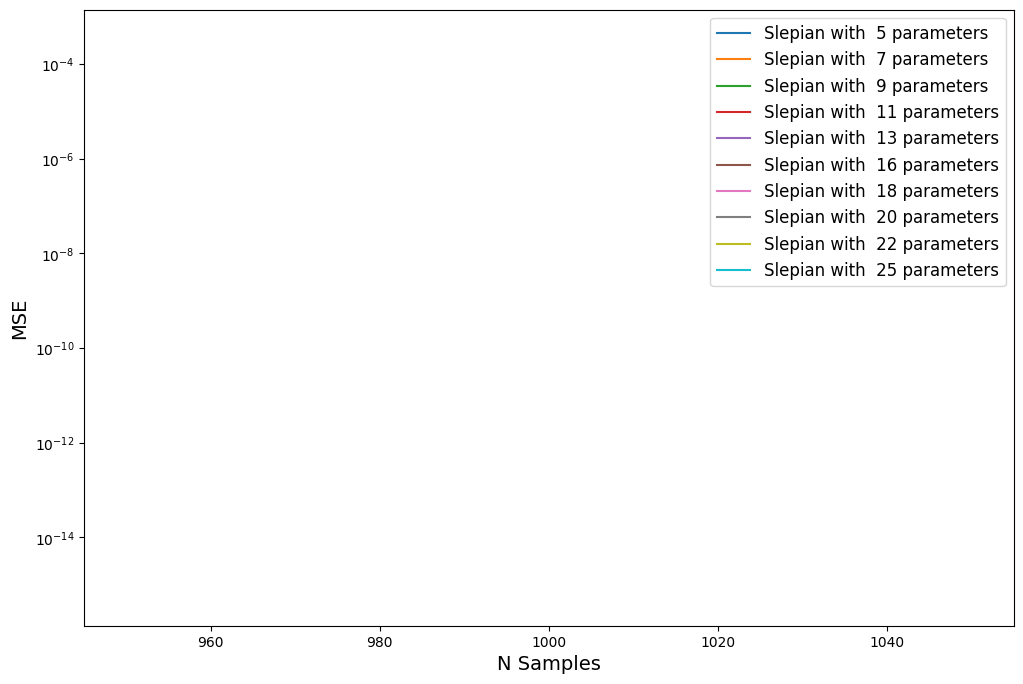

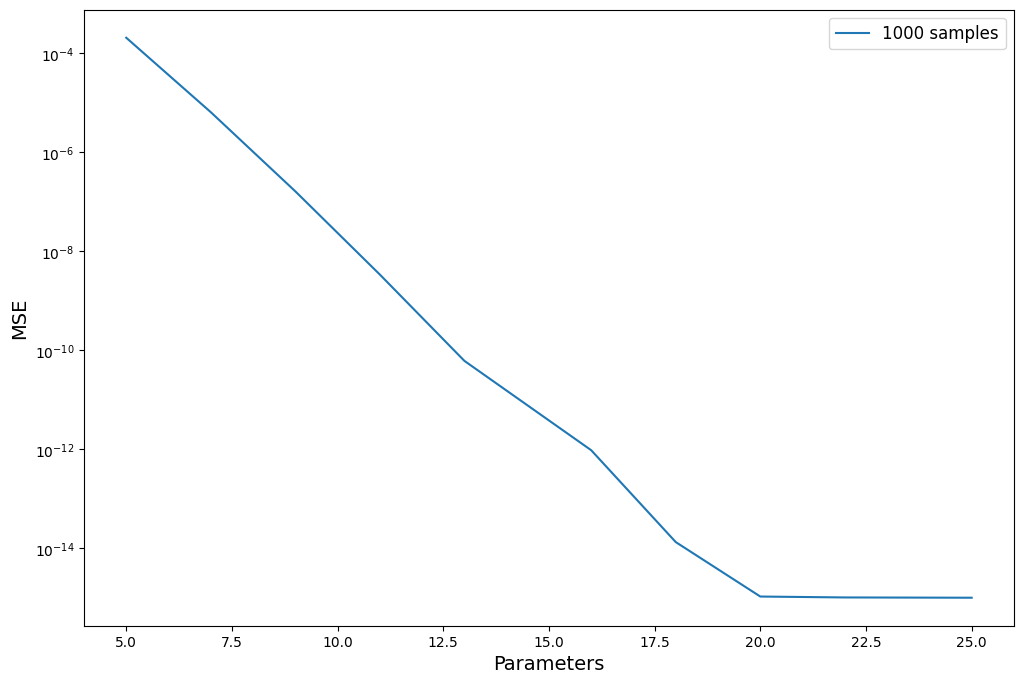

Error: 0.0003212394888404908, Progress: 65.50%, approx. 87.4 seconds remaining.
Error: 9.807689447388743e-06, Progress: 66.00%, approx. 85.4 seconds remaining.
Error: 2.502291279074249e-07, Progress: 66.50%, approx. 83.6 seconds remaining.
Error: 5.27922093635949e-09, Progress: 67.00%, approx. 81.7 seconds remaining.
Error: 9.451367083662003e-11, Progress: 67.50%, approx. 79.9 seconds remaining.
Error: 1.5586794450552121e-12, Progress: 68.00%, approx. 78.1 seconds remaining.
Error: 2.283213451006731e-14, Progress: 68.50%, approx. 76.3 seconds remaining.
Error: 2.4540525038464748e-15, Progress: 69.00%, approx. 74.5 seconds remaining.
Error: 3.841902674485518e-15, Progress: 69.50%, approx. 72.8 seconds remaining.
Error: 1.3723587116203378e-15, Progress: 70.00%, approx. 71.1 seconds remaining.


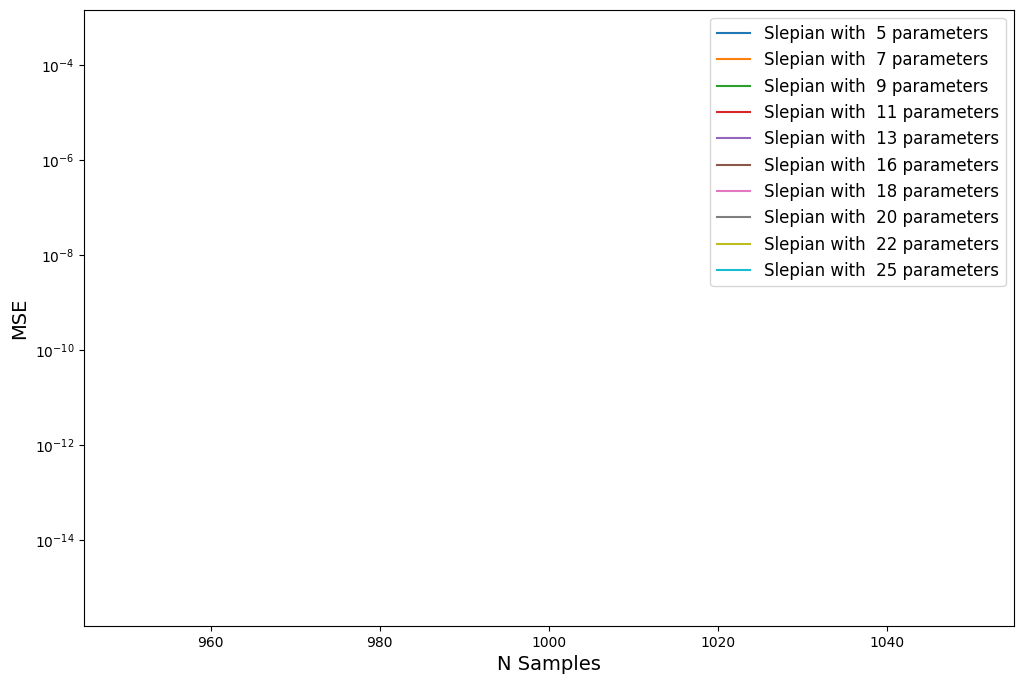

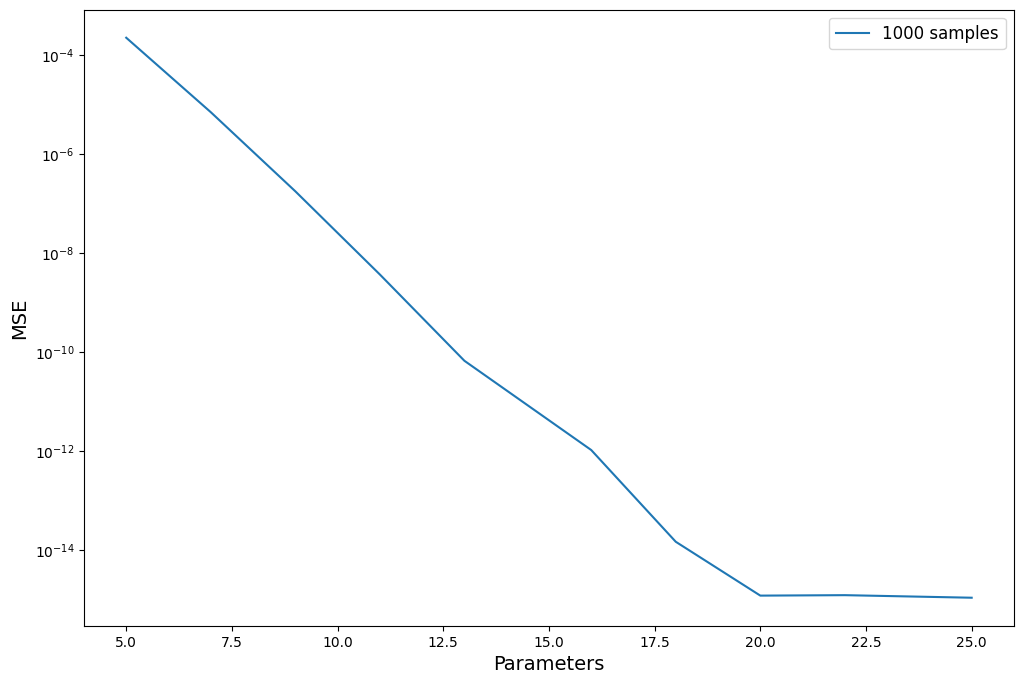

Error: 0.0003110913282216684, Progress: 70.50%, approx. 75.2 seconds remaining.
Error: 9.835998623743463e-06, Progress: 71.00%, approx. 73.4 seconds remaining.
Error: 2.459460980024306e-07, Progress: 71.50%, approx. 71.6 seconds remaining.
Error: 5.220225086937249e-09, Progress: 72.00%, approx. 69.9 seconds remaining.
Error: 9.334492988187309e-11, Progress: 72.50%, approx. 68.1 seconds remaining.
Error: 1.5328642835115173e-12, Progress: 73.00%, approx. 66.4 seconds remaining.
Error: 2.2079937044449344e-14, Progress: 73.50%, approx. 64.8 seconds remaining.
Error: 1.022502748335676e-15, Progress: 74.00%, approx. 63.1 seconds remaining.
Error: 2.4198736444627508e-15, Progress: 74.50%, approx. 61.5 seconds remaining.
Error: 2.9326389361626876e-15, Progress: 75.00%, approx. 59.9 seconds remaining.


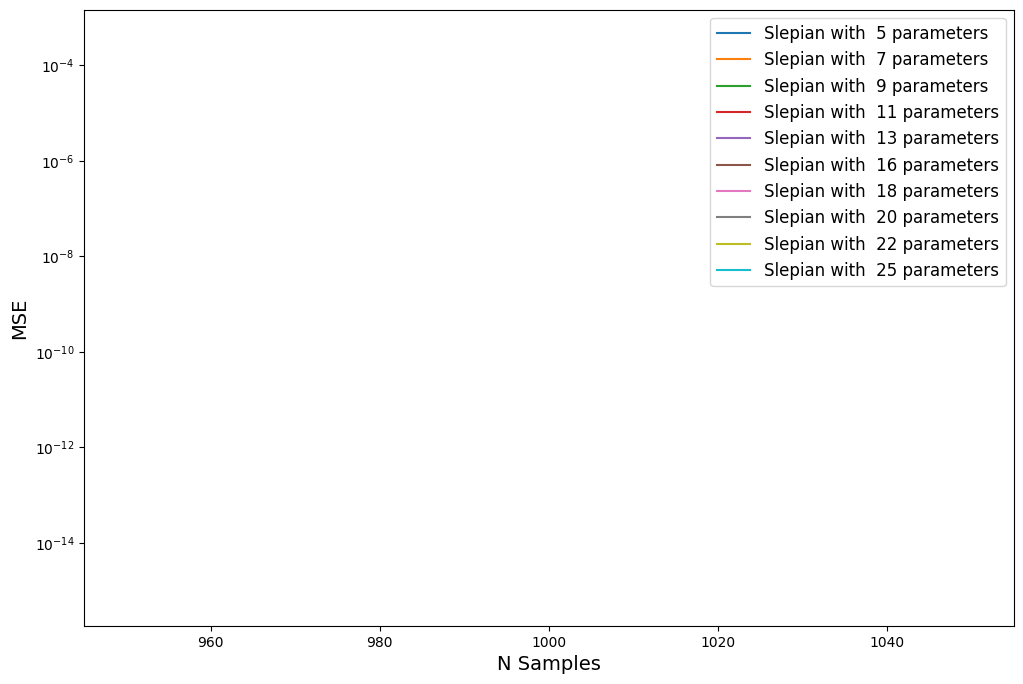

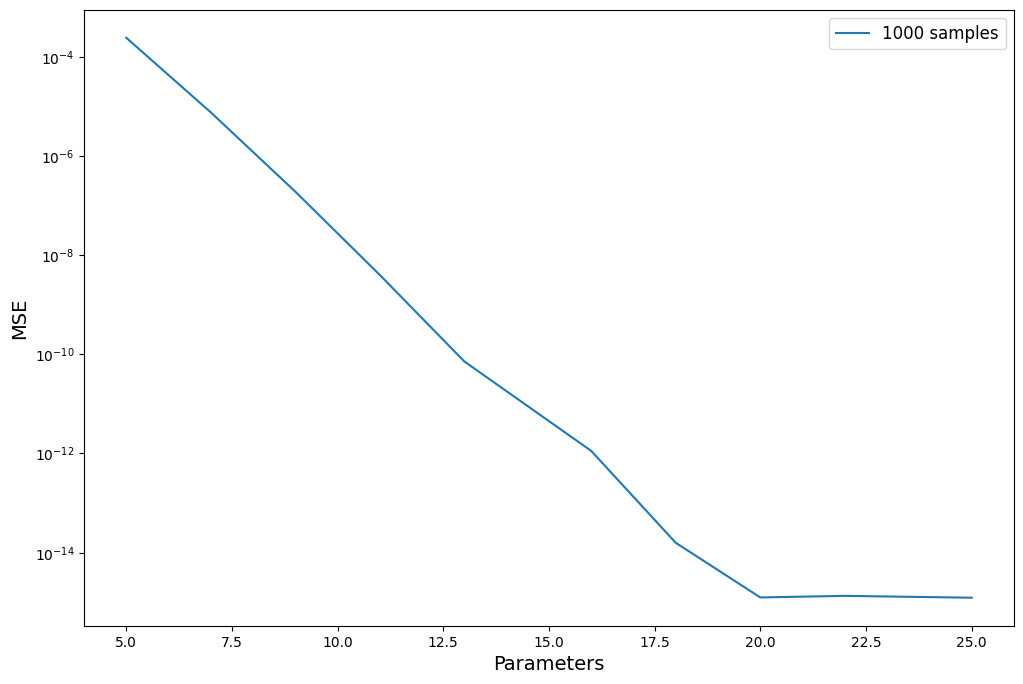

Error: 0.00030446640068965624, Progress: 75.50%, approx. 62.7 seconds remaining.
Error: 9.611673885305254e-06, Progress: 76.00%, approx. 61.1 seconds remaining.
Error: 2.3959139288050076e-07, Progress: 76.50%, approx. 59.4 seconds remaining.
Error: 4.918739755063408e-09, Progress: 77.00%, approx. 57.8 seconds remaining.
Error: 9.050080937025639e-11, Progress: 77.50%, approx. 56.1 seconds remaining.
Error: 1.3611160382060533e-12, Progress: 78.00%, approx. 54.5 seconds remaining.
Error: 2.000084419713692e-14, Progress: 78.50%, approx. 53.0 seconds remaining.
Error: 9.47677945660251e-16, Progress: 79.00%, approx. 51.4 seconds remaining.
Error: 1.1122251718745369e-15, Progress: 79.50%, approx. 49.9 seconds remaining.
Error: 1.3377289103335629e-15, Progress: 80.00%, approx. 48.3 seconds remaining.


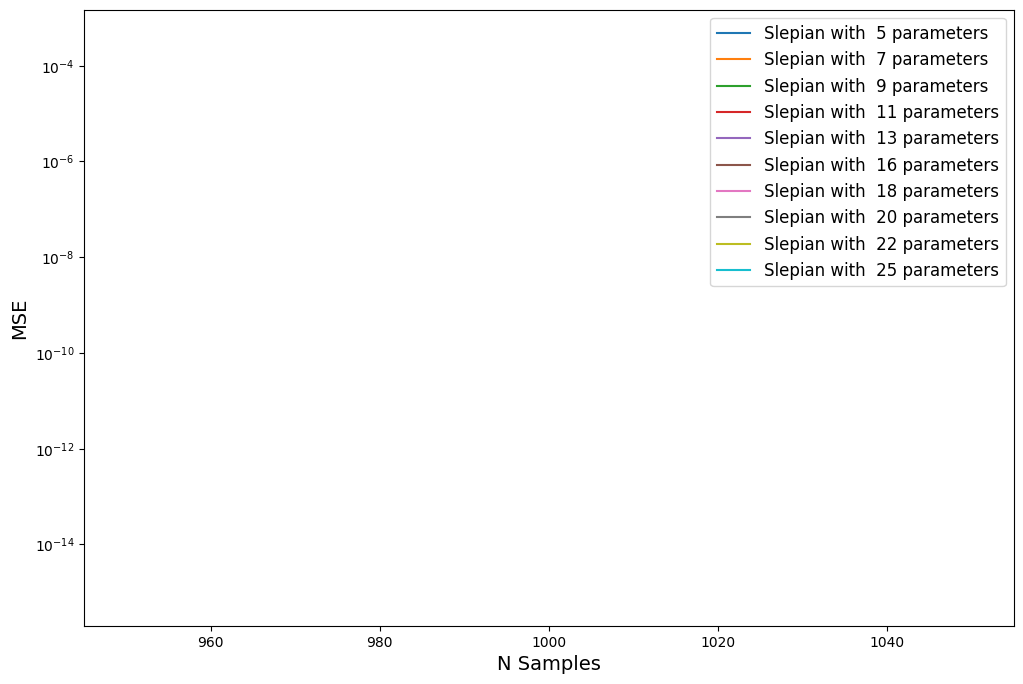

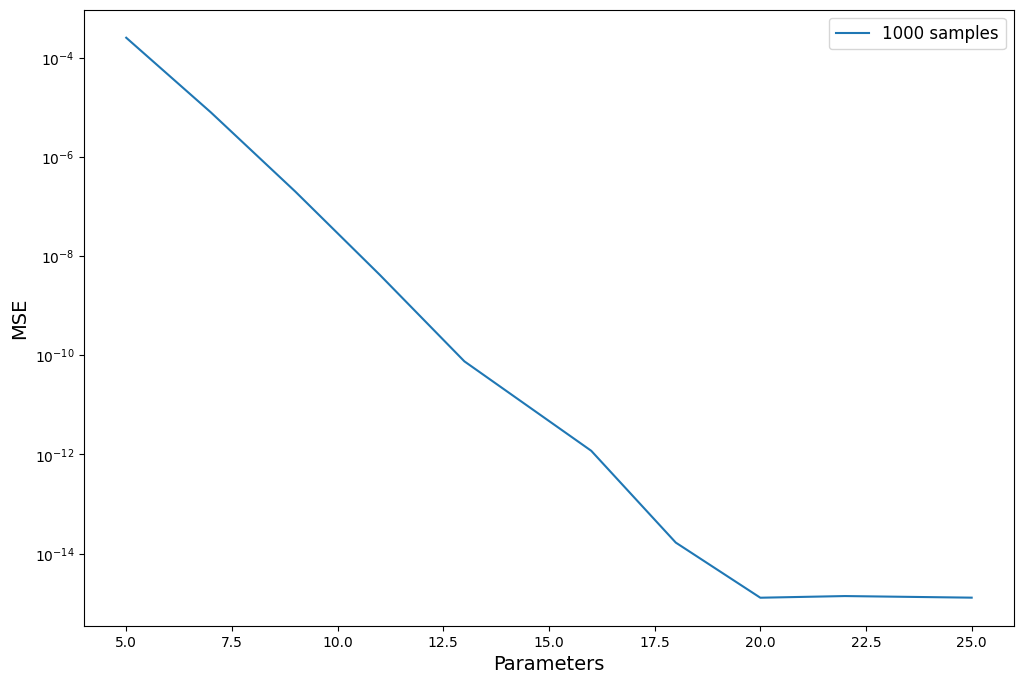

Error: 0.0003266627980696116, Progress: 80.50%, approx. 50.2 seconds remaining.
Error: 1.0010261666079415e-05, Progress: 81.00%, approx. 48.6 seconds remaining.
Error: 2.54243242462805e-07, Progress: 81.50%, approx. 47.0 seconds remaining.
Error: 5.235889219073665e-09, Progress: 82.00%, approx. 45.5 seconds remaining.
Error: 9.205500043845683e-11, Progress: 82.50%, approx. 43.9 seconds remaining.
Error: 1.4905594855388345e-12, Progress: 83.00%, approx. 42.4 seconds remaining.
Error: 2.0685407728752546e-14, Progress: 83.50%, approx. 40.9 seconds remaining.
Error: 1.2982158318822643e-15, Progress: 84.00%, approx. 39.5 seconds remaining.
Error: 9.05971920083164e-16, Progress: 84.50%, approx. 38.0 seconds remaining.
Error: 1.060341456874269e-15, Progress: 85.00%, approx. 36.6 seconds remaining.


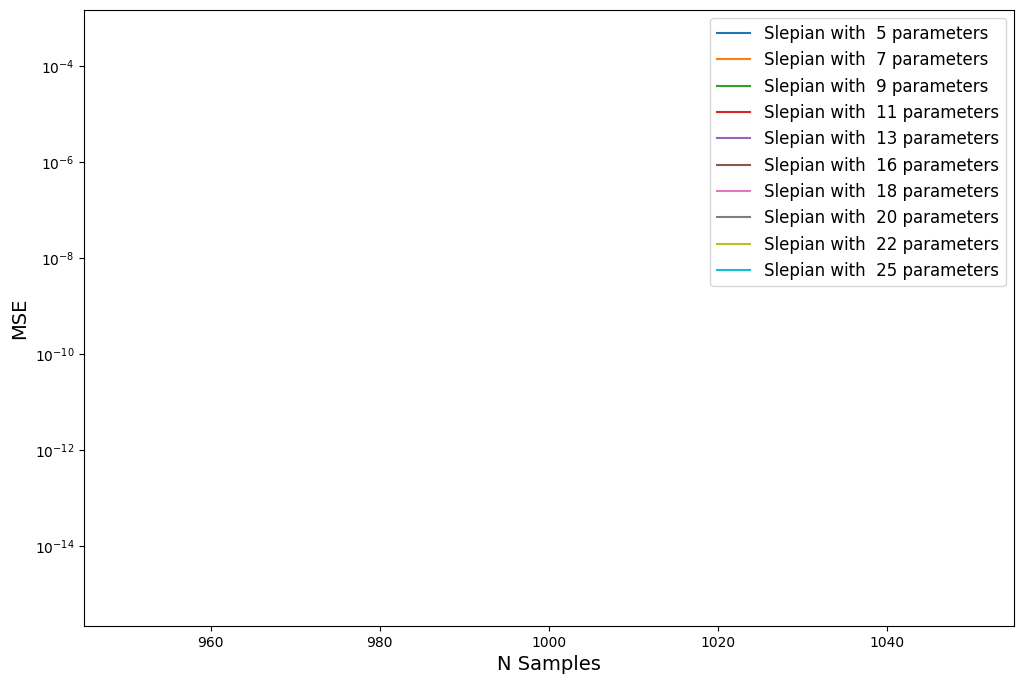

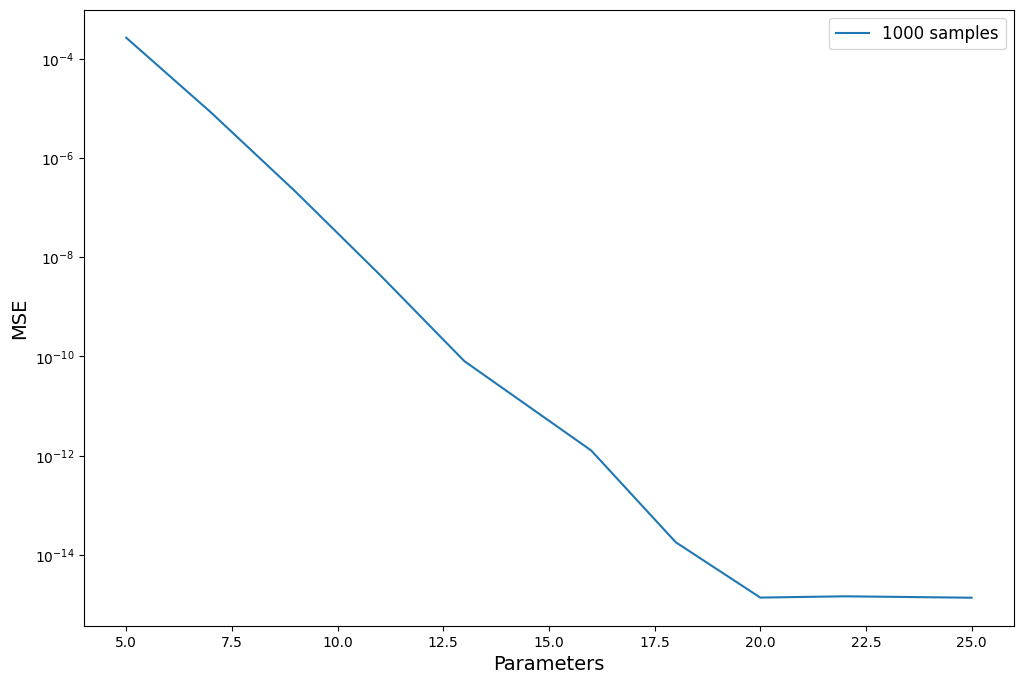

Error: 0.0003167273622219105, Progress: 85.50%, approx. 37.5 seconds remaining.
Error: 9.909896236909475e-06, Progress: 86.00%, approx. 36.0 seconds remaining.
Error: 2.491807720163506e-07, Progress: 86.50%, approx. 34.5 seconds remaining.
Error: 5.19596769585481e-09, Progress: 87.00%, approx. 33.0 seconds remaining.
Error: 9.254725414007284e-11, Progress: 87.50%, approx. 31.6 seconds remaining.
Error: 1.4402709856653902e-12, Progress: 88.00%, approx. 30.1 seconds remaining.
Error: 1.968057662151998e-14, Progress: 88.50%, approx. 28.7 seconds remaining.
Error: 1.274447056587086e-15, Progress: 89.00%, approx. 27.3 seconds remaining.
Error: 1.0084101400900632e-15, Progress: 89.50%, approx. 25.9 seconds remaining.
Error: 7.863561636615285e-16, Progress: 90.00%, approx. 24.6 seconds remaining.


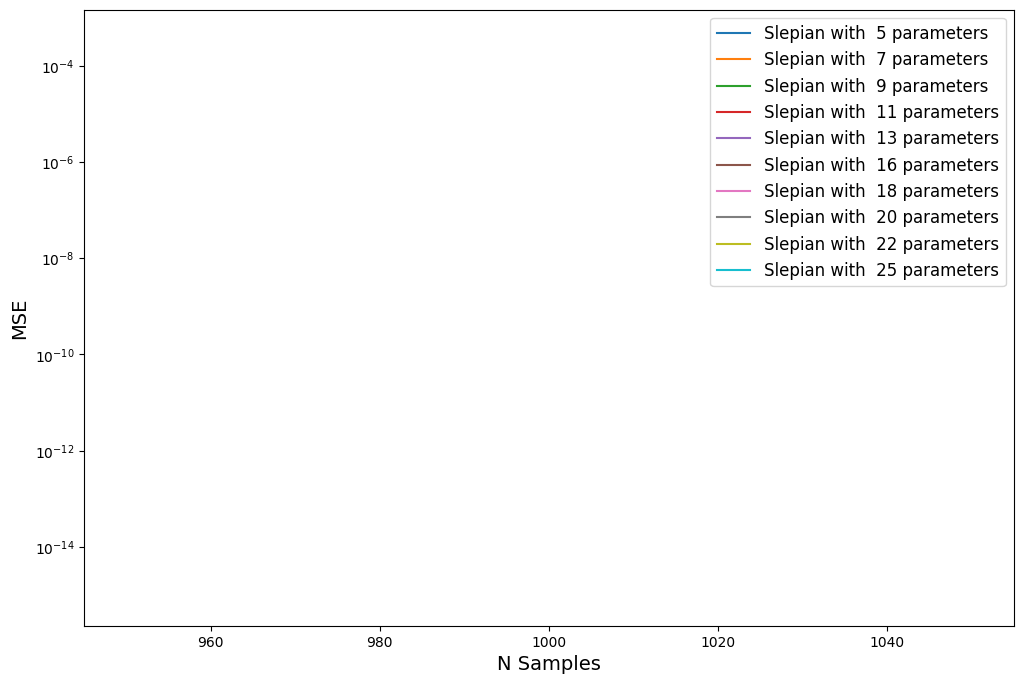

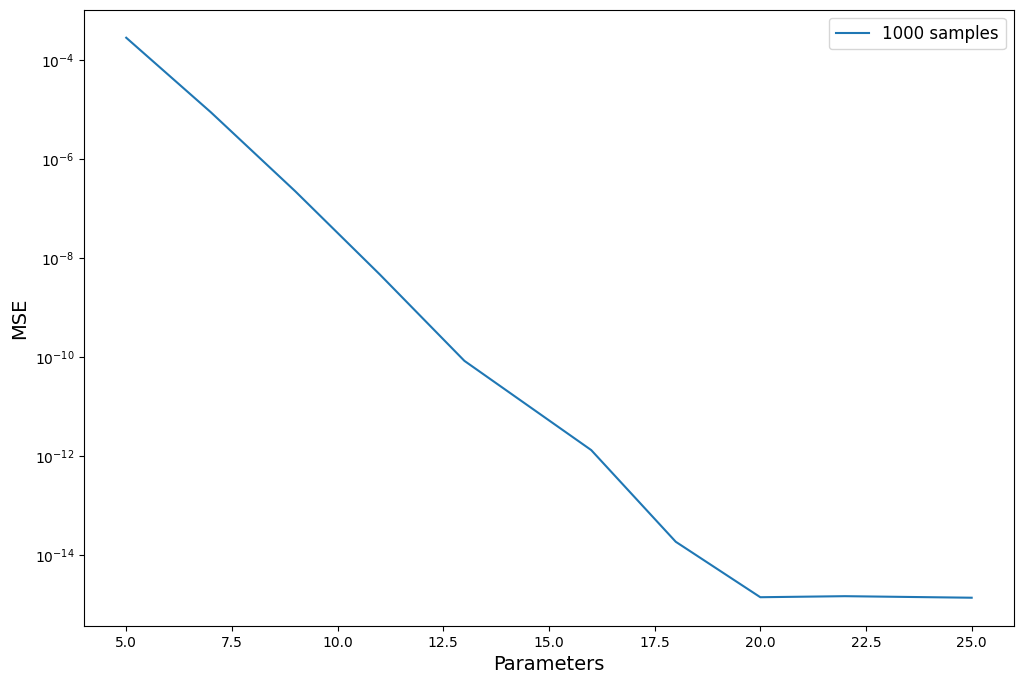

Error: 0.00032677880659206, Progress: 90.50%, approx. 24.6 seconds remaining.
Error: 1.0289527482747867e-05, Progress: 91.00%, approx. 23.2 seconds remaining.
Error: 2.557391417595238e-07, Progress: 91.50%, approx. 21.8 seconds remaining.
Error: 5.306624961198967e-09, Progress: 92.00%, approx. 20.4 seconds remaining.
Error: 9.650536133395909e-11, Progress: 92.50%, approx. 19.0 seconds remaining.
Error: 1.4780095138214828e-12, Progress: 93.00%, approx. 17.7 seconds remaining.
Error: 2.0464823859369118e-14, Progress: 93.50%, approx. 16.3 seconds remaining.
Error: 1.1331021256064138e-15, Progress: 94.00%, approx. 15.0 seconds remaining.
Error: 9.416694150425814e-16, Progress: 94.50%, approx. 13.7 seconds remaining.
Error: 1.8209620697276094e-15, Progress: 95.00%, approx. 12.4 seconds remaining.


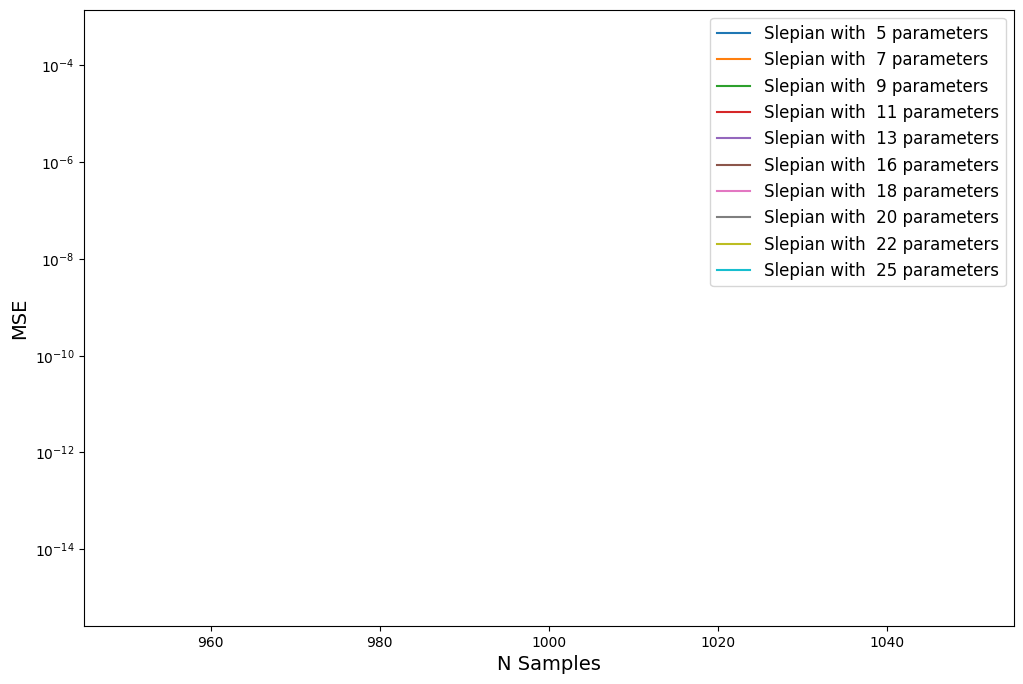

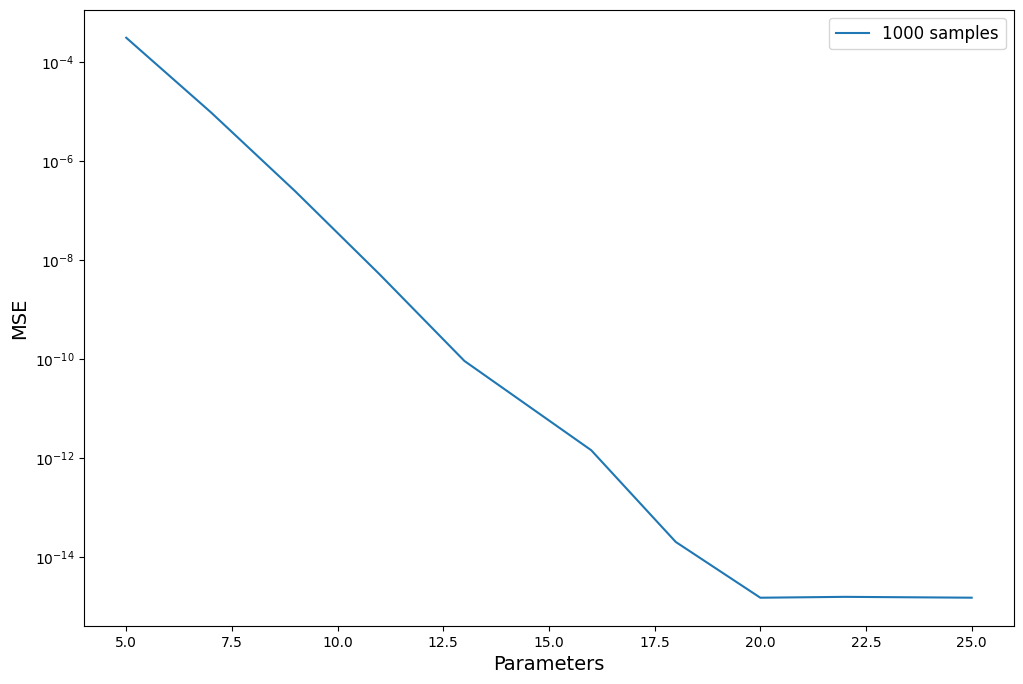

Error: 0.00031525903743620564, Progress: 95.50%, approx. 11.7 seconds remaining.
Error: 9.919038388671524e-06, Progress: 96.00%, approx. 10.4 seconds remaining.
Error: 2.489118609567735e-07, Progress: 96.50%, approx. 9.0 seconds remaining.
Error: 5.513083247405864e-09, Progress: 97.00%, approx. 7.7 seconds remaining.
Error: 1.0315144405678695e-10, Progress: 97.50%, approx. 6.4 seconds remaining.
Error: 1.674026341956834e-12, Progress: 98.00%, approx. 5.1 seconds remaining.
Error: 2.193276761651453e-14, Progress: 98.50%, approx. 3.8 seconds remaining.
Error: 9.657089765258523e-16, Progress: 99.00%, approx. 2.5 seconds remaining.
Error: 1.6913255764797049e-15, Progress: 99.50%, approx. 1.2 seconds remaining.
Error: 1.719867697728805e-15, Progress: 100.00%, approx. 0.0 seconds remaining.


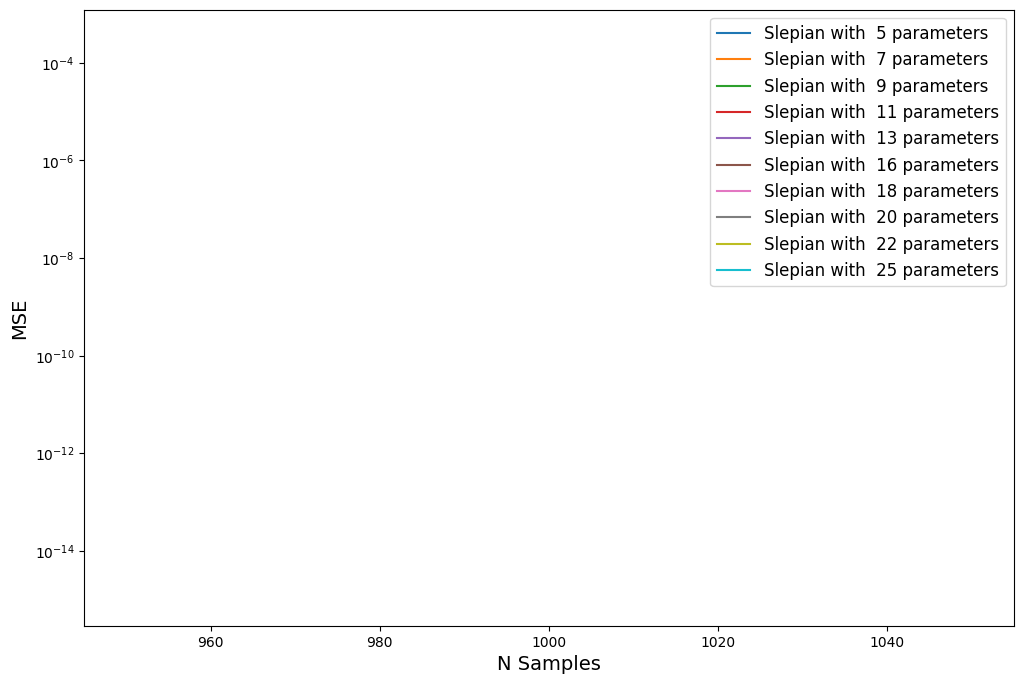

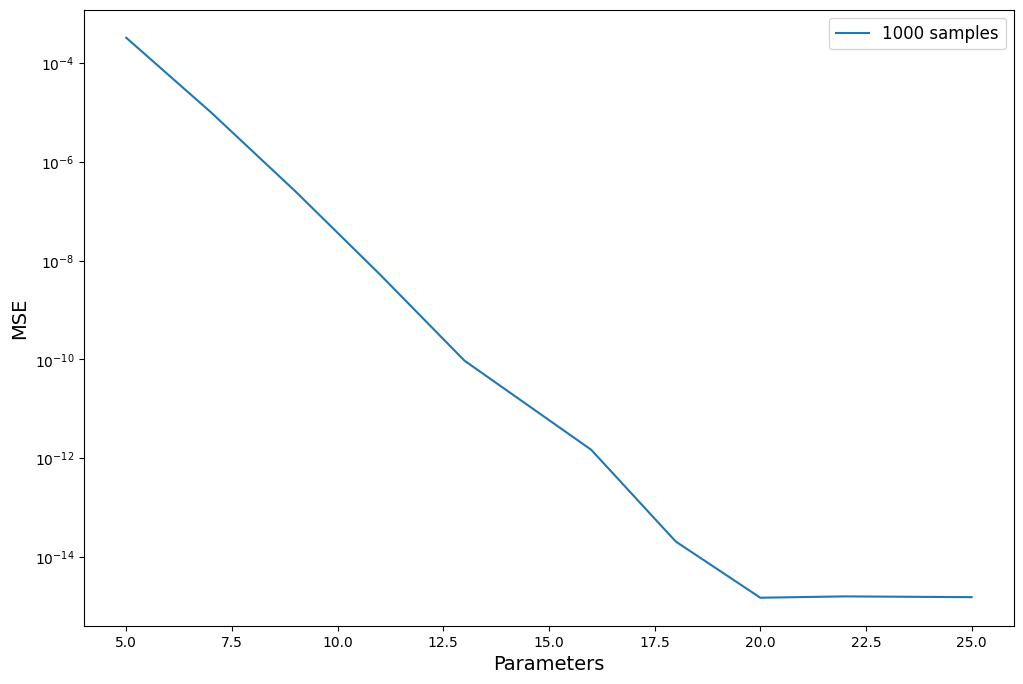

In [13]:
import numpy as np

# Initialize the error vector
MSE_leg = np.zeros([len(Para_slep), len(Nsamples), total_runs])

start_time = time.time()
total_iterations = total_runs * len(Para_slep) * len(Nsamples)
counter = 0

# test set can be the same always

for run in range(total_runs):
    # produce the matrix first, then take rectangles. It takes too long to recreate it every time.
    SamSet_ = samps(Nsamples[-1])
    y_ = funct(SamSet_)
    A_ = Matrix(SamSet_, Para_slep[-1])
    TestSet = samps(Ntest)
    Values_test = funct(TestSet)
    test_PSWF_matrix_ = np.array([[Legend(t, i) for i in range(Para_slep[-1])] for t in TestSet])    


    for orde in range(len(Para_slep)):
        
        for k in range(len(Nsamples)):
            # Generate sample and test sets
            A = A_[:Nsamples[k], :Para_slep[orde]]
            SamSet = SamSet_[:Nsamples[k]]
            y = y_[:Nsamples[k]]
            
            test_PSWF_matrix = test_PSWF_matrix_[:, :Para_slep[orde]]
            
            #Values_test = funct(TestSet)

            # Solve the linear regression problem using lstsq (least squares)
            x, _, _, _ = np.linalg.lstsq(A.T@A, A.T@y, rcond=None)

            # Calculate the linear combination on the test set in a vectorized manner
            linear_combination_t = test_PSWF_matrix@x
            
            # Calculate the error
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest)
            
            MSE_leg[orde, k, run] = Err
            
            counter += 1
            now_time = time.time()
            print('Error: ' + str(Err) +  ', Progress: ' + format(100*counter / total_iterations, '.2f') + '%' + ', approx. ' + format((total_iterations-counter)*(now_time -  start_time)/counter, '.1f') + ' seconds remaining.')
    
    
    #Plot Error over training set sizes
    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSE_leg, axis = 2)
    results_lower = np.std(MSE_leg, axis = 2)/results_mean # 90% confidence intervals


    for i in range(len(Para_slep)):
        plt.semilogy(Nsamples, results_mean[i,:], label=f'Slepian with  {Para_slep[i]} parameters')
        plt.fill_between(Nsamples, results_mean[i,:]/(1+results_lower[i,:]), results_mean[i,:]*(1+results_lower[i,:]),  alpha=0.2)

    plt.xlabel('N Samples', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)

    plt.show()

    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSE_leg, axis = 2)
    results_lower = np.sort(MSE_leg, axis = 2)[:,:,1] # 90% confidence intervals
    results_upper = np.sort(MSE_leg, axis = 2)[:,:,-2] # 90% confidence intervals

    for i in range(len(Nsamples)):
        plt.semilogy(Para_slep, results_mean[:,i], label=f'{Nsamples[i]} samples')
        plt.fill_between(Para_slep, results_mean[:,i]/(1+results_lower[:,i]),results_mean[:,i]*(1+results_lower[:,i]),  alpha=0.2)

    plt.xlabel('Parameters', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)
    plt.savefig("errorvsparams.pdf")
    plt.show()

In [14]:
#Returns the Slepian basis function

def NorSlep(j, c):
    b = 0 # Alpha parameter for the PSAF
    theta = np.linspace(-1, 1, 200)
    
    psaf_values = pro_ang1(b, j, c, theta)
    psaf_values = psaf_values[0] 
    
    psaf_values = psaf_values[1:199]
    l2_norm = np.linalg.norm(psaf_values)/np.sqrt(len(theta)-1)
    
    
    return l2_norm

norms_ = np.zeros([Para_slep[-1]])
for k in range(Para_slep[-1]):
    norms_[k] = NorSlep(k, 4)

In [15]:
#Compute the PSWF with j and c at the value x.

def PSWF(x, j, c):
    
    b = 0 # Alpha parameter for the PSAF
    
    # Calculate the PSAF values for the two modes
    psaf_values = pro_ang1(b, j, c, x)
    psaf_values = psaf_values[0] 
    
    
  
    l2_norm = norms_[j]
    
    return psaf_values/l2_norm 

In [16]:
#We know create the matrix for the ls approximation

def Matrix(samp, ordens):

    A= np.zeros((len(samp), ordens))
    #We create the matrix for the least square
    for j in range(ordens):
        for k in range(len(samp)):
            A[k,j]= PSWF(samp[k], j, 4)
    
    return A

Error: 0.00043591088574038145, Progress: 0.50%, approx. 1061.3 seconds remaining.
Error: 3.5644336863230987e-06, Progress: 1.00%, approx. 528.0 seconds remaining.
Error: 1.1853516571210432e-08, Progress: 1.50%, approx. 350.3 seconds remaining.
Error: 7.196873488932224e-11, Progress: 2.00%, approx. 261.4 seconds remaining.
Error: 7.827259150180665e-13, Progress: 2.50%, approx. 208.0 seconds remaining.
Error: 1.4433631621736542e-14, Progress: 3.00%, approx. 172.5 seconds remaining.
Error: 6.994581278795438e-16, Progress: 3.50%, approx. 147.1 seconds remaining.
Error: 1.1923867645159388e-15, Progress: 4.00%, approx. 128.0 seconds remaining.
Error: 1.1697136129409064e-15, Progress: 4.50%, approx. 113.2 seconds remaining.
Error: 8.892325060808964e-16, Progress: 5.00%, approx. 101.4 seconds remaining.


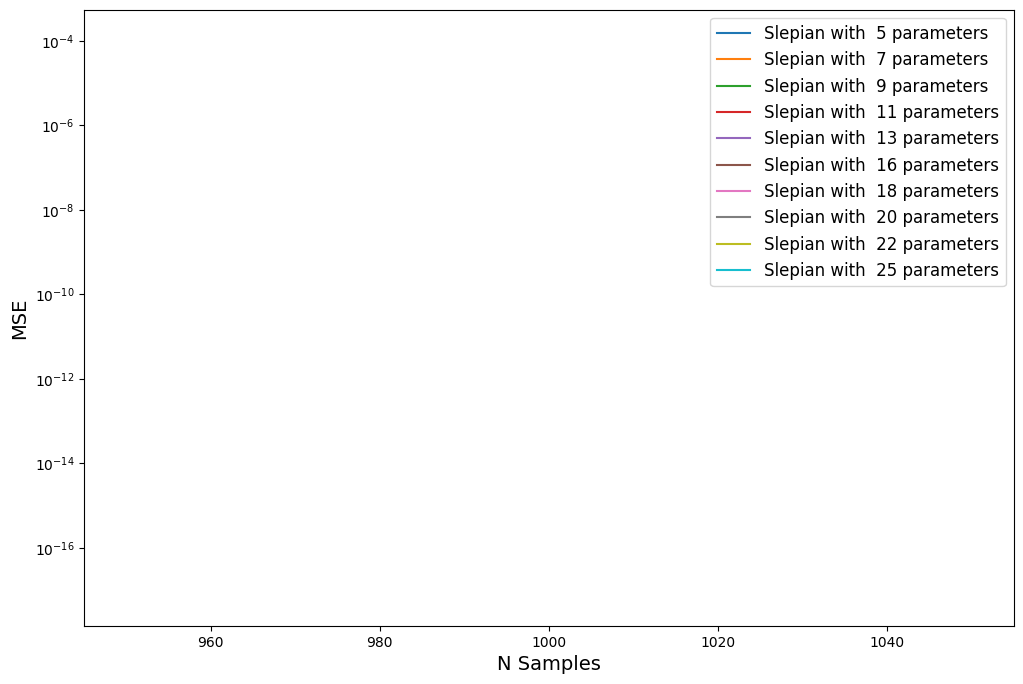

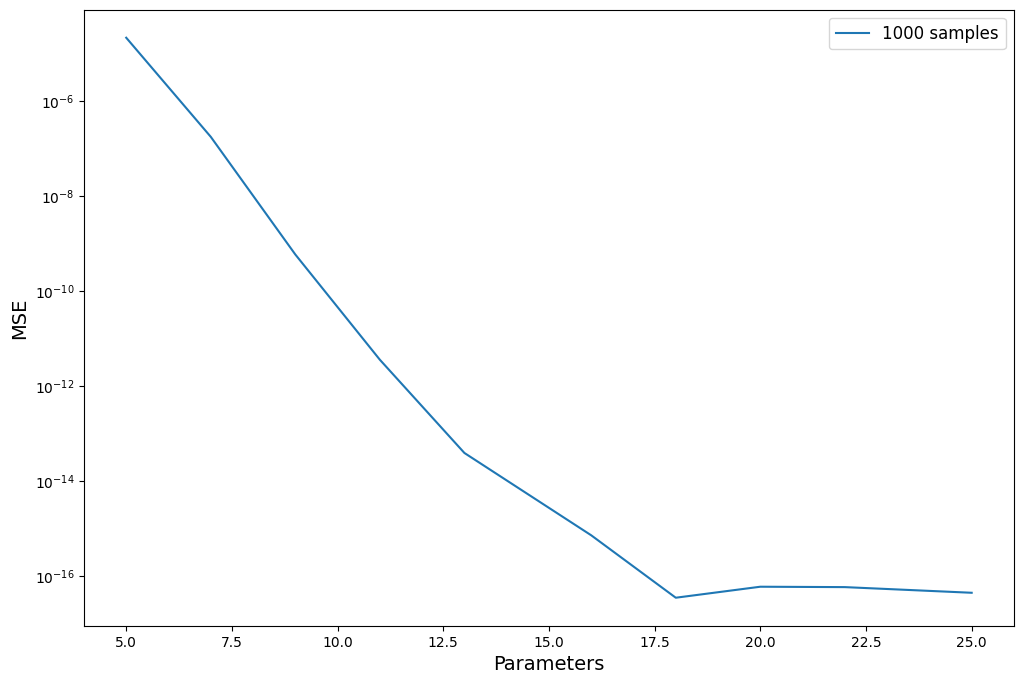

Error: 0.000444652558337536, Progress: 5.50%, approx. 196.4 seconds remaining.
Error: 3.518059867978446e-06, Progress: 6.00%, approx. 179.1 seconds remaining.
Error: 1.2147847582927484e-08, Progress: 6.50%, approx. 164.5 seconds remaining.
Error: 7.208177008667362e-11, Progress: 7.00%, approx. 151.9 seconds remaining.
Error: 7.739638101848431e-13, Progress: 7.50%, approx. 141.0 seconds remaining.
Error: 1.395790428007843e-14, Progress: 8.00%, approx. 131.5 seconds remaining.
Error: 9.201398222444756e-16, Progress: 8.50%, approx. 123.1 seconds remaining.
Error: 1.7560766469401795e-15, Progress: 9.00%, approx. 115.6 seconds remaining.
Error: 3.033134586177374e-15, Progress: 9.50%, approx. 108.9 seconds remaining.
Error: 1.6068651774490093e-15, Progress: 10.00%, approx. 102.9 seconds remaining.


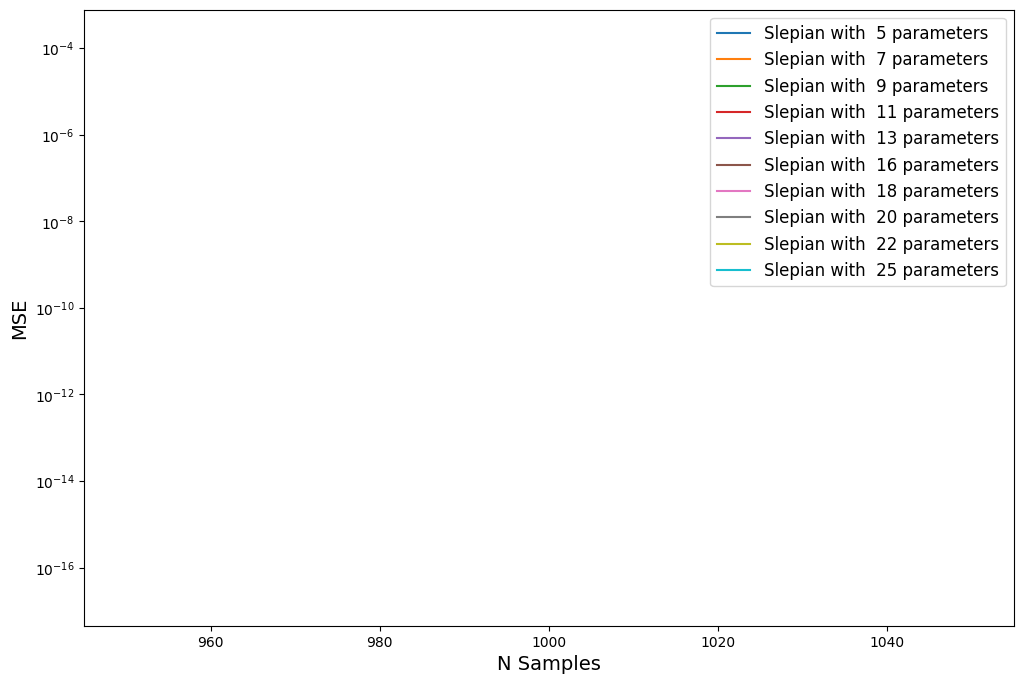

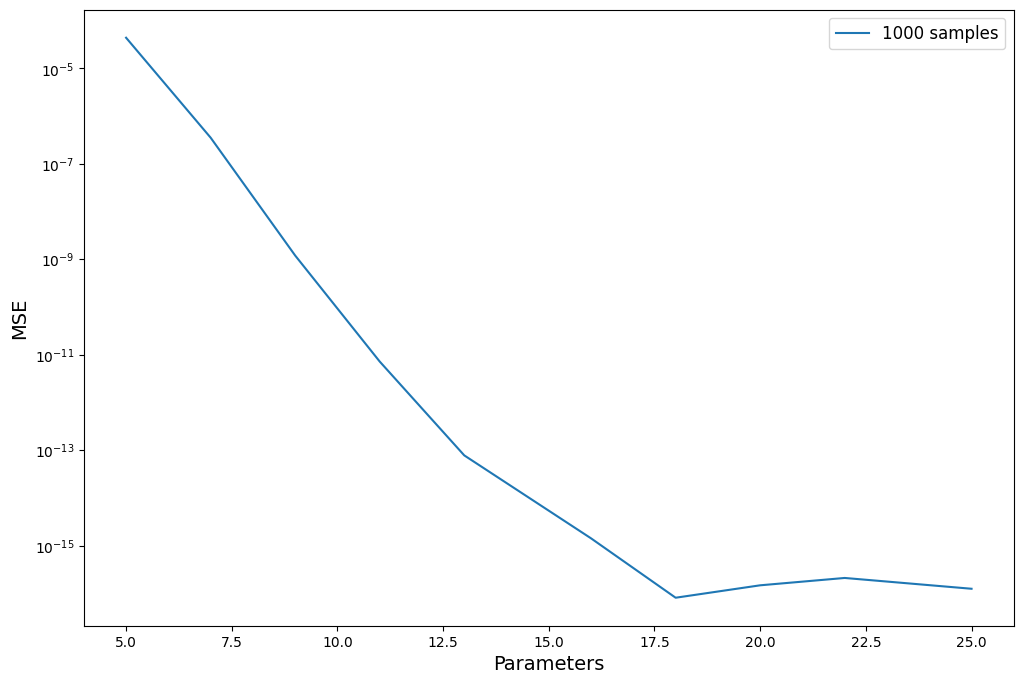

Error: 0.00044120952677381345, Progress: 10.50%, approx. 146.8 seconds remaining.
Error: 3.4691319817177243e-06, Progress: 11.00%, approx. 139.4 seconds remaining.
Error: 1.1717932421153405e-08, Progress: 11.50%, approx. 132.6 seconds remaining.
Error: 7.280352167718368e-11, Progress: 12.00%, approx. 126.3 seconds remaining.
Error: 7.713455958982163e-13, Progress: 12.50%, approx. 120.6 seconds remaining.
Error: 1.4516477458007827e-14, Progress: 13.00%, approx. 115.3 seconds remaining.
Error: 5.570952669393699e-16, Progress: 13.50%, approx. 110.4 seconds remaining.
Error: 2.459866916633119e-15, Progress: 14.00%, approx. 105.8 seconds remaining.
Error: 1.0478411714335374e-15, Progress: 14.50%, approx. 101.6 seconds remaining.
Error: 1.0156083327148124e-15, Progress: 15.00%, approx. 97.6 seconds remaining.


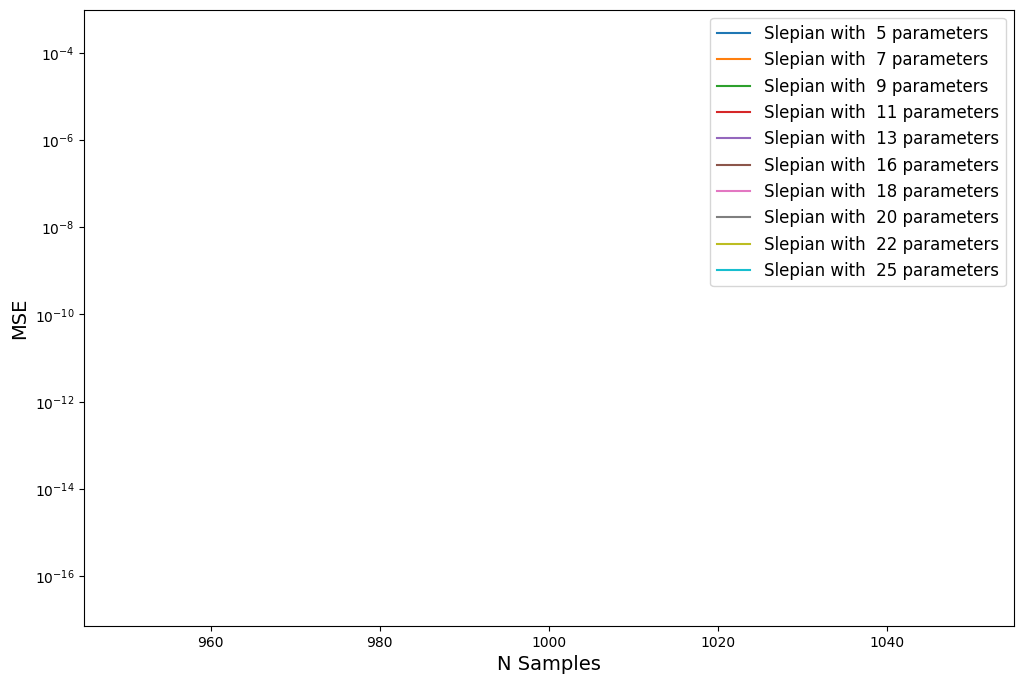

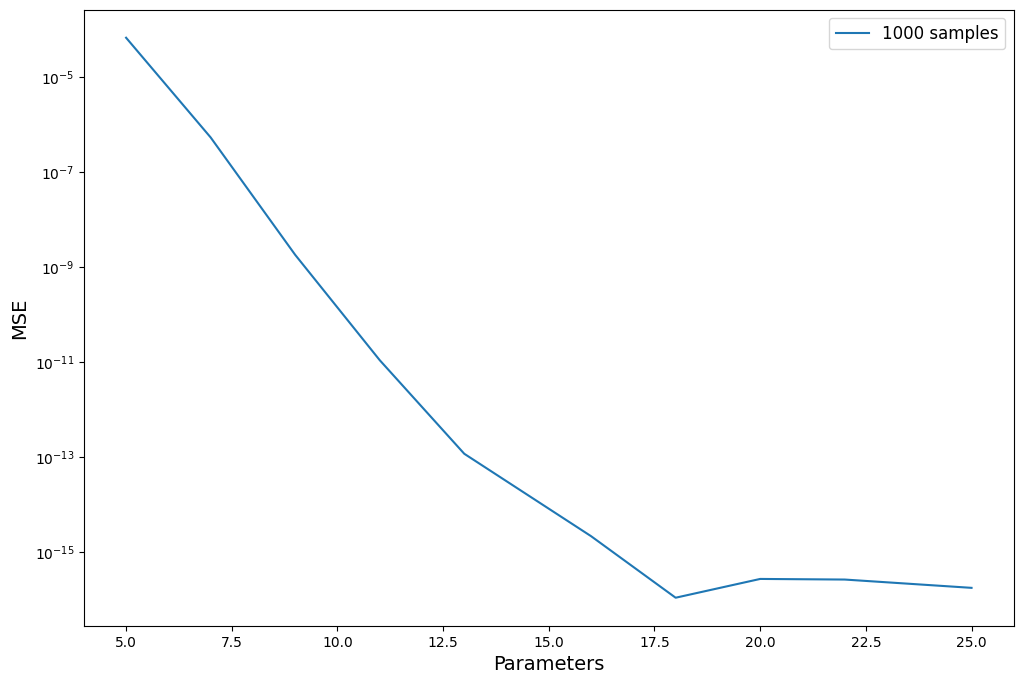

Error: 0.00043419121852833004, Progress: 15.50%, approx. 129.3 seconds remaining.
Error: 3.331583698249e-06, Progress: 16.00%, approx. 124.5 seconds remaining.
Error: 1.1859307208870173e-08, Progress: 16.50%, approx. 120.0 seconds remaining.
Error: 7.013796732237822e-11, Progress: 17.00%, approx. 115.8 seconds remaining.
Error: 7.640030313548633e-13, Progress: 17.50%, approx. 111.8 seconds remaining.
Error: 1.3393368158814146e-14, Progress: 18.00%, approx. 108.0 seconds remaining.
Error: 3.0911906798174828e-15, Progress: 18.50%, approx. 104.5 seconds remaining.
Error: 2.515325361677654e-15, Progress: 19.00%, approx. 101.1 seconds remaining.
Error: 1.4317056633634354e-15, Progress: 19.50%, approx. 97.9 seconds remaining.
Error: 2.3235856594914063e-15, Progress: 20.00%, approx. 94.9 seconds remaining.


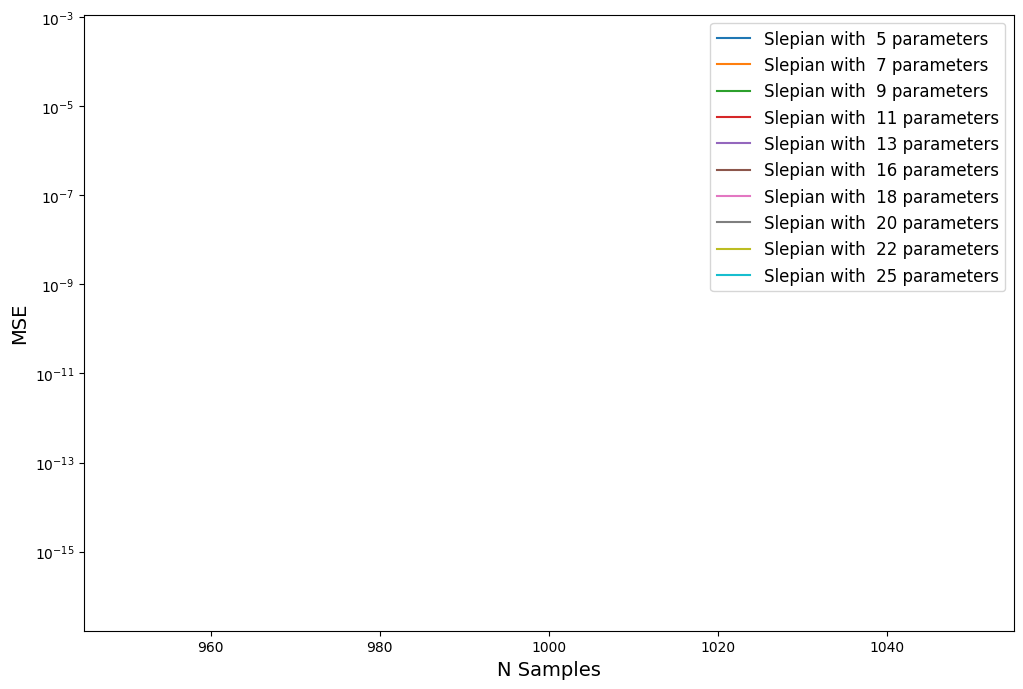

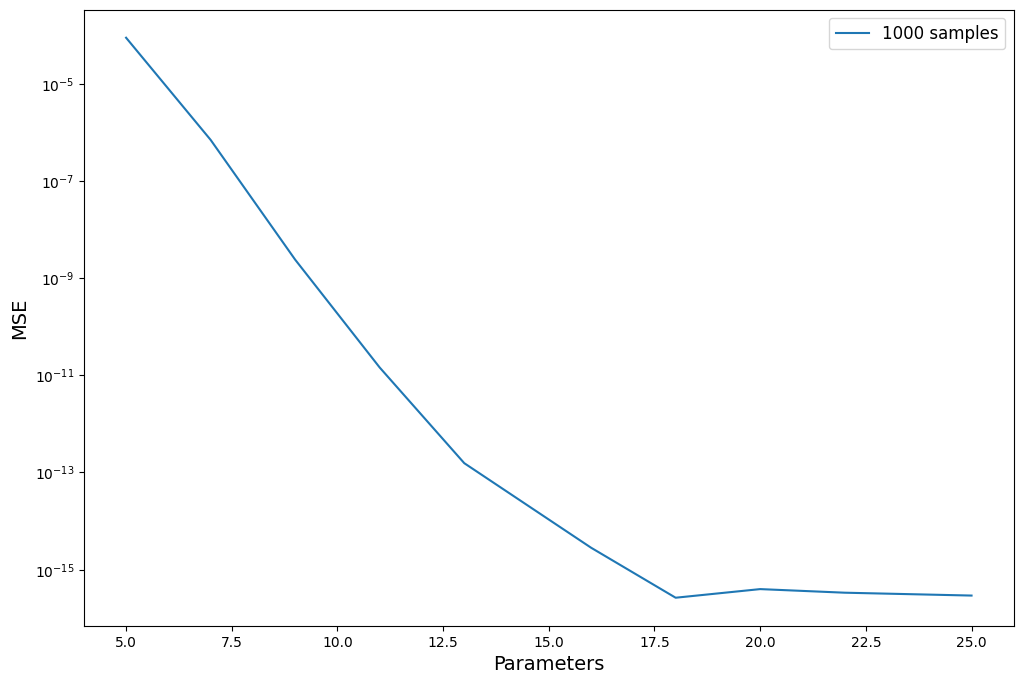

Error: 0.0004262381326397042, Progress: 20.50%, approx. 116.7 seconds remaining.
Error: 3.324740554527978e-06, Progress: 21.00%, approx. 113.2 seconds remaining.
Error: 1.1622929665416981e-08, Progress: 21.50%, approx. 109.9 seconds remaining.
Error: 7.018194452699874e-11, Progress: 22.00%, approx. 106.7 seconds remaining.
Error: 7.399165271802953e-13, Progress: 22.50%, approx. 103.6 seconds remaining.
Error: 1.3468841196032962e-14, Progress: 23.00%, approx. 100.7 seconds remaining.
Error: 1.317320672469256e-15, Progress: 23.50%, approx. 98.0 seconds remaining.
Error: 1.0637246048553849e-15, Progress: 24.00%, approx. 95.3 seconds remaining.
Error: 8.016855809015971e-16, Progress: 24.50%, approx. 92.7 seconds remaining.
Error: 1.137975892376528e-15, Progress: 25.00%, approx. 90.3 seconds remaining.


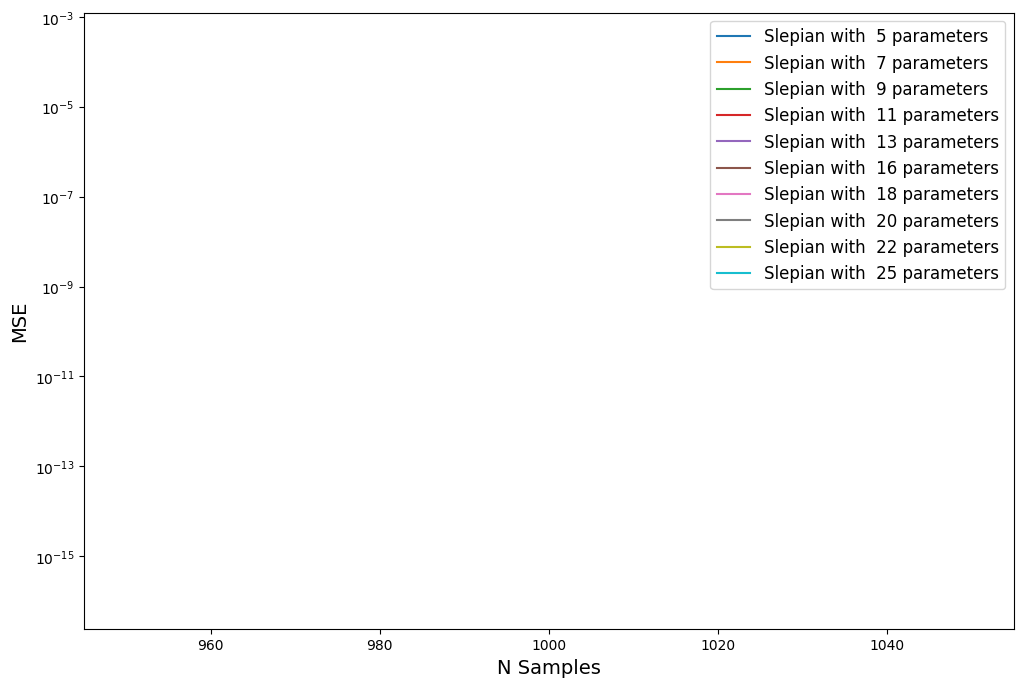

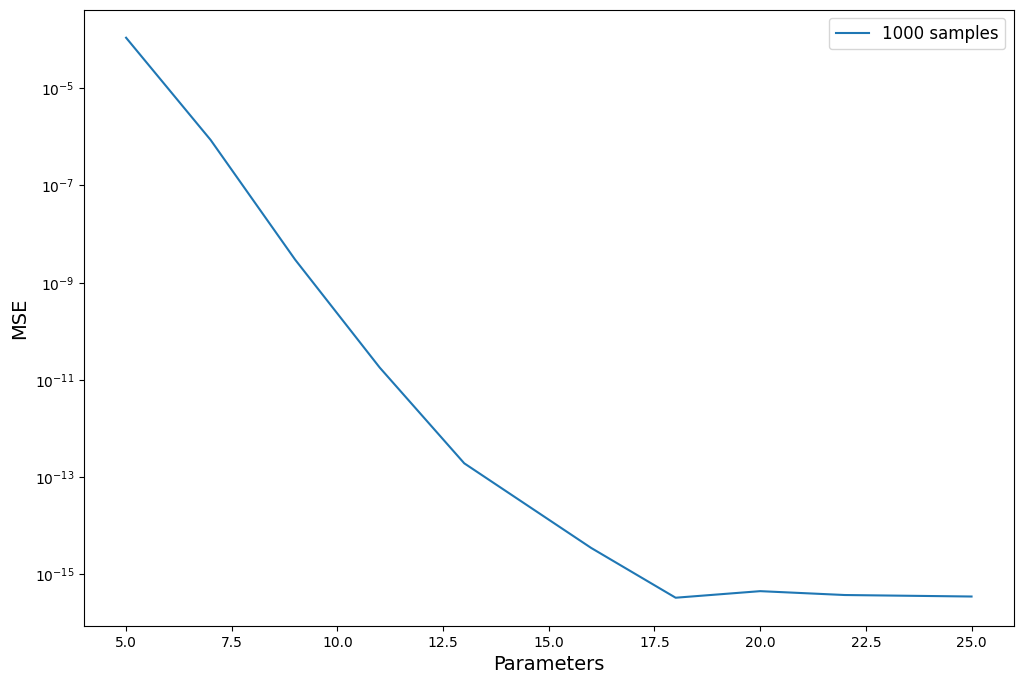

Error: 0.00042506825157460296, Progress: 25.50%, approx. 104.8 seconds remaining.
Error: 3.4539721031278893e-06, Progress: 26.00%, approx. 102.1 seconds remaining.
Error: 1.203404237281778e-08, Progress: 26.50%, approx. 99.5 seconds remaining.
Error: 7.056509922572684e-11, Progress: 27.00%, approx. 97.0 seconds remaining.
Error: 7.542095763631878e-13, Progress: 27.50%, approx. 94.6 seconds remaining.
Error: 1.3962098723272306e-14, Progress: 28.00%, approx. 92.2 seconds remaining.
Error: 1.532751246406711e-15, Progress: 28.50%, approx. 90.0 seconds remaining.
Error: 8.402782206077566e-16, Progress: 29.00%, approx. 87.8 seconds remaining.
Error: 7.7916777543571e-16, Progress: 29.50%, approx. 85.7 seconds remaining.
Error: 1.4256232022132582e-15, Progress: 30.00%, approx. 83.7 seconds remaining.


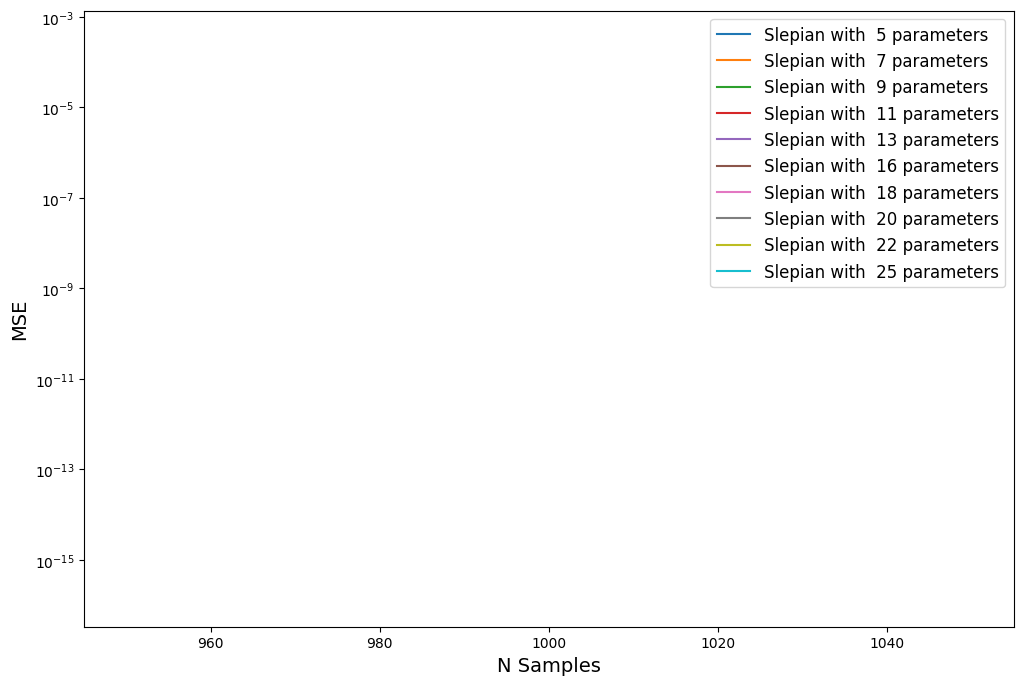

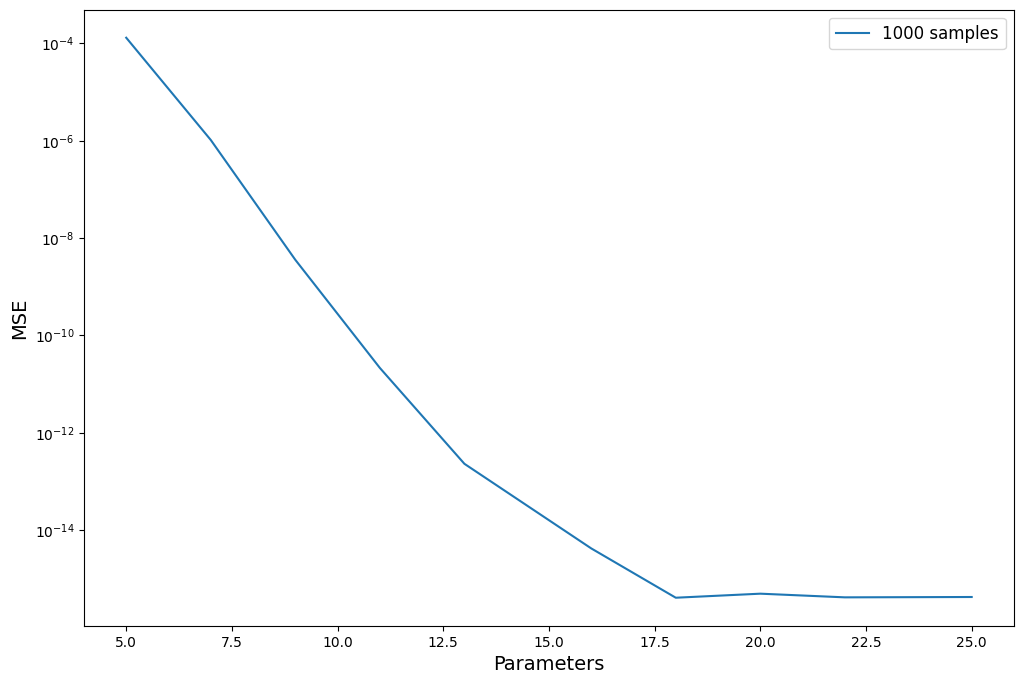

Error: 0.00043975621051220345, Progress: 30.50%, approx. 96.2 seconds remaining.
Error: 3.4451310133406834e-06, Progress: 31.00%, approx. 94.0 seconds remaining.
Error: 1.2414486123776798e-08, Progress: 31.50%, approx. 91.8 seconds remaining.
Error: 7.679915061714368e-11, Progress: 32.00%, approx. 89.7 seconds remaining.
Error: 8.400564452954486e-13, Progress: 32.50%, approx. 87.7 seconds remaining.
Error: 1.632465645844351e-14, Progress: 33.00%, approx. 85.8 seconds remaining.
Error: 8.654827597140702e-16, Progress: 33.50%, approx. 83.8 seconds remaining.
Error: 6.445996375569063e-15, Progress: 34.00%, approx. 82.0 seconds remaining.
Error: 1.4882952711903134e-15, Progress: 34.50%, approx. 80.2 seconds remaining.
Error: 3.2224153960498083e-15, Progress: 35.00%, approx. 78.4 seconds remaining.


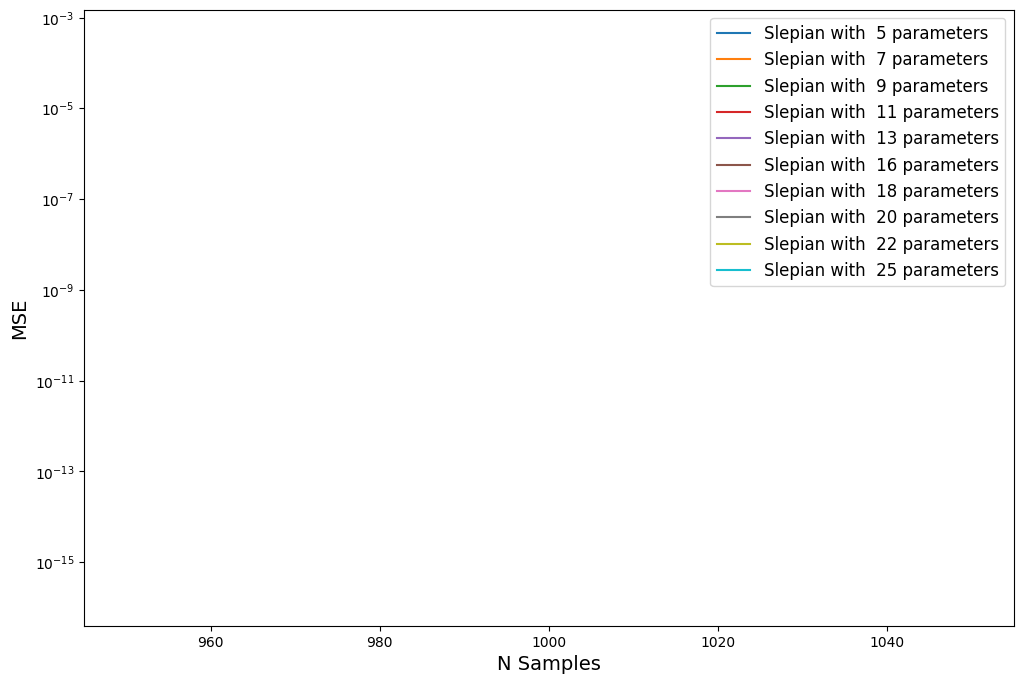

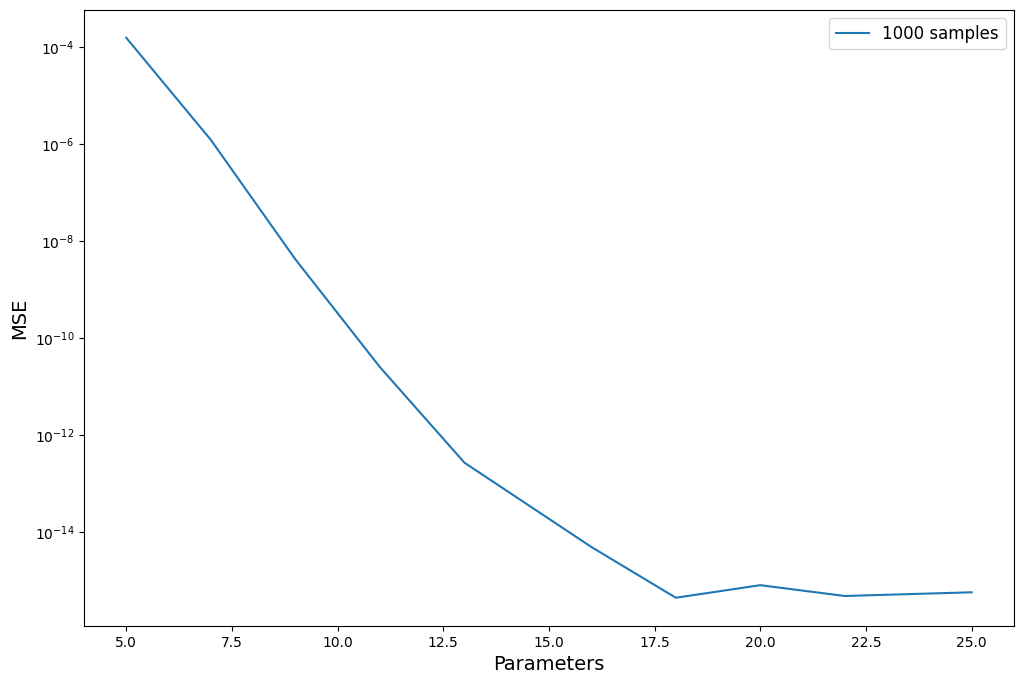

Error: 0.0004343265721136061, Progress: 35.50%, approx. 87.7 seconds remaining.
Error: 3.4037190592397797e-06, Progress: 36.00%, approx. 85.8 seconds remaining.
Error: 1.1457000416227541e-08, Progress: 36.50%, approx. 83.9 seconds remaining.
Error: 7.061544615224812e-11, Progress: 37.00%, approx. 82.2 seconds remaining.
Error: 7.69826922402039e-13, Progress: 37.50%, approx. 80.4 seconds remaining.
Error: 1.4098720397481345e-14, Progress: 38.00%, approx. 78.7 seconds remaining.
Error: 5.990782369779662e-16, Progress: 38.50%, approx. 77.1 seconds remaining.
Error: 7.854621936420948e-16, Progress: 39.00%, approx. 75.5 seconds remaining.
Error: 1.2086448961748793e-15, Progress: 39.50%, approx. 73.9 seconds remaining.
Error: 7.359531011851836e-16, Progress: 40.00%, approx. 72.4 seconds remaining.


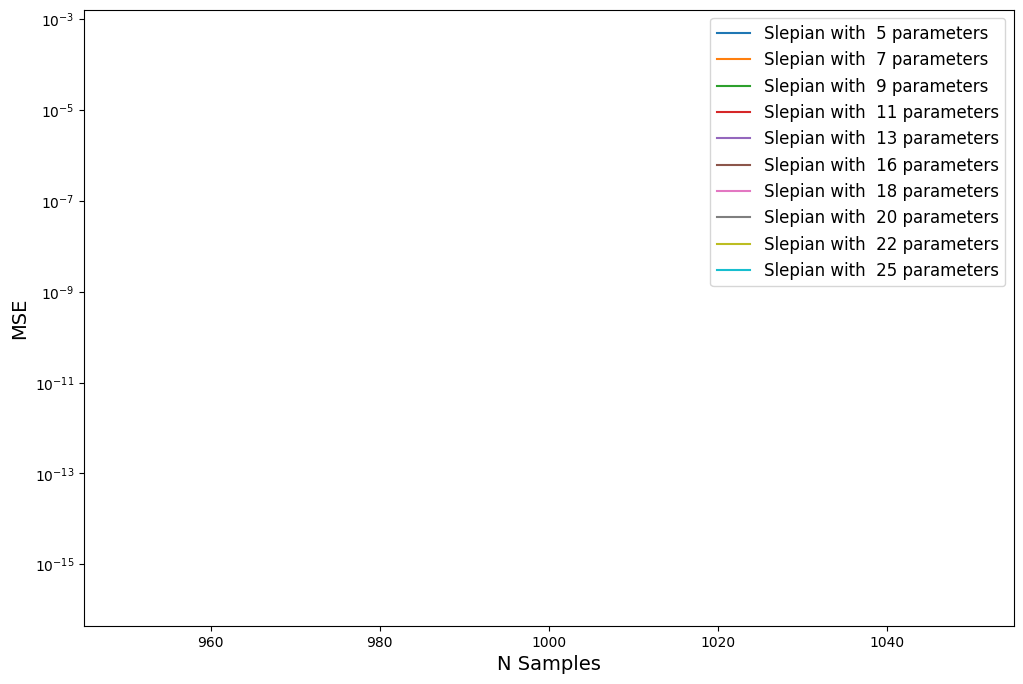

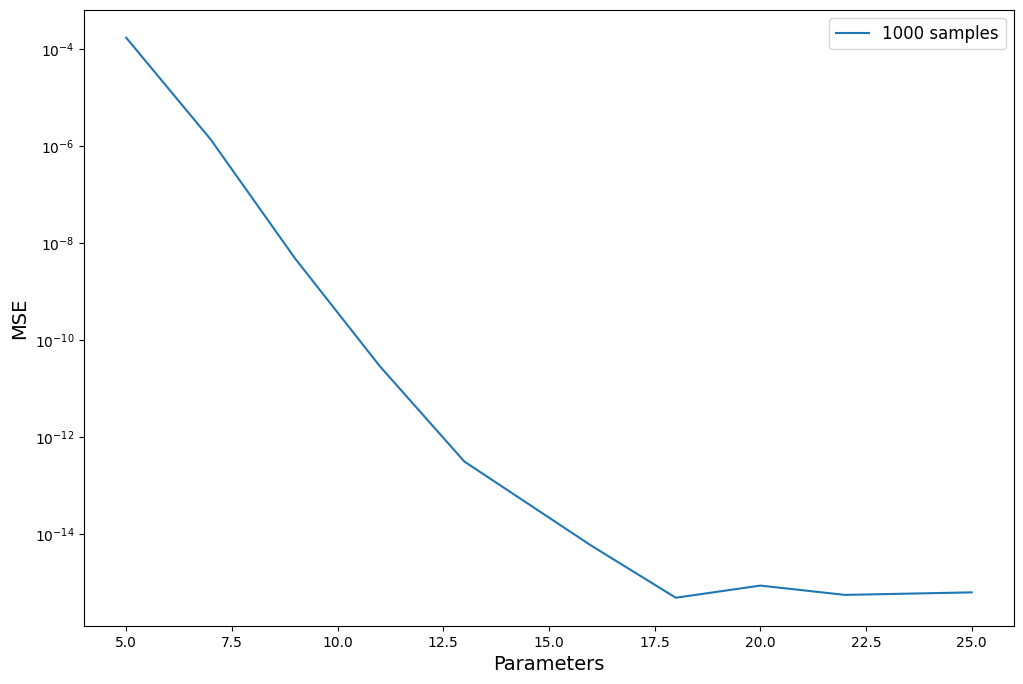

Error: 0.0004415539675165243, Progress: 40.50%, approx. 79.8 seconds remaining.
Error: 3.4031445094132518e-06, Progress: 41.00%, approx. 78.1 seconds remaining.
Error: 1.1920238295459291e-08, Progress: 41.50%, approx. 76.5 seconds remaining.
Error: 7.098180607140828e-11, Progress: 42.00%, approx. 75.0 seconds remaining.
Error: 7.52463202666089e-13, Progress: 42.50%, approx. 73.5 seconds remaining.
Error: 1.386679979940255e-14, Progress: 43.00%, approx. 72.0 seconds remaining.
Error: 1.4889411213019556e-15, Progress: 43.50%, approx. 70.5 seconds remaining.
Error: 1.2518964619905902e-15, Progress: 44.00%, approx. 69.1 seconds remaining.
Error: 8.914683013164008e-16, Progress: 44.50%, approx. 67.7 seconds remaining.
Error: 1.903778381333122e-15, Progress: 45.00%, approx. 66.4 seconds remaining.


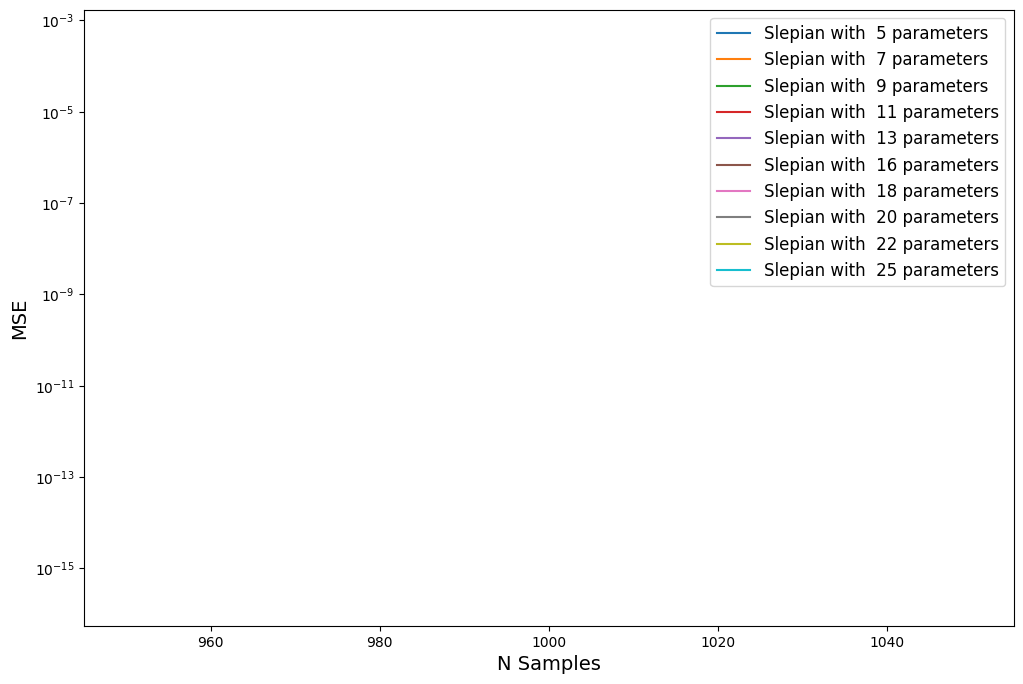

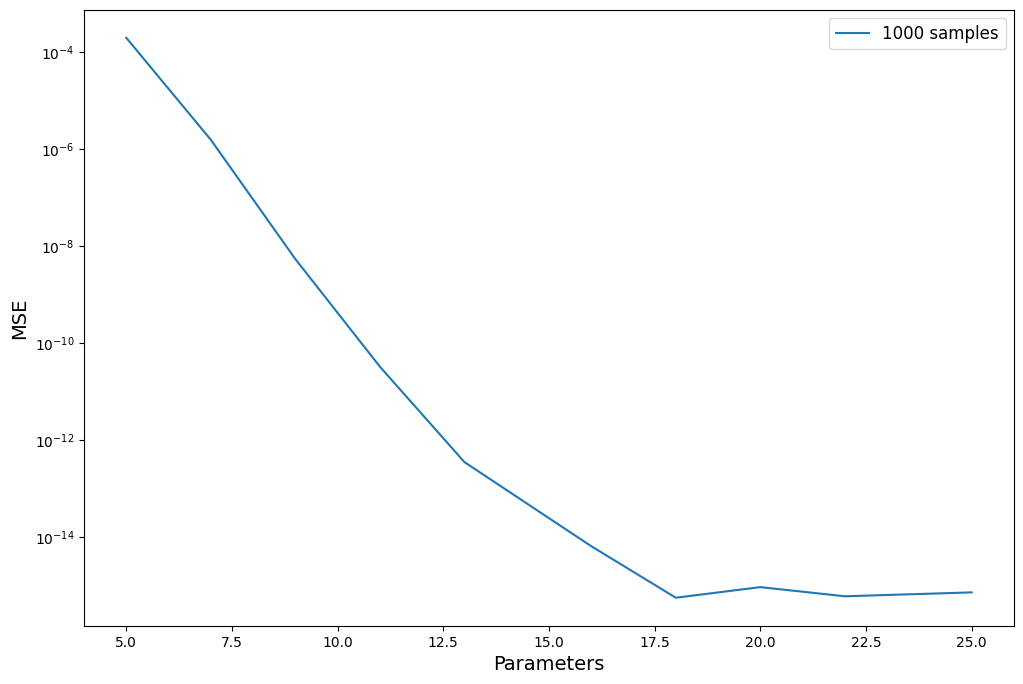

Error: 0.0004512643417823677, Progress: 45.50%, approx. 71.9 seconds remaining.
Error: 3.6237101843621754e-06, Progress: 46.00%, approx. 70.5 seconds remaining.
Error: 1.258856504272315e-08, Progress: 46.50%, approx. 69.1 seconds remaining.
Error: 7.683590387450914e-11, Progress: 47.00%, approx. 67.7 seconds remaining.
Error: 8.478449417151344e-13, Progress: 47.50%, approx. 66.4 seconds remaining.
Error: 1.5575413737867984e-14, Progress: 48.00%, approx. 65.1 seconds remaining.
Error: 1.1150420361305573e-15, Progress: 48.50%, approx. 63.8 seconds remaining.
Error: 8.720729421554322e-16, Progress: 49.00%, approx. 62.5 seconds remaining.
Error: 1.1614174607649526e-15, Progress: 49.50%, approx. 61.3 seconds remaining.
Error: 8.229441579671362e-16, Progress: 50.00%, approx. 60.1 seconds remaining.


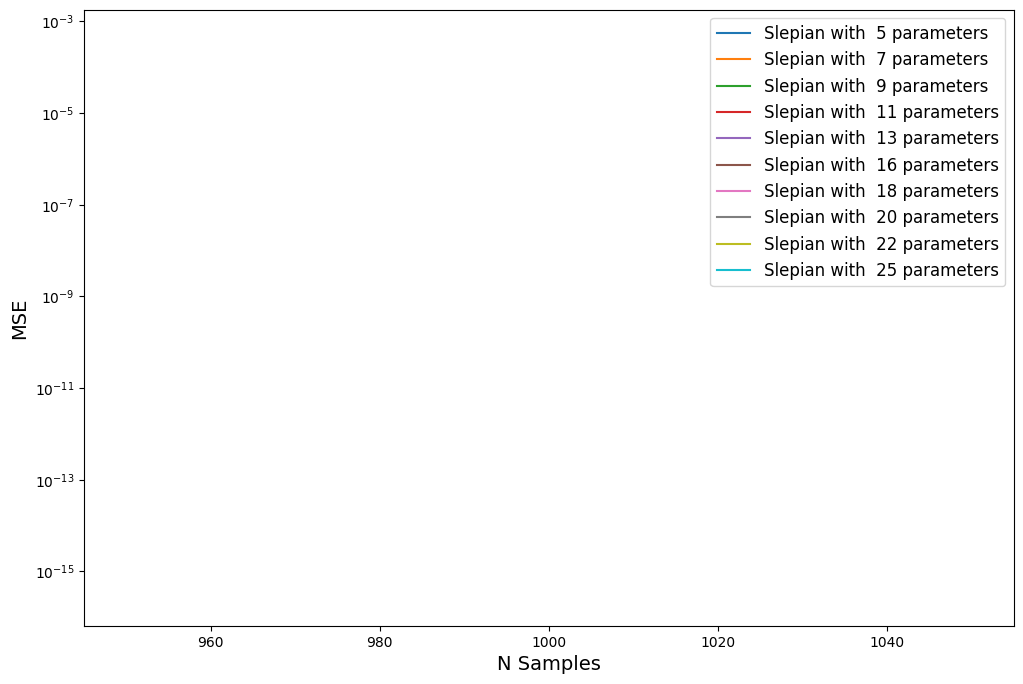

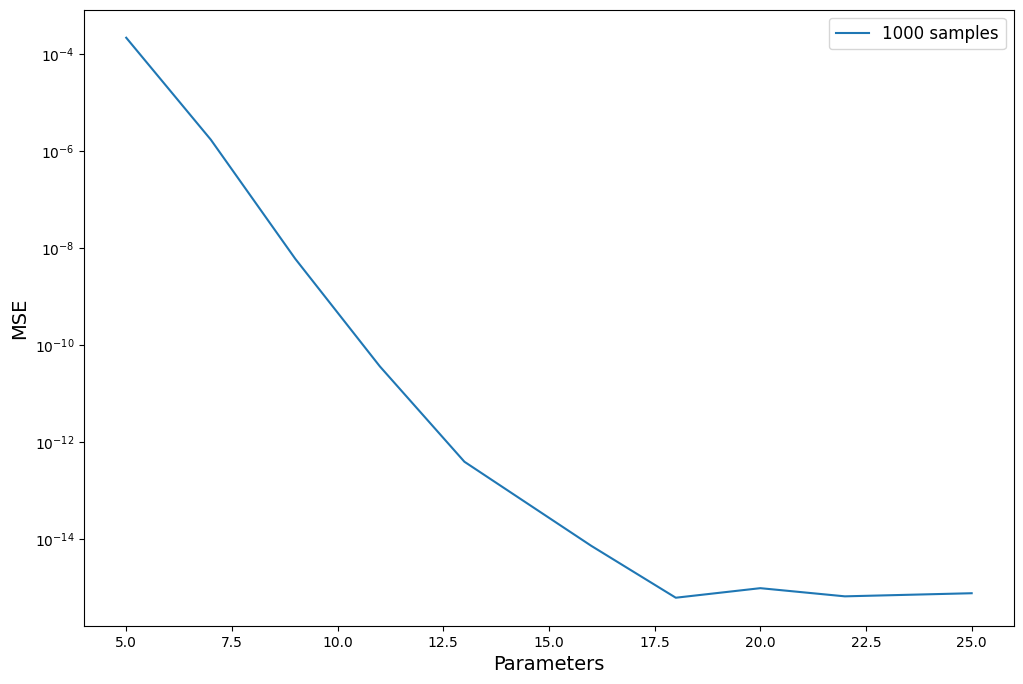

Error: 0.0004493512441224686, Progress: 50.50%, approx. 64.7 seconds remaining.
Error: 3.520181284385073e-06, Progress: 51.00%, approx. 63.4 seconds remaining.
Error: 1.1900476368688283e-08, Progress: 51.50%, approx. 62.1 seconds remaining.
Error: 7.120394146979712e-11, Progress: 52.00%, approx. 60.9 seconds remaining.
Error: 7.590928816935618e-13, Progress: 52.50%, approx. 59.7 seconds remaining.
Error: 1.411519756994441e-14, Progress: 53.00%, approx. 58.5 seconds remaining.
Error: 9.785909058863036e-16, Progress: 53.50%, approx. 57.3 seconds remaining.
Error: 5.608000144424553e-15, Progress: 54.00%, approx. 56.2 seconds remaining.
Error: 7.271918436246708e-16, Progress: 54.50%, approx. 55.1 seconds remaining.
Error: 1.0572448150223284e-15, Progress: 55.00%, approx. 54.0 seconds remaining.


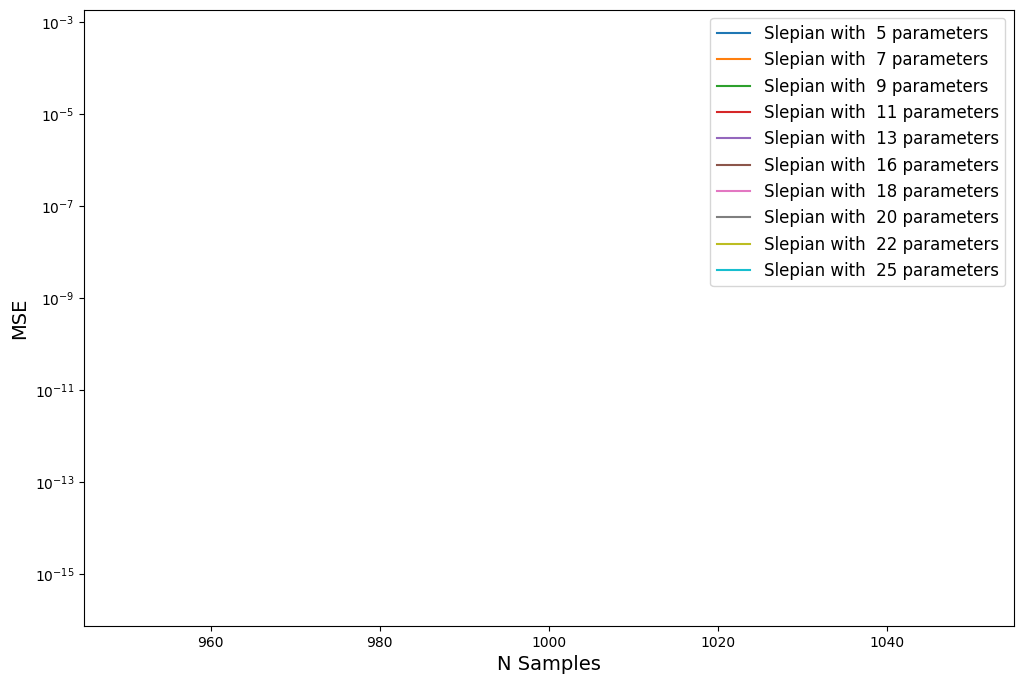

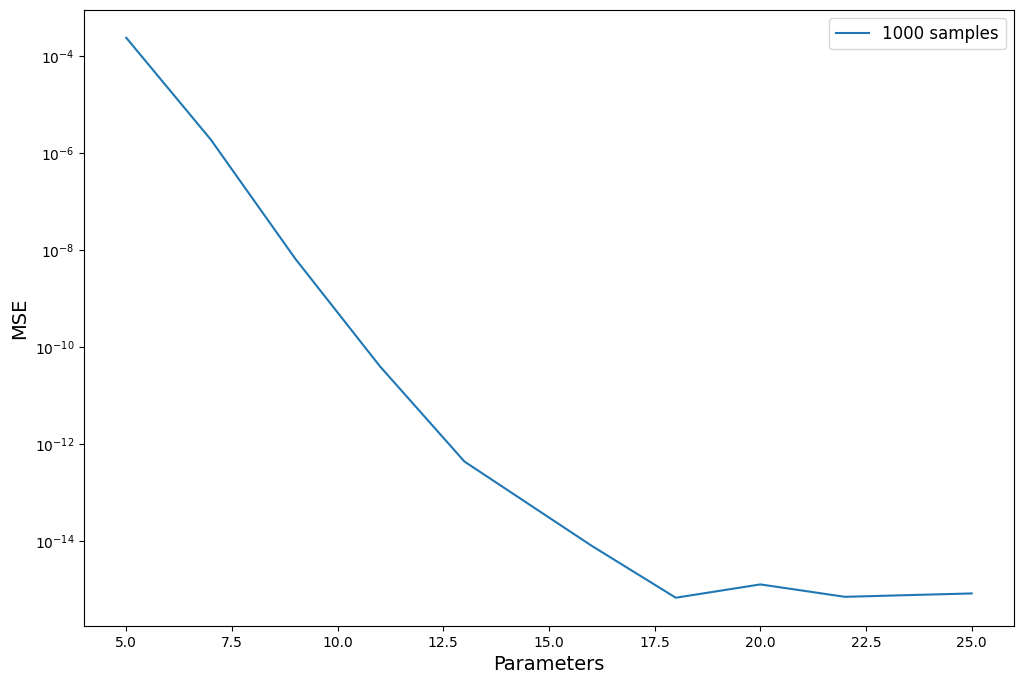

Error: 0.000426404133411851, Progress: 55.50%, approx. 57.7 seconds remaining.
Error: 3.441779516474594e-06, Progress: 56.00%, approx. 56.5 seconds remaining.
Error: 1.1833743400332753e-08, Progress: 56.50%, approx. 55.4 seconds remaining.
Error: 7.137901386717319e-11, Progress: 57.00%, approx. 54.2 seconds remaining.
Error: 7.536984735955218e-13, Progress: 57.50%, approx. 53.1 seconds remaining.
Error: 1.3771181514970622e-14, Progress: 58.00%, approx. 52.1 seconds remaining.
Error: 2.3936521698714024e-15, Progress: 58.50%, approx. 51.0 seconds remaining.
Error: 2.6180979846767884e-15, Progress: 59.00%, approx. 50.0 seconds remaining.
Error: 7.521382031625692e-16, Progress: 59.50%, approx. 48.9 seconds remaining.
Error: 1.2818052512969162e-15, Progress: 60.00%, approx. 47.9 seconds remaining.


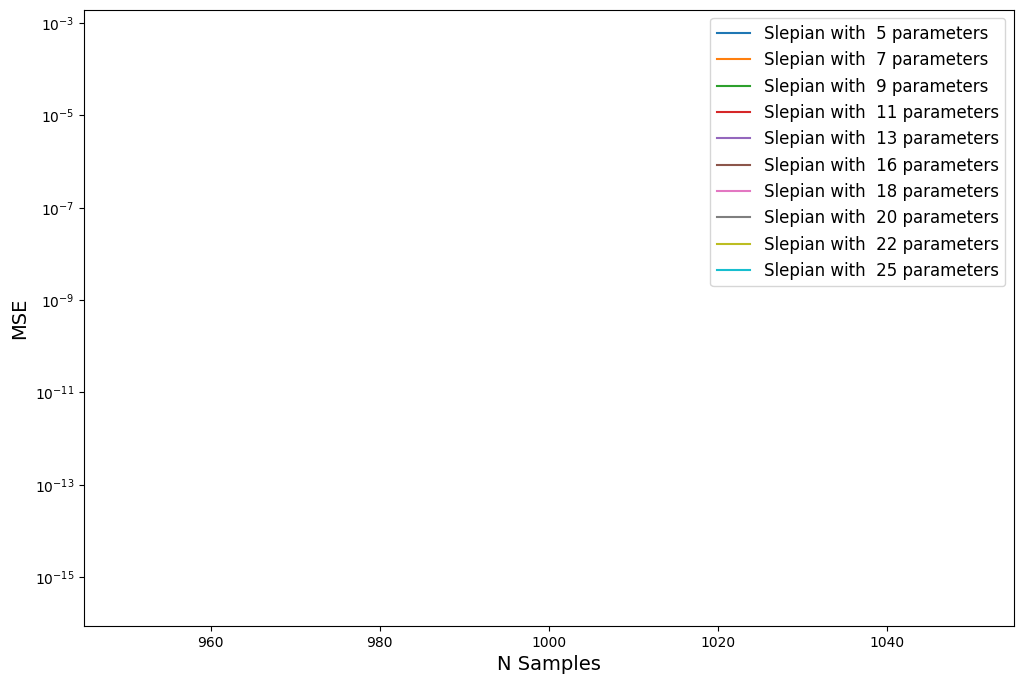

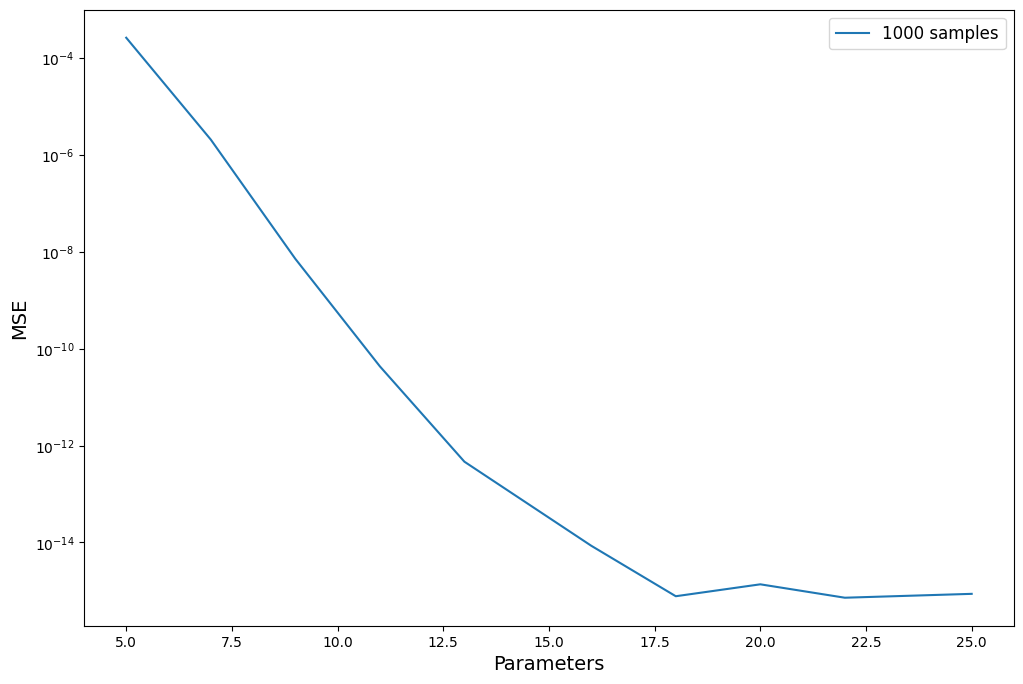

Error: 0.0004418772060863937, Progress: 60.50%, approx. 50.8 seconds remaining.
Error: 3.497329434228151e-06, Progress: 61.00%, approx. 49.7 seconds remaining.
Error: 1.2348009268175346e-08, Progress: 61.50%, approx. 48.7 seconds remaining.
Error: 7.389133972321863e-11, Progress: 62.00%, approx. 47.7 seconds remaining.
Error: 7.905225638853753e-13, Progress: 62.50%, approx. 46.7 seconds remaining.
Error: 1.4625466875776895e-14, Progress: 63.00%, approx. 45.7 seconds remaining.
Error: 7.974307777594241e-16, Progress: 63.50%, approx. 44.7 seconds remaining.
Error: 7.973380298833558e-16, Progress: 64.00%, approx. 43.7 seconds remaining.
Error: 7.337305976708402e-16, Progress: 64.50%, approx. 42.8 seconds remaining.
Error: 1.258750086410996e-15, Progress: 65.00%, approx. 41.9 seconds remaining.


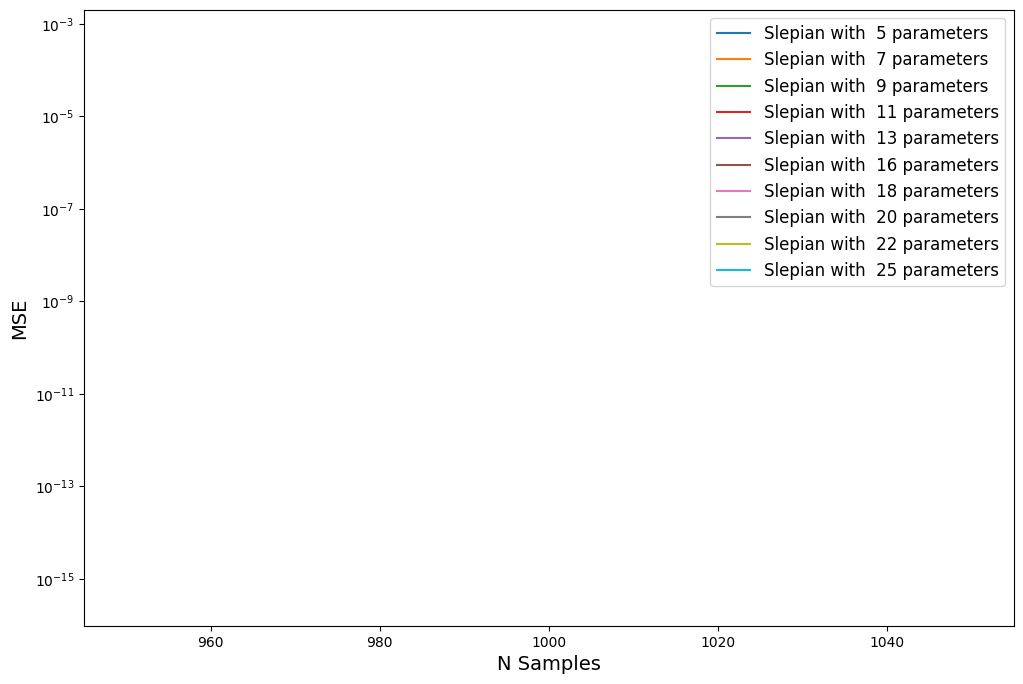

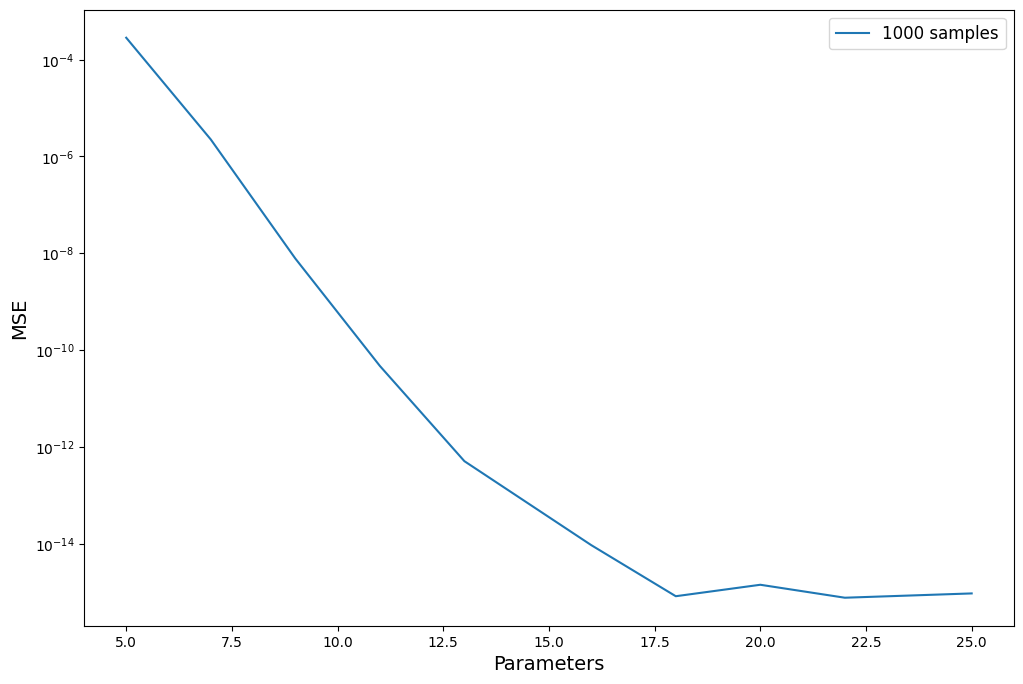

Error: 0.00042567851531667694, Progress: 65.50%, approx. 44.4 seconds remaining.
Error: 3.4519447759226817e-06, Progress: 66.00%, approx. 43.4 seconds remaining.
Error: 1.179891150967458e-08, Progress: 66.50%, approx. 42.4 seconds remaining.
Error: 7.01104530923113e-11, Progress: 67.00%, approx. 41.5 seconds remaining.
Error: 7.624029298335426e-13, Progress: 67.50%, approx. 40.6 seconds remaining.
Error: 1.341885194198723e-14, Progress: 68.00%, approx. 39.6 seconds remaining.
Error: 6.193711270463367e-16, Progress: 68.50%, approx. 38.7 seconds remaining.
Error: 9.271924413884563e-16, Progress: 69.00%, approx. 37.9 seconds remaining.
Error: 1.282843368384259e-15, Progress: 69.50%, approx. 37.0 seconds remaining.
Error: 2.512155293691659e-15, Progress: 70.00%, approx. 36.1 seconds remaining.


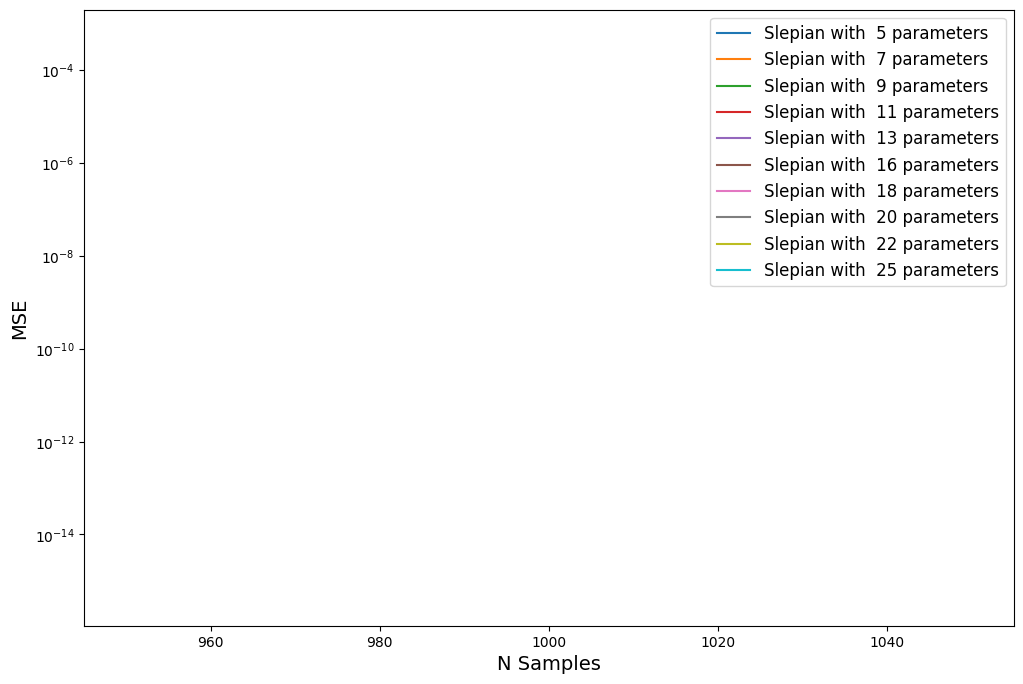

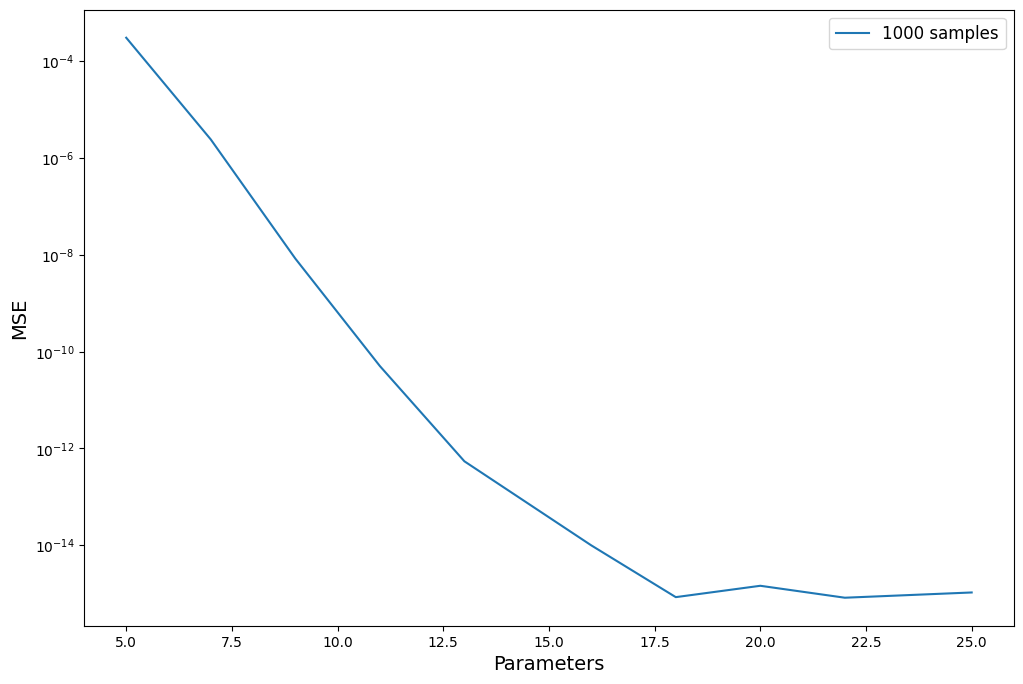

Error: 0.00044259766987005453, Progress: 70.50%, approx. 37.9 seconds remaining.
Error: 3.3938418103552925e-06, Progress: 71.00%, approx. 37.0 seconds remaining.
Error: 1.1758360574308554e-08, Progress: 71.50%, approx. 36.1 seconds remaining.
Error: 7.130556457395087e-11, Progress: 72.00%, approx. 35.2 seconds remaining.
Error: 7.562625875901697e-13, Progress: 72.50%, approx. 34.4 seconds remaining.
Error: 1.394993750437886e-14, Progress: 73.00%, approx. 33.5 seconds remaining.
Error: 1.009662235959876e-15, Progress: 73.50%, approx. 32.7 seconds remaining.
Error: 6.896352979559279e-16, Progress: 74.00%, approx. 31.8 seconds remaining.
Error: 6.954995660100797e-16, Progress: 74.50%, approx. 31.0 seconds remaining.
Error: 1.0860682614512396e-15, Progress: 75.00%, approx. 30.2 seconds remaining.


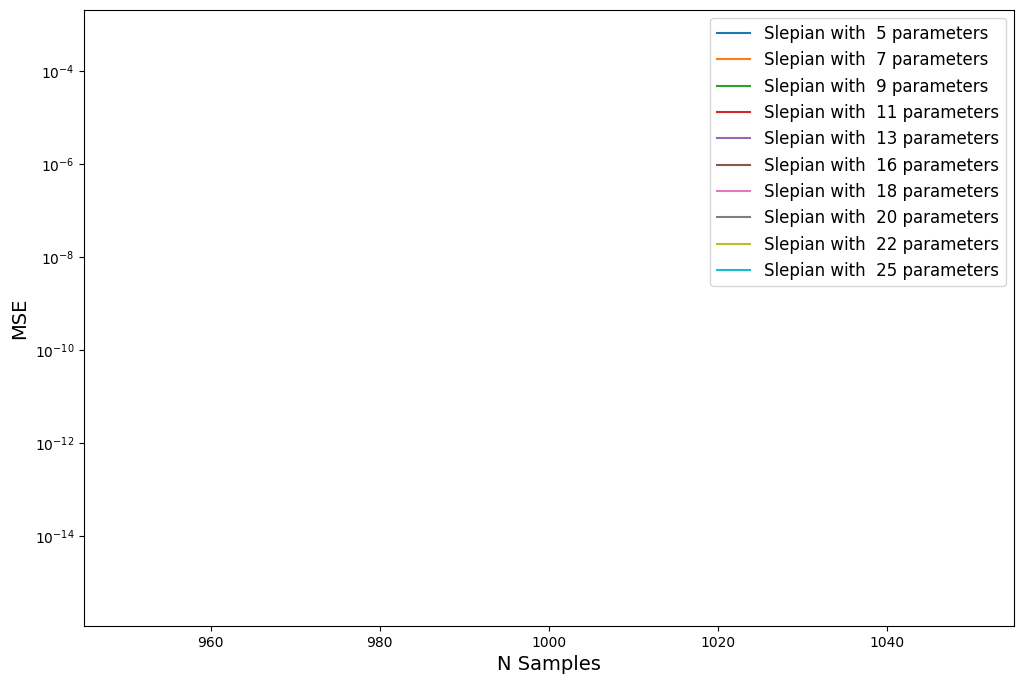

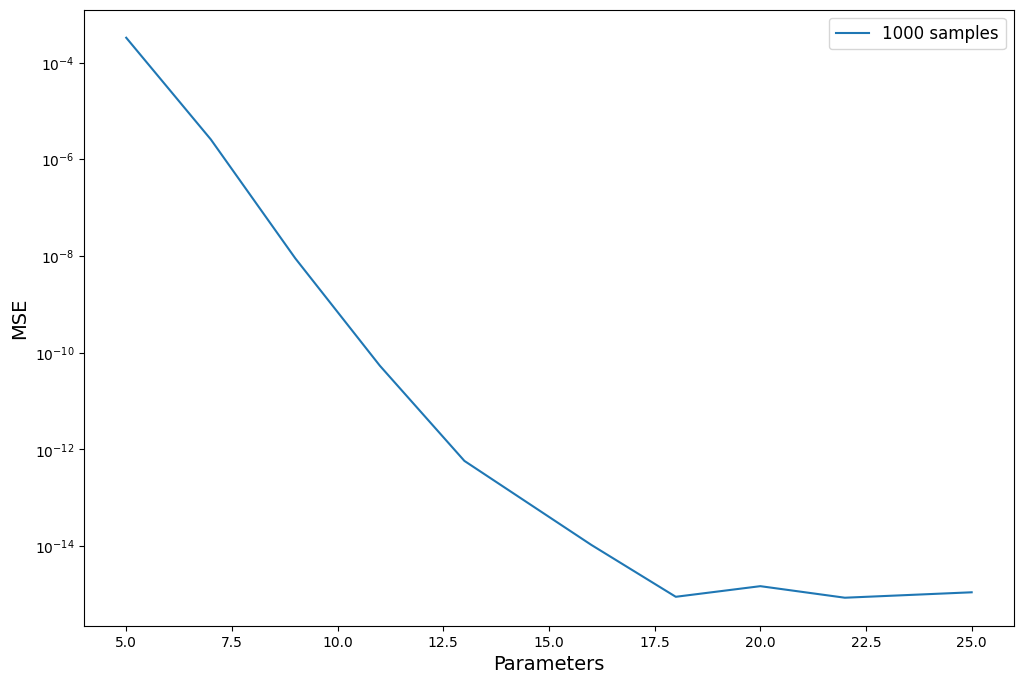

Error: 0.00043342841672749103, Progress: 75.50%, approx. 31.2 seconds remaining.
Error: 3.4169189577676286e-06, Progress: 76.00%, approx. 30.4 seconds remaining.
Error: 1.1614375657901536e-08, Progress: 76.50%, approx. 29.6 seconds remaining.
Error: 6.936015495368439e-11, Progress: 77.00%, approx. 28.8 seconds remaining.
Error: 7.44812775661484e-13, Progress: 77.50%, approx. 28.0 seconds remaining.
Error: 1.333704408585422e-14, Progress: 78.00%, approx. 27.2 seconds remaining.
Error: 9.926101675226783e-16, Progress: 78.50%, approx. 26.4 seconds remaining.
Error: 1.3488090342085756e-15, Progress: 79.00%, approx. 25.6 seconds remaining.
Error: 1.3979422932702495e-15, Progress: 79.50%, approx. 24.8 seconds remaining.
Error: 9.615198016763554e-16, Progress: 80.00%, approx. 24.1 seconds remaining.


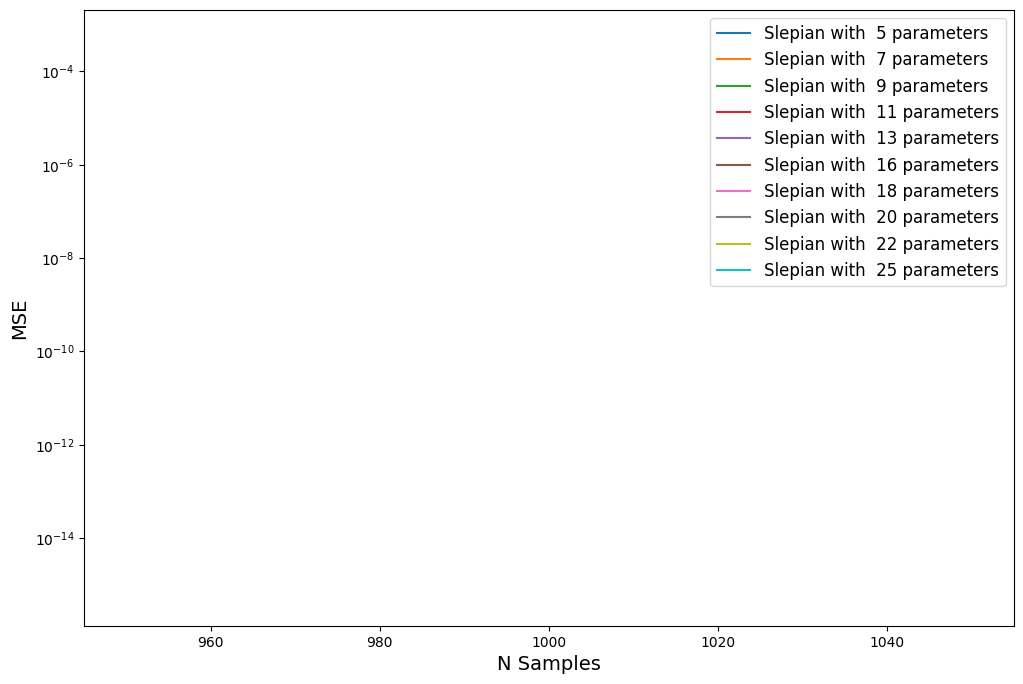

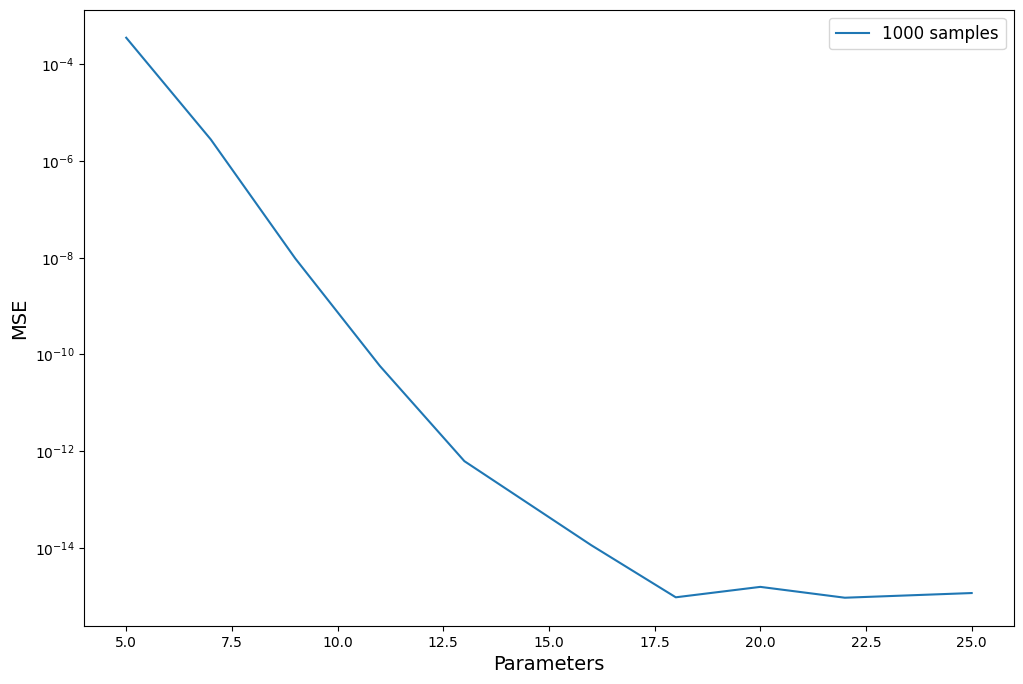

Error: 0.0004539794377600105, Progress: 80.50%, approx. 24.7 seconds remaining.
Error: 3.6298446517782545e-06, Progress: 81.00%, approx. 24.0 seconds remaining.
Error: 1.272750803122763e-08, Progress: 81.50%, approx. 23.2 seconds remaining.
Error: 7.502745674962746e-11, Progress: 82.00%, approx. 22.4 seconds remaining.
Error: 8.07009134991532e-13, Progress: 82.50%, approx. 21.7 seconds remaining.
Error: 1.5261578954106243e-14, Progress: 83.00%, approx. 20.9 seconds remaining.
Error: 4.990943365488919e-16, Progress: 83.50%, approx. 20.2 seconds remaining.
Error: 9.416366908040582e-16, Progress: 84.00%, approx. 19.4 seconds remaining.
Error: 5.532097733869318e-16, Progress: 84.50%, approx. 18.7 seconds remaining.
Error: 8.0542835499369e-16, Progress: 85.00%, approx. 18.0 seconds remaining.


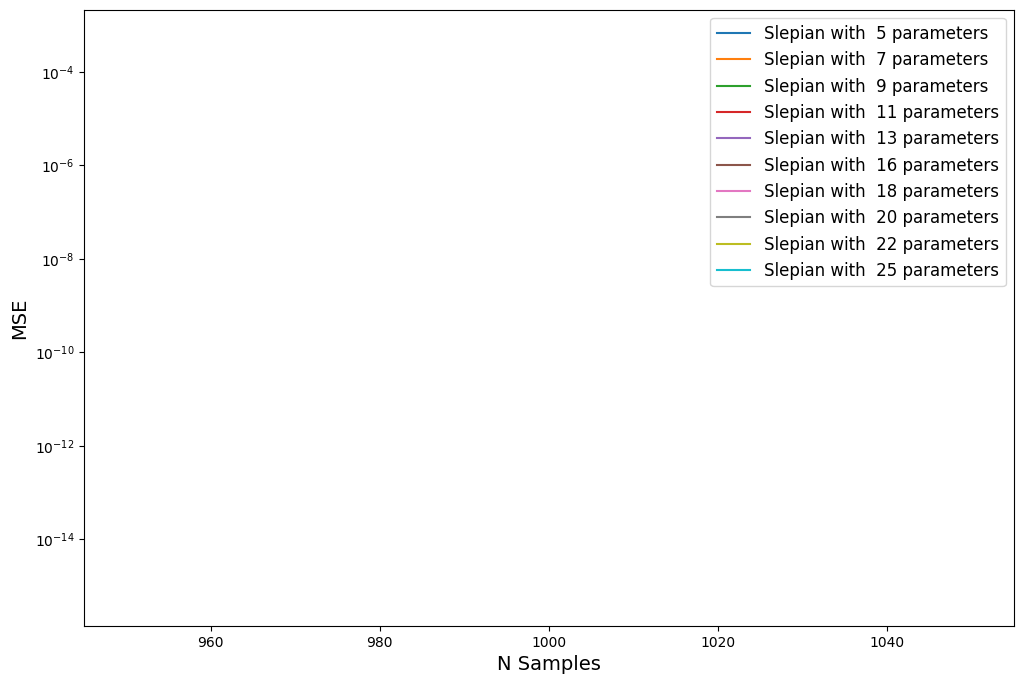

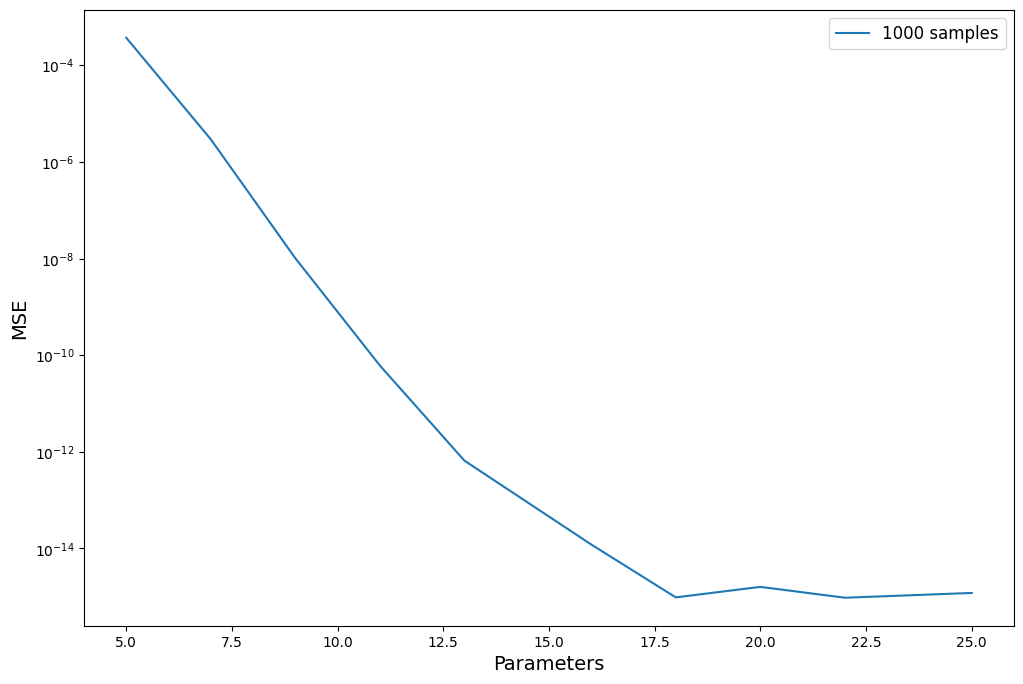

Error: 0.00044857925801277895, Progress: 85.50%, approx. 18.3 seconds remaining.
Error: 3.449669399279081e-06, Progress: 86.00%, approx. 17.6 seconds remaining.
Error: 1.2061238892579931e-08, Progress: 86.50%, approx. 16.9 seconds remaining.
Error: 7.362364496363908e-11, Progress: 87.00%, approx. 16.2 seconds remaining.
Error: 7.837827212884315e-13, Progress: 87.50%, approx. 15.4 seconds remaining.
Error: 1.4559411578750648e-14, Progress: 88.00%, approx. 14.7 seconds remaining.
Error: 5.9890548610989034e-15, Progress: 88.50%, approx. 14.1 seconds remaining.
Error: 1.0077987971177842e-15, Progress: 89.00%, approx. 13.4 seconds remaining.
Error: 1.3884580710229532e-15, Progress: 89.50%, approx. 12.7 seconds remaining.
Error: 2.419876191278612e-15, Progress: 90.00%, approx. 12.0 seconds remaining.


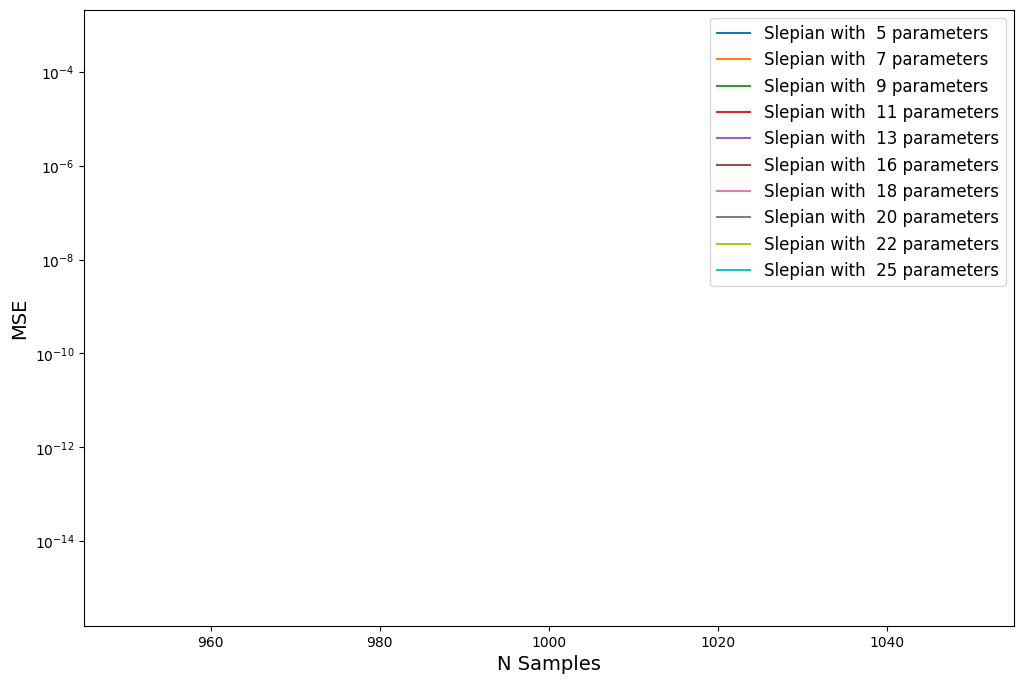

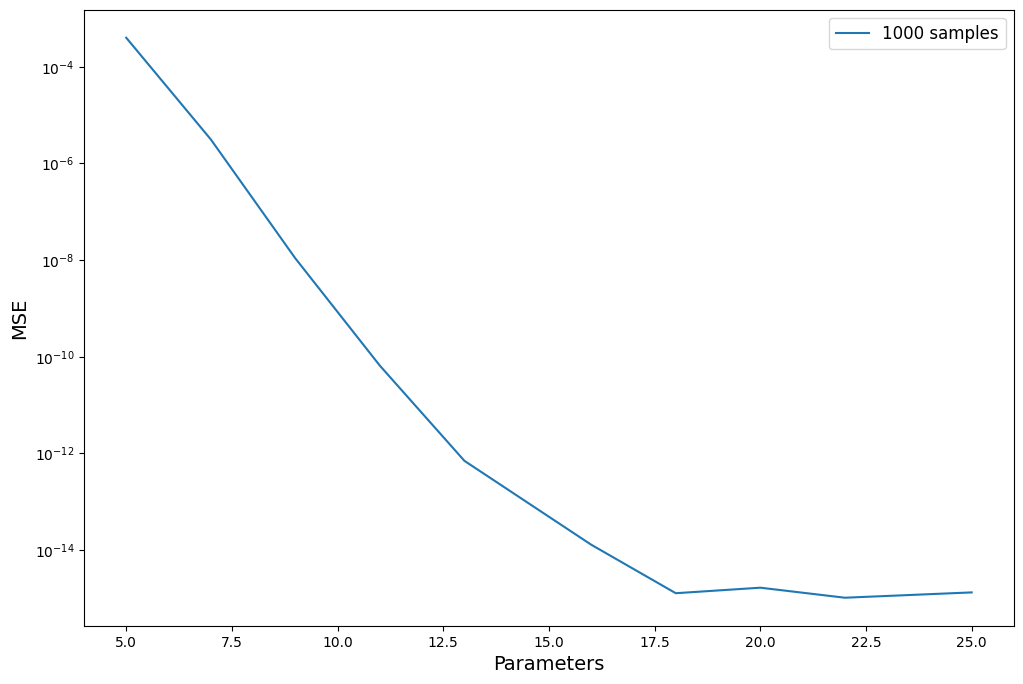

Error: 0.00043776890884937797, Progress: 90.50%, approx. 12.0 seconds remaining.
Error: 3.386089791668464e-06, Progress: 91.00%, approx. 11.3 seconds remaining.
Error: 1.1728976971352904e-08, Progress: 91.50%, approx. 10.6 seconds remaining.
Error: 6.954711665794645e-11, Progress: 92.00%, approx. 9.9 seconds remaining.
Error: 7.615934059856564e-13, Progress: 92.50%, approx. 9.3 seconds remaining.
Error: 1.3790058692303131e-14, Progress: 93.00%, approx. 8.6 seconds remaining.
Error: 2.1264988191296324e-15, Progress: 93.50%, approx. 7.9 seconds remaining.
Error: 3.0733732711615246e-15, Progress: 94.00%, approx. 7.3 seconds remaining.
Error: 3.2209290150935323e-15, Progress: 94.50%, approx. 6.6 seconds remaining.
Error: 3.4858085863934325e-15, Progress: 95.00%, approx. 6.0 seconds remaining.


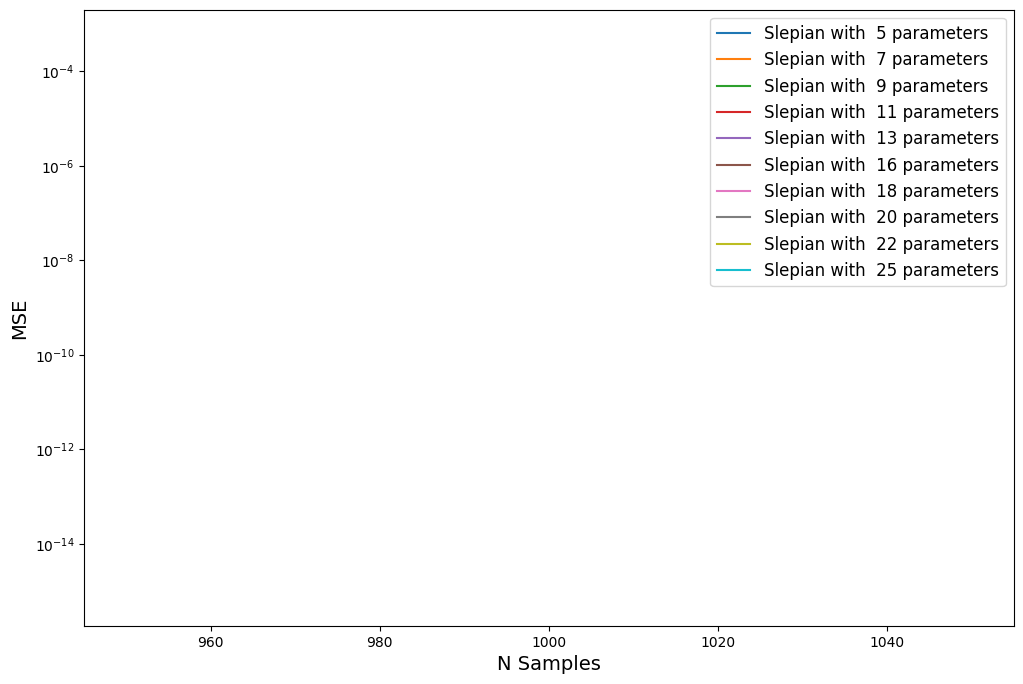

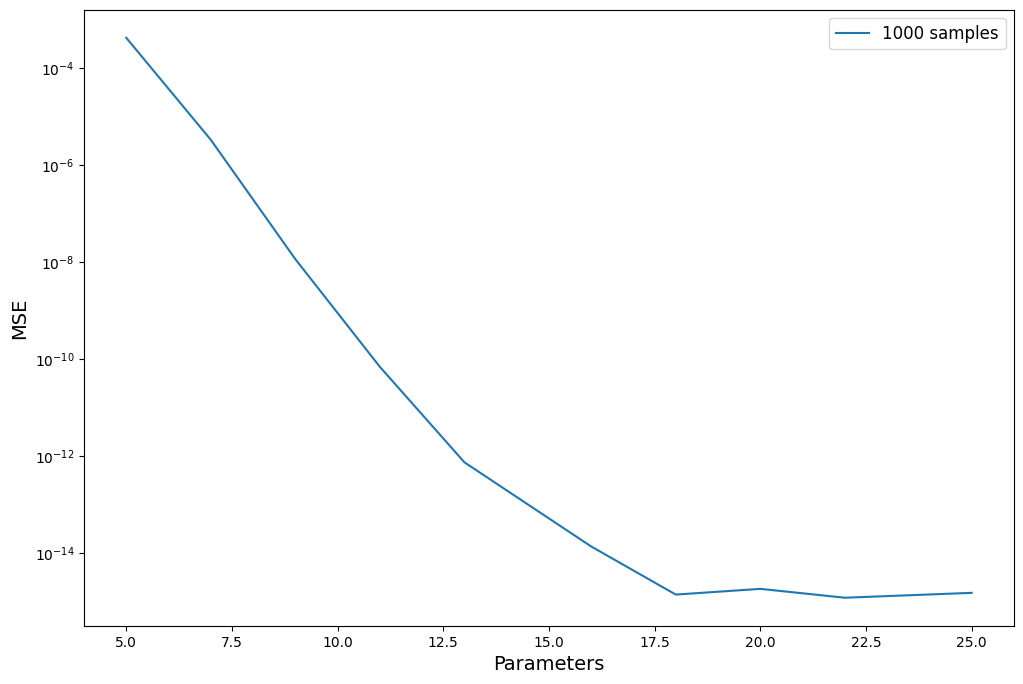

Error: 0.00044430634828232605, Progress: 95.50%, approx. 5.7 seconds remaining.
Error: 3.4074792510870883e-06, Progress: 96.00%, approx. 5.0 seconds remaining.
Error: 1.1698958367018073e-08, Progress: 96.50%, approx. 4.4 seconds remaining.
Error: 7.104439434712325e-11, Progress: 97.00%, approx. 3.7 seconds remaining.
Error: 7.606017694981676e-13, Progress: 97.50%, approx. 3.1 seconds remaining.
Error: 1.4765940767490943e-14, Progress: 98.00%, approx. 2.5 seconds remaining.
Error: 1.5955415221050682e-15, Progress: 98.50%, approx. 1.8 seconds remaining.
Error: 5.005246918643392e-16, Progress: 99.00%, approx. 1.2 seconds remaining.
Error: 9.673222281683394e-16, Progress: 99.50%, approx. 0.6 seconds remaining.
Error: 9.557079411250546e-16, Progress: 100.00%, approx. 0.0 seconds remaining.


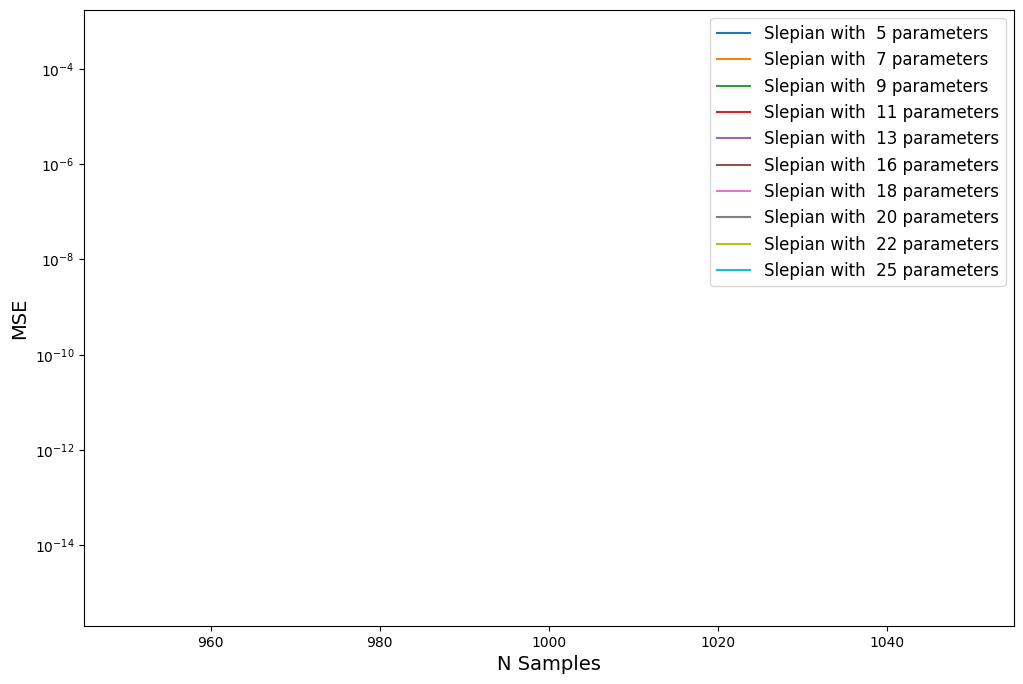

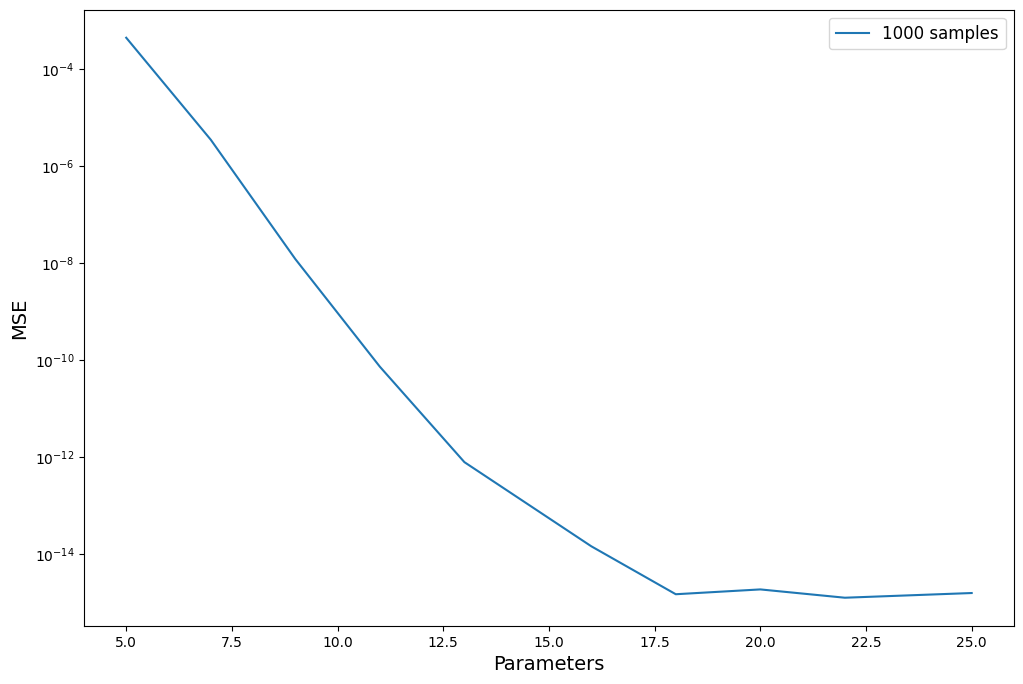

In [17]:
import numpy as np

# Initialize the error vector
MSE = np.zeros([len(Para_slep), len(Nsamples), total_runs])

start_time = time.time()
total_iterations = total_runs * len(Para_slep) * len(Nsamples)
counter = 0

# test set can be the same always

for run in range(total_runs):
    # produce the matrix first, then take rectangles. It takes too long to recreate it every time.
    SamSet_ = samps(Nsamples[-1])
    y_ = funct(SamSet_)
    A_ = Matrix(SamSet_, Para_slep[-1])
    TestSet = samps(Ntest)
    Values_test = funct(TestSet)
    test_PSWF_matrix_ = np.array([[PSWF(t, i, 4) for i in range(Para_slep[-1])] for t in TestSet])    


    for orde in range(len(Para_slep)):
        
        for k in range(len(Nsamples)):
            # Generate sample and test sets
            A = A_[:Nsamples[k], :Para_slep[orde]]
            SamSet = SamSet_[:Nsamples[k]]
            y = y_[:Nsamples[k]]
            
            test_PSWF_matrix = test_PSWF_matrix_[:, :Para_slep[orde]]
            
            #Values_test = funct(TestSet)

            # Solve the linear regression problem using lstsq (least squares)
            x, _, _, _ = np.linalg.lstsq(A.T@A, A.T@y, rcond=None)

            # Calculate the linear combination on the test set in a vectorized manner
            linear_combination_t = test_PSWF_matrix@x
            
            # Calculate the error
            Err = np.linalg.norm(linear_combination_t - Values_test) / np.sqrt(Ntest)
            
            MSE[orde, k, run] = Err
            
            counter += 1
            now_time = time.time()
            print('Error: ' + str(Err) +  ', Progress: ' + format(100*counter / total_iterations, '.2f') + '%' + ', approx. ' + format((total_iterations-counter)*(now_time -  start_time)/counter, '.1f') + ' seconds remaining.')
    
    
    #Plot Error over training set sizes
    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSE, axis = 2)
    results_lower = np.std(MSE, axis = 2)/results_mean # 90% confidence intervals


    for i in range(len(Para_slep)):
        plt.semilogy(Nsamples, results_mean[i,:], label=f'Slepian with  {Para_slep[i]} parameters')
        plt.fill_between(Nsamples, results_mean[i,:]/(1+results_lower[i,:]), results_mean[i,:]*(1+results_lower[i,:]),  alpha=0.2)

    plt.xlabel('N Samples', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)

    plt.show()

    plt.figure(figsize=(12, 8))  #Size
    results_mean = np.mean(MSE, axis = 2)
    results_lower = np.sort(MSE, axis = 2)[:,:,1] # 90% confidence intervals
    results_upper = np.sort(MSE, axis = 2)[:,:,-2] # 90% confidence intervals

    for i in range(len(Nsamples)):
        plt.semilogy(Para_slep, results_mean[:,i], label=f'{Nsamples[i]} samples')
        plt.fill_between(Para_slep, results_mean[:,i]/(1+results_lower[:,i]),results_mean[:,i]*(1+results_lower[:,i]),  alpha=0.2)

    plt.xlabel('Parameters', fontsize=14)
    plt.ylabel('MSE', fontsize=14)

    plt.legend(fontsize=12)
    plt.savefig("errorvsparams.pdf")
    plt.show()

In [18]:
MSE.shape

(10, 1, 20)

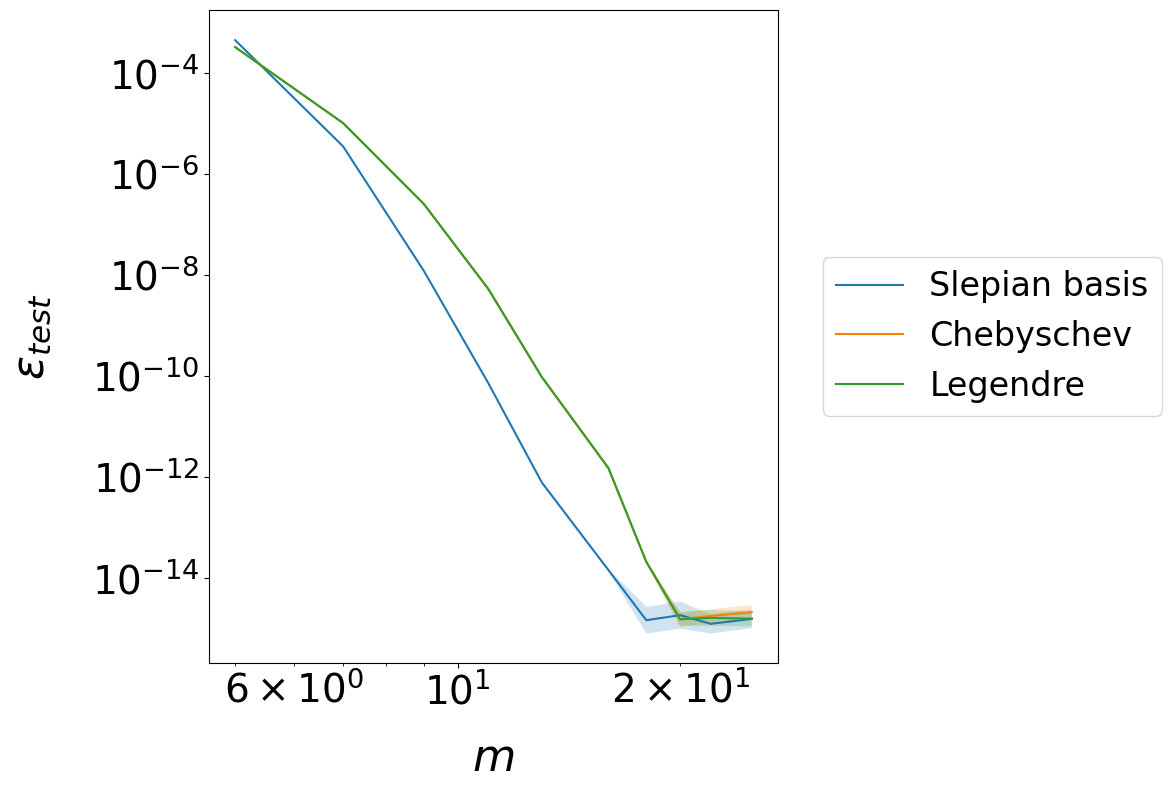

In [19]:
#Plot Error over training set sizes
plt.figure(figsize=(12, 8))  #Size
results_mean_cheby = np.mean(MSEcheby, axis = 2)
results_lower_cheby = np.std(MSEcheby, axis = 2)/results_mean_cheby # 90% confidence intervals

results_mean_leg = np.mean(MSE_leg, axis = 2)
results_lower_leg = np.std(MSE_leg, axis = 2)/results_mean_leg # 90% confidence intervals

results_mean = np.mean(MSE, axis = 2)
results_lower = np.std(MSE, axis = 2)/results_mean # 90% confidence intervals


for i in range(len(Nsamples)):
    plt.loglog(Para_slep, results_mean[:,i], label="Slepian basis")
    plt.fill_between(Para_slep, results_mean[:,i]/(1+results_lower[:,i]), results_mean[:,i]*(1+results_lower[:,i]),  alpha=0.2)

    plt.loglog(Para_slep, results_mean_cheby[:,i], label="Chebyschev")
    plt.fill_between(Para_slep, results_mean_cheby[:,i]/(1+results_lower_cheby[:,i]), results_mean_cheby[:,i]*(1+results_lower_cheby[:,i]),  alpha=0.2)

    plt.loglog(Para_slep, results_mean_leg[:,i], label="Legendre")
    plt.fill_between(Para_slep, results_mean_leg[:,i]/(1+results_lower_leg[:,i]), results_mean_leg[:,i]*(1+results_lower_leg[:,i]),  alpha=0.2)



plt.xlabel(r'$m$', fontsize=32, labelpad=18)
plt.ylabel(r'$\epsilon_{test}$', fontsize=32, labelpad=28)


# Increase font size of axis tick labels
plt.tick_params(axis='both', which='major', labelsize=28)  # Major ticks
plt.tick_params(axis='both', which='minor', labelsize=28)  # Minor ticks

plt.legend(fontsize=28, loc='lower left')

plt.legend(
    fontsize=24,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),  # Place the legend to the right of the plot
    ncol=1  # Single column for legend entries
)

plt.tight_layout()  # Asegura que todo se ajuste bien en la figura


plt.savefig("errorvsparams_expo.pdf")


plt.show()

In [20]:
results_mean

array([[4.38907140e-04],
       [3.45663528e-06],
       [1.19543212e-08],
       [7.19732212e-11],
       [7.73806761e-13],
       [1.42596291e-14],
       [1.45940034e-15],
       [1.83477464e-15],
       [1.23661696e-15],
       [1.54541732e-15]])

In [21]:
results_lower

array([[0.01937958],
       [0.0234313 ],
       [0.0275352 ],
       [0.02999176],
       [0.03627764],
       [0.05305055],
       [0.84137131],
       [0.8581478 ],
       [0.55618948],
       [0.52009129]])